# 13 — Classical Metrics

**Origin:** Consolidates Existing Notebooks 09, 15, and 22  
**Refactor status:** Finished                    
**Validation status:** Finished            
**Completion gate passed:** Yes          
**Output root:** `outputs/13_classical_metrics/`  
**Depends on:** Notebook 02 geometry handoff and Notebooks 08–12

## Purpose

Compute one standardized long-form classical full-reference evidence table for every completed and technically valid restoration candidate.

The evaluated candidate universe contains:

- 410 OpenCV Telea candidates;
- 410 LaMa candidates;
- 1,330 Stable Diffusion 1.5 candidates;
- 10 technically validated SDXL candidates;
- 2,160 candidates in total;
- 150 zero-control candidates.

The notebook computes MSE, MAE, PSNR, and SSIM for clean-versus-damaged and clean-versus-restored comparisons, followed by direction-aware improvement.

Sparse masked-pixel SSIM is prohibited. Sliding `patch_window` evaluation is deferred to later local and semantic notebooks.

SDXL remains an explicitly partial ten-case scope. Its four canonical and six synthetic candidates are evaluated normally, but missing SDXL cases are not represented by placeholder metric rows.

In [1]:
from pathlib import Path
import json
import platform
import sys

import matplotlib
import numpy as np
import pandas as pd
import PIL
import skimage
import yaml
from IPython.display import display


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents)
    if (
        (candidate / ".git").exists()
        and (candidate / "src" / "restoration_eval").is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import __version__ as PACKAGE_VERSION

from restoration_eval.evaluation_inputs import (
    EVALUATION_INPUTS_MODULE_VERSION,
    EVALUATION_WORKLIST_SCHEMA_VERSION,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.metrics_classical import (
    METRIC_MODULE_NAME,
    METRIC_MODULE_VERSION,
    METRIC_VERSION,
    load_classical_metrics_config,
)

from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    resolve_repo_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.regions import (
    REGIONS_MODULE_VERSION,
)

from restoration_eval.schemas import (
    CLASSICAL_METRICS_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    CASE_REGISTRY_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    REGION_POLICY_SCHEMA,
    RESTORATIONS_SCHEMA,
    STABLE_DIFFUSION_CANDIDATES_SCHEMA,
    SDXL_PARTIAL_CANDIDATES_SCHEMA,
    SCHEMAS_MODULE_VERSION,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook identity and owned output directories
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "13"
NOTEBOOK_STEM = "13_classical_metrics"
SUPPORTED_PYTHON_MINORS = {(3, 11), (3, 12)}
RUN_STARTED_AT_UTC = utc_now_iso()

NOTEBOOK_OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "metrics",
        "figures",
        "manifests",
        "validation",
        "work",
    ),
    PROJECT_ROOT,
)

print("Notebook 13 repository bootstrap complete.")
print("Project root:", PROJECT_ROOT)
print("Notebook output root:", NOTEBOOK_OUTPUT_ROOT)
print("Metric helper:", METRIC_MODULE_NAME, METRIC_MODULE_VERSION)
print("Metric definition version:", METRIC_VERSION)
print("Run started at UTC:", RUN_STARTED_AT_UTC)

Notebook 13 repository bootstrap complete.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Notebook output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\13_classical_metrics
Metric helper: restoration_eval.metrics_classical 3.0.0
Metric definition version: classical_full_reference.v1
Run started at UTC: 2026-08-27T06:28:53.446137Z


In [2]:
# ---------------------------------------------------------------------------
# Governing paths
# ---------------------------------------------------------------------------

METRICS_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "metrics.yaml"
)

NOTEBOOK_ROADMAP_PATH = (
    PROJECT_ROOT
    / "docs"
    / "final_notebook_roadmap.md"
)

IMPLEMENTATION_GUIDELINES_PATH = (
    PROJECT_ROOT
    / "docs"
    / "refactoring_implementation_guidelines.md"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "13_classical_metrics.ipynb"
)

HELPER_PATHS = {
    "evaluation_inputs_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "evaluation_inputs.py"
    ),
    "classical_metrics_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "metrics_classical.py"
    ),
    "regions_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "regions.py"
    ),
    "schemas_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "schemas.py"
    ),
}


# ---------------------------------------------------------------------------
# Approved metric configuration
# ---------------------------------------------------------------------------

metrics_config = load_classical_metrics_config(
    METRICS_CONFIG_PATH
)

CLASSICAL_CONFIG = metrics_config["classical_metrics"]
CONFIGURED_INPUTS = CLASSICAL_CONFIG["inputs"]
CONFIGURED_OUTPUTS = CLASSICAL_CONFIG["output"]
EXPECTED_COUNTS = CLASSICAL_CONFIG["expected_counts"]

if CLASSICAL_CONFIG["notebook_stem"] != NOTEBOOK_STEM:
    raise ValueError(
        "Configured notebook stem disagrees with Notebook 13."
    )

if CONFIGURED_OUTPUTS["root"] != f"outputs/{NOTEBOOK_STEM}":
    raise ValueError(
        "Configured output root disagrees with Notebook 13 ownership."
    )


# ---------------------------------------------------------------------------
# Explicit input paths
# ---------------------------------------------------------------------------

INPUTS = {
    "project_inventory": resolve_repo_path(
        CONFIGURED_INPUTS["inventory_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "inventory_run": resolve_repo_path(
        CONFIGURED_INPUTS["inventory_run_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "project_paths_registry": resolve_repo_path(
        CONFIGURED_INPUTS["project_paths_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "preprocessing_geometry": resolve_repo_path(
        CONFIGURED_INPUTS["geometry_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "preprocessing_run_manifest": resolve_repo_path(
        CONFIGURED_INPUTS["geometry_run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "case_registry": resolve_repo_path(
        CONFIGURED_INPUTS["case_registry_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "model_eligibility": resolve_repo_path(
        CONFIGURED_INPUTS["model_eligibility_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "region_policy": resolve_repo_path(
        CONFIGURED_INPUTS["region_policy_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "schema_registry": resolve_repo_path(
        CONFIGURED_INPUTS["schema_registry_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "contracts_run_manifest": resolve_repo_path(
        CONFIGURED_INPUTS["contracts_run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "contracts_artifacts": resolve_repo_path(
        CONFIGURED_INPUTS["contracts_artifacts_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "evaluation_contract_config": resolve_repo_path(
        CONFIGURED_INPUTS["evaluation_contract_config_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
}

SOURCE_CONFIGS = {
    item["source_table_id"]: item
    for item in CONFIGURED_INPUTS["upstream_sources"]
}

SOURCE_BY_MODEL = {
    item["model_id"]: item
    for item in CONFIGURED_INPUTS["upstream_sources"]
}

for source_id, source_config in SOURCE_CONFIGS.items():
    INPUTS[f"{source_id}_table"] = resolve_repo_path(
        source_config["path"],
        PROJECT_ROOT,
        must_exist=True,
    )
    INPUTS[f"{source_id}_run_manifest"] = resolve_repo_path(
        source_config["run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

CONFIGURATION_PATHS = {
    "evaluation_metrics": METRICS_CONFIG_PATH,
    "evaluation_contract": INPUTS["evaluation_contract_config"],
}

GOVERNING_PATHS = {
    "notebook_roadmap": NOTEBOOK_ROADMAP_PATH,
    "implementation_guidelines": IMPLEMENTATION_GUIDELINES_PATH,
    "notebook": NOTEBOOK_PATH,
}


# ---------------------------------------------------------------------------
# Canonical output paths
# ---------------------------------------------------------------------------

OUTPUTS = {
    "classical_metrics": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["metrics_path"]
    ),
    "classical_metric_distributions": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["distributions_figure_path"]
    ),
    "classical_improvement_by_region": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["improvement_figure_path"]
    ),
    "run_manifest": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["run_manifest_path"]
    ),
    "artifacts": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["artifacts_path"]
    ),
    "validation": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["validation_path"]
    ),
}

WORK_PATHS = {
    "checkpoint": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["checkpoint_path"]
    ),
}


# ---------------------------------------------------------------------------
# Global discovery contracts
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    INPUTS["project_inventory"],
    low_memory=False,
)

with INPUTS["inventory_run"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    inventory_run = json.load(handle)

project_paths_registry = load_project_paths_registry(
    PROJECT_ROOT
)

inventory_relative_paths = set(
    inventory_df["relative_path"].astype(str)
)

registry_artifacts = {
    record["artifact_key"]: record
    for record in project_paths_registry["artifacts"]
}


# ---------------------------------------------------------------------------
# Upstream run manifests
# ---------------------------------------------------------------------------

UPSTREAM_MANIFEST_PATHS = {
    "notebook_02": INPUTS["preprocessing_run_manifest"],
    "notebook_08": INPUTS["contracts_run_manifest"],
}

for source_id in SOURCE_CONFIGS:
    UPSTREAM_MANIFEST_PATHS[source_id] = INPUTS[
        f"{source_id}_run_manifest"
    ]

upstream_manifests = {}

for producer, manifest_path in UPSTREAM_MANIFEST_PATHS.items():
    with manifest_path.open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        upstream_manifests[producer] = json.load(handle)

CONFIGURATION_CHECKSUMS = {
    key: sha256_file(path)
    for key, path in CONFIGURATION_PATHS.items()
}

HELPER_CHECKSUMS = {
    key: sha256_file(path)
    for key, path in HELPER_PATHS.items()
}

print("Notebook 13 paths and configurations loaded.")
print("Inventory run ID:", inventory_run["inventory_run_id"])
print("Inventory rows:", len(inventory_df))
print("Registry artifacts:", len(registry_artifacts))
print("Upstream run manifests:", len(upstream_manifests))
print("Declared canonical outputs:", len(OUTPUTS))

Notebook 13 paths and configurations loaded.
Inventory run ID: inventory_20260826T235404Z_2363d8d5
Inventory rows: 11431
Registry artifacts: 72
Upstream run manifests: 6
Declared canonical outputs: 6


In [3]:
# ---------------------------------------------------------------------------
# Input contract
# ---------------------------------------------------------------------------

def input_contract_record(
    input_key,
    producer,
    path,
    file_format,
    schema_version,
    expected_cardinality,
    role,
):
    return {
        "input_key": input_key,
        "producer": producer,
        "relative_path": to_repo_relative(
            path,
            PROJECT_ROOT,
        ),
        "format": file_format,
        "schema_version": schema_version,
        "expected_cardinality": expected_cardinality,
        "role": role,
        "required": True,
    }


input_contract_records = [
    input_contract_record(
        "project_inventory",
        "tools/build_project_inventory.py",
        INPUTS["project_inventory"],
        "csv",
        "project_file_inventory.v1",
        inventory_run["summary"]["file_count"],
        "repository discovery",
    ),
    input_contract_record(
        "inventory_run",
        "tools/build_project_inventory.py",
        INPUTS["inventory_run"],
        "json",
        "inventory_run.v1",
        1,
        "inventory provenance",
    ),
    input_contract_record(
        "project_paths_registry",
        "validated notebook handoffs",
        INPUTS["project_paths_registry"],
        "json",
        "project_paths.v1",
        len(project_paths_registry["artifacts"]),
        "artifact discovery",
    ),
    input_contract_record(
        "preprocessing_geometry",
        "Notebook 02",
        INPUTS["preprocessing_geometry"],
        "csv",
        PREPROCESSED_IMAGES_SCHEMA.version,
        50,
        "painting-content geometry",
    ),
    input_contract_record(
        "case_registry",
        "Notebook 08",
        INPUTS["case_registry"],
        "csv",
        CASE_REGISTRY_SCHEMA.version,
        525,
        "normalized evaluation cases",
    ),
    input_contract_record(
        "model_eligibility",
        "Notebook 08",
        INPUTS["model_eligibility"],
        "csv",
        MODEL_ELIGIBILITY_SCHEMA.version,
        2100,
        "model/case routing",
    ),
    input_contract_record(
        "region_policy",
        "Notebook 08",
        INPUTS["region_policy"],
        "csv",
        REGION_POLICY_SCHEMA.version,
        143,
        "metric-region compatibility",
    ),
    input_contract_record(
        "schema_registry",
        "Notebook 08",
        INPUTS["schema_registry"],
        "json",
        "schema_registry.v1",
        1,
        "upstream schema discovery",
    ),
    input_contract_record(
        "contracts_artifacts",
        "Notebook 08",
        INPUTS["contracts_artifacts"],
        "csv",
        "artifact_manifest.v1",
        "one or more",
        "upstream artifact evidence",
    ),
    input_contract_record(
        "evaluation_metrics_config",
        "Repository configuration",
        METRICS_CONFIG_PATH,
        "yaml",
        metrics_config["config_schema_version"],
        1,
        "metric definitions and numerical policy",
    ),
    input_contract_record(
        "evaluation_contract_config",
        "Repository configuration",
        INPUTS["evaluation_contract_config"],
        "yaml",
        "evaluation_contract_config.v1",
        1,
        "region and eligibility policy",
    ),
]

for producer, manifest_path in UPSTREAM_MANIFEST_PATHS.items():
    input_contract_records.append(
        input_contract_record(
            f"{producer}_run_manifest",
            producer,
            manifest_path,
            "json",
            "run_manifest.v1",
            1,
            "completed upstream run evidence",
        )
    )

for source_id, source_config in SOURCE_CONFIGS.items():
    model_id = source_config["model_id"]
    input_contract_records.append(
        input_contract_record(
            f"{source_id}_table",
            source_id,
            INPUTS[f"{source_id}_table"],
            "csv",
            source_config["schema_version"],
            EXPECTED_COUNTS["candidates_by_model"][model_id],
            f"{model_id} restoration candidates",
        )
    )

input_contract_df = pd.DataFrame(
    input_contract_records
)


# ---------------------------------------------------------------------------
# Output contract
# ---------------------------------------------------------------------------

output_contract_df = pd.DataFrame(
    [
        {
            "artifact_key": "classical_metrics.metrics",
            "relative_path": to_repo_relative(
                OUTPUTS["classical_metrics"],
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": CLASSICAL_METRICS_SCHEMA.version,
            "expected_cardinality": EXPECTED_COUNTS["total_metric_rows"],
            "role": "primary downstream evidence",
        },
        {
            "artifact_key": "classical_metrics.distributions",
            "relative_path": to_repo_relative(
                OUTPUTS["classical_metric_distributions"],
                PROJECT_ROOT,
            ),
            "format": "png",
            "schema_version": "figure.classical_metric_distributions.v1",
            "expected_cardinality": 1,
            "role": "compact QA visualization",
        },
        {
            "artifact_key": "classical_metrics.improvement_by_region",
            "relative_path": to_repo_relative(
                OUTPUTS["classical_improvement_by_region"],
                PROJECT_ROOT,
            ),
            "format": "png",
            "schema_version": "figure.classical_improvement_by_region.v1",
            "expected_cardinality": 1,
            "role": "regional improvement visualization",
        },
        {
            "artifact_key": "classical_metrics.run_manifest",
            "relative_path": to_repo_relative(
                OUTPUTS["run_manifest"],
                PROJECT_ROOT,
            ),
            "format": "json",
            "schema_version": "run_manifest.v1",
            "expected_cardinality": 1,
            "role": "run provenance",
        },
        {
            "artifact_key": "classical_metrics.artifacts",
            "relative_path": to_repo_relative(
                OUTPUTS["artifacts"],
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": "artifact_manifest.v1",
            "expected_cardinality": "canonical artifacts only",
            "role": "artifact handoff",
        },
        {
            "artifact_key": "classical_metrics.validation",
            "relative_path": to_repo_relative(
                OUTPUTS["validation"],
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": "validation_checks.v1",
            "expected_cardinality": "consolidated checks",
            "role": "validation evidence",
        },
    ]
)

display(input_contract_df)
display(output_contract_df)

print("Notebook 13 input/output contracts constructed.")
print("Input contract rows:", len(input_contract_df))
print("Canonical output contract rows:", len(output_contract_df))

,input_key,producer,relative_path,format,schema_version,expected_cardinality,role,required
0,project_inventory,tools/build_project_inventory.py,outputs/inventory/project_file_inventory.csv,csv,project_file_inventory.v1,11431,repository discovery,True
1,inventory_run,tools/build_project_inventory.py,outputs/inventory/inventory_run.json,json,inventory_run.v1,1,inventory provenance,True
2,project_paths_registry,validated notebook handoffs,outputs/inventory/project_paths.json,json,project_paths.v1,72,artifact discovery,True
3,preprocessing_geometry,Notebook 02,outputs/02_image_preprocessing/data/preprocess...,csv,preprocessed_images.v1,50,painting-content geometry,True
4,case_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,case_registry.v1,525,normalized evaluation cases,True
5,model_eligibility,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,model_eligibility.v1,2100,model/case routing,True
6,region_policy,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,region_policy.v1,143,metric-region compatibility,True
7,schema_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,json,schema_registry.v1,1,upstream schema discovery,True
8,contracts_artifacts,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,artifact_manifest.v1,one or more,upstream artifact evidence,True
9,evaluation_metrics_config,Repository configuration,config/evaluation/metrics.yaml,yaml,evaluation_metrics_config.v1,1,metric definitions and numerical policy,True


,artifact_key,relative_path,format,schema_version,expected_cardinality,role
0,classical_metrics.metrics,outputs/13_classical_metrics/metrics/classical...,csv,classical_metrics.v1,63018,primary downstream evidence
1,classical_metrics.distributions,outputs/13_classical_metrics/figures/classical...,png,figure.classical_metric_distributions.v1,1,compact QA visualization
2,classical_metrics.improvement_by_region,outputs/13_classical_metrics/figures/classical...,png,figure.classical_improvement_by_region.v1,1,regional improvement visualization
3,classical_metrics.run_manifest,outputs/13_classical_metrics/manifests/run_man...,json,run_manifest.v1,1,run provenance
4,classical_metrics.artifacts,outputs/13_classical_metrics/manifests/artifac...,csv,artifact_manifest.v1,canonical artifacts only,artifact handoff
5,classical_metrics.validation,outputs/13_classical_metrics/validation/checks...,csv,validation_checks.v1,consolidated checks,validation evidence


Notebook 13 input/output contracts constructed.
Input contract rows: 21
Canonical output contract rows: 6


In [4]:
# ---------------------------------------------------------------------------
# Metric definitions
# ---------------------------------------------------------------------------

metric_policy_df = pd.DataFrame(
    CLASSICAL_CONFIG["metrics"]
)

region_policy_records = []

for metric_family, region_ids in (
    CLASSICAL_CONFIG["regions"]["compatible_regions"].items()
):
    for region_order, region_id in enumerate(
        region_ids,
        start=1,
    ):
        region_policy_records.append(
            {
                "metric_family": metric_family,
                "region_id": region_id,
                "region_order": region_order,
                "mathematically_approved": True,
            }
        )

region_execution_policy_df = pd.DataFrame(
    region_policy_records
)


# ---------------------------------------------------------------------------
# Expected cardinalities
# ---------------------------------------------------------------------------

expected_count_records = []

for count_key, expected_value in EXPECTED_COUNTS.items():
    if count_key == "candidates_by_model":
        continue

    expected_count_records.append(
        {
            "count_scope": "overall",
            "count_key": count_key,
            "expected_value": expected_value,
        }
    )

for model_id, candidate_count in (
    EXPECTED_COUNTS["candidates_by_model"].items()
):
    expected_count_records.append(
        {
            "count_scope": "model",
            "count_key": model_id,
            "expected_value": candidate_count,
        }
    )

expected_counts_df = pd.DataFrame(
    expected_count_records
)

SDXL_CANONICAL_CANDIDATES = 4
SDXL_SYNTHETIC_CANDIDATES = 6
SDXL_EXPECTED_METRIC_ROWS = (
    SDXL_CANONICAL_CANDIDATES * 30
    + SDXL_SYNTHETIC_CANDIDATES * 33
)

display(metric_policy_df)
display(region_execution_policy_df)
display(expected_counts_df)

print("Metric and region policies loaded.")
print(
    "Classical metric rows per MSE/MAE/PSNR:",
    EXPECTED_COUNTS["classical_metric_rows_each"],
)
print("SSIM rows:", EXPECTED_COUNTS["ssim_rows"])
print("Total expected metric rows:", EXPECTED_COUNTS["total_metric_rows"])
print("Expected SDXL metric rows:", SDXL_EXPECTED_METRIC_ROWS)

,metric_name,metric_family,definition,improvement_direction,limitation
0,mse,classical_pixel,Mean squared RGB-channel error over the select...,damaged_minus_restored,Pixel-aligned error; insensitive to perceptual...
1,mae,classical_pixel,Mean absolute RGB-channel error over the selec...,damaged_minus_restored,Pixel-aligned error; does not model visual sal...
2,psnr,classical_pixel,"10 log10(data_range squared divided by MSE), d...",restored_minus_damaged,Infinite for exact equality and not perceptual...
3,ssim,ssim,scikit-image RGB structural similarity with ch...,restored_minus_damaged,Valid only on contiguous rectangular regions a...


,metric_family,region_id,region_order,mathematically_approved
0,classical_pixel,full_image,1,True
1,classical_pixel,content_region,2,True
2,classical_pixel,masked_region,3,True
3,classical_pixel,mask_bbox_crop,4,True
4,classical_pixel,inner_boundary_band,5,True
5,classical_pixel,outer_boundary_band,6,True
6,classical_pixel,boundary_ring,7,True
7,classical_pixel,outside_mask_content,8,True
8,classical_pixel,outside_boundary_ring,9,True
9,classical_pixel,degradation_support,10,True


,count_scope,count_key,expected_value
0,overall,case_registry_rows,525
1,overall,eligible_case_model_pairs,1640
2,overall,evaluated_unique_cases,410
3,overall,evaluated_candidates,2160
4,overall,zero_control_cases,50
5,overall,zero_control_candidates,150
6,overall,active_threshold_13_candidates,356
7,overall,active_threshold_128_candidates,1804
8,overall,classical_metric_rows_each,18896
9,overall,ssim_rows,6330


Metric and region policies loaded.
Classical metric rows per MSE/MAE/PSNR: 18896
SSIM rows: 6330
Total expected metric rows: 63018
Expected SDXL metric rows: 318


In [5]:
# ---------------------------------------------------------------------------
# Batch 1 validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


def add_batch_1_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Runtime and configuration checks
# ---------------------------------------------------------------------------

python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_batch_1_check(
    "supported_python",
    "Python is one of the approved 3.11 or 3.12 runtimes.",
    sorted(SUPPORTED_PYTHON_MINORS),
    python_minor,
    python_minor in SUPPORTED_PYTHON_MINORS,
)

add_batch_1_check(
    "metric_schema_registered",
    "The canonical long-form classical metric schema is registered.",
    "classical_metrics.v1",
    CLASSICAL_METRICS_SCHEMA.version,
    CLASSICAL_METRICS_SCHEMA.version == "classical_metrics.v1",
)

add_batch_1_check(
    "metric_version_frozen",
    "Configuration and helper use the same metric definition version.",
    METRIC_VERSION,
    CLASSICAL_CONFIG["metric_version"],
    CLASSICAL_CONFIG["metric_version"] == METRIC_VERSION,
)

add_batch_1_check(
    "notebook_output_root",
    "The configured output root belongs exclusively to Notebook 13.",
    f"outputs/{NOTEBOOK_STEM}",
    to_repo_relative(
        NOTEBOOK_OUTPUT_ROOT,
        PROJECT_ROOT,
    ),
    (
        to_repo_relative(
            NOTEBOOK_OUTPUT_ROOT,
            PROJECT_ROOT,
        )
        == f"outputs/{NOTEBOOK_STEM}"
    ),
)


# ---------------------------------------------------------------------------
# Inventory validation
# ---------------------------------------------------------------------------

inventory_summary = inventory_run["summary"]

add_batch_1_check(
    "inventory_completed",
    "The refreshed inventory completed successfully.",
    "completed",
    inventory_run["status"],
    inventory_run["status"] == "completed",
)

add_batch_1_check(
    "inventory_read_errors",
    "The refreshed inventory contains no read errors.",
    0,
    inventory_summary["read_error_count"],
    inventory_summary["read_error_count"] == 0,
)

add_batch_1_check(
    "inventory_row_count",
    "Inventory rows match the inventory-run manifest.",
    inventory_summary["file_count"],
    len(inventory_df),
    len(inventory_df) == inventory_summary["file_count"],
)

observed_inventory_sha256 = sha256_file(
    INPUTS["project_inventory"]
)

add_batch_1_check(
    "inventory_checksum",
    "The inventory CSV checksum matches its run manifest.",
    inventory_run["inventory_sha256"],
    observed_inventory_sha256,
    (
        observed_inventory_sha256
        == inventory_run["inventory_sha256"]
    ),
)


# ---------------------------------------------------------------------------
# Declared file existence and inventory coverage
# ---------------------------------------------------------------------------

DECLARED_FILES = {
    **INPUTS,
    **CONFIGURATION_PATHS,
    **GOVERNING_PATHS,
    **HELPER_PATHS,
}

for file_key, file_path in DECLARED_FILES.items():
    add_batch_1_check(
        f"declared_file_exists_{file_key}",
        f"Declared file {file_key!r} exists.",
        True,
        file_path.exists(),
        file_path.exists(),
        details=to_repo_relative(
            file_path,
            PROJECT_ROOT,
        ),
    )

inventory_self_keys = {
    "project_inventory",
    "inventory_run",
}

missing_inventory_files = {
    file_key: to_repo_relative(
        file_path,
        PROJECT_ROOT,
    )
    for file_key, file_path in DECLARED_FILES.items()
    if (
        file_key not in inventory_self_keys
        and to_repo_relative(
            file_path,
            PROJECT_ROOT,
        )
        not in inventory_relative_paths
    )
}

add_batch_1_check(
    "declared_files_in_inventory",
    "Every non-self-referential declared file appears in the refreshed inventory.",
    {},
    missing_inventory_files,
    not missing_inventory_files,
)

legacy_markers = (
    "notebooks/09_opencv_metrics_classical.ipynb",
    "notebooks/15_metrics_classical_lama.ipynb",
    "notebooks/22_stable_diffusion_classical_metrics.ipynb",
    "outputs/09_opencv_metrics_classical/",
    "outputs/22_stable_diffusion_classical_metrics/",
)

legacy_inventory_hits = sorted(
    relative_path
    for relative_path in inventory_relative_paths
    if any(
        relative_path == marker.rstrip("/")
        or relative_path.startswith(marker)
        for marker in legacy_markers
    )
)

add_batch_1_check(
    "legacy_classical_artifacts_absent",
    "Deleted legacy classical notebooks and owned outputs are absent.",
    [],
    legacy_inventory_hits,
    not legacy_inventory_hits,
)


# ---------------------------------------------------------------------------
# Upstream run manifests
# ---------------------------------------------------------------------------

for producer, manifest in upstream_manifests.items():
    add_batch_1_check(
        f"{producer}_run_completed",
        f"{producer} completed successfully.",
        "completed",
        manifest.get("run_status"),
        manifest.get("run_status") == "completed",
    )

    add_batch_1_check(
        f"{producer}_completion_gate",
        f"{producer} passed its completion gate.",
        True,
        manifest.get("completion_gate_passed"),
        manifest.get("completion_gate_passed") is True,
    )

    add_batch_1_check(
        f"{producer}_validation_status",
        f"{producer} has passed validation status.",
        "passed",
        manifest.get("validation_status"),
        manifest.get("validation_status") == "passed",
    )


# ---------------------------------------------------------------------------
# Project-path registry
# ---------------------------------------------------------------------------

project_paths_errors = validate_project_paths_registry(
    project_paths_registry
)

add_batch_1_check(
    "project_paths_registry_valid",
    "The authoritative project-path registry is structurally valid.",
    [],
    project_paths_errors,
    not project_paths_errors,
)

registry_expectations = {
    "preprocessing.geometry": CONFIGURED_INPUTS["geometry_path"],
    "experiment_contracts.case_registry": CONFIGURED_INPUTS["case_registry_path"],
    "experiment_contracts.model_eligibility": CONFIGURED_INPUTS["model_eligibility_path"],
    "experiment_contracts.region_policy": CONFIGURED_INPUTS["region_policy_path"],
    "experiment_contracts.schema_registry": CONFIGURED_INPUTS["schema_registry_path"],
    "opencv_telea.restorations": SOURCE_BY_MODEL["opencv_telea"]["path"],
    "lama.restorations": SOURCE_BY_MODEL["lama"]["path"],
    "stable_diffusion.candidates": SOURCE_BY_MODEL[
        "stable_diffusion_inpainting"
    ]["path"],
    "sdxl.candidates": SOURCE_BY_MODEL["sdxl_inpainting"]["path"],
}

for artifact_key, expected_path in registry_expectations.items():
    record = registry_artifacts.get(artifact_key)

    observed = {
        "relative_path": (
            record["relative_path"]
            if record
            else ""
        ),
        "validation_status": (
            record["validation_status"]
            if record
            else ""
        ),
    }

    expected = {
        "relative_path": expected_path,
        "validation_status": "passed",
    }

    add_batch_1_check(
        "registry_" + artifact_key.replace(".", "_"),
        f"Registry artifact {artifact_key!r} matches the approved path.",
        expected,
        observed,
        record is not None and observed == expected,
    )


# ---------------------------------------------------------------------------
# Scientific policy and cardinality checks
# ---------------------------------------------------------------------------

configured_models = {
    source["model_id"]
    for source in SOURCE_CONFIGS.values()
}

add_batch_1_check(
    "all_four_models_configured",
    "All four approved restoration models are included.",
    {
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
        "sdxl_inpainting",
    },
    configured_models,
    configured_models
    == {
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
        "sdxl_inpainting",
    },
)

add_batch_1_check(
    "sdxl_candidate_count",
    "The SDXL partial scope contains ten candidates.",
    10,
    EXPECTED_COUNTS["candidates_by_model"]["sdxl_inpainting"],
    (
        EXPECTED_COUNTS["candidates_by_model"]["sdxl_inpainting"]
        == 10
    ),
)

add_batch_1_check(
    "sdxl_metric_rows",
    "The four canonical and six synthetic SDXL candidates produce metric evidence.",
    318,
    SDXL_EXPECTED_METRIC_ROWS,
    SDXL_EXPECTED_METRIC_ROWS == 318,
)

add_batch_1_check(
    "total_candidate_count",
    "The approved candidate universe contains 2,160 rows.",
    2160,
    EXPECTED_COUNTS["evaluated_candidates"],
    EXPECTED_COUNTS["evaluated_candidates"] == 2160,
)

add_batch_1_check(
    "total_metric_row_count",
    "The approved region-aware output contains 63,018 metric rows.",
    63018,
    EXPECTED_COUNTS["total_metric_rows"],
    EXPECTED_COUNTS["total_metric_rows"] == 63018,
)

configured_region_ids = {
    region_id
    for region_ids in (
        CLASSICAL_CONFIG["regions"]["compatible_regions"].values()
    )
    for region_id in region_ids
}

add_batch_1_check(
    "patch_window_deferred",
    "Sliding patch windows are excluded from Notebook 13.",
    False,
    "patch_window" in configured_region_ids,
    "patch_window" not in configured_region_ids,
)

ssim_regions = set(
    CLASSICAL_CONFIG["regions"]["compatible_regions"]["ssim"]
)

add_batch_1_check(
    "ssim_rectangular_regions_only",
    "SSIM is limited to the three approved rectangular regions.",
    {
        "full_image",
        "content_region",
        "mask_bbox_crop",
    },
    ssim_regions,
    ssim_regions
    == {
        "full_image",
        "content_region",
        "mask_bbox_crop",
    },
)

add_batch_1_check(
    "sparse_ssim_prohibited",
    "Sparse masked-pixel SSIM is explicitly prohibited.",
    "prohibited",
    CLASSICAL_CONFIG["regions"]["sparse_masked_pixel_ssim"],
    (
        CLASSICAL_CONFIG["regions"]["sparse_masked_pixel_ssim"]
        == "prohibited"
    ),
)

output_scope_errors = []

for output_key, output_path in {
    **OUTPUTS,
    **WORK_PATHS,
}.items():
    try:
        output_path.resolve().relative_to(
            NOTEBOOK_OUTPUT_ROOT.resolve()
        )
    except ValueError:
        output_scope_errors.append(
            {
                "output_key": output_key,
                "path": str(output_path),
            }
        )

add_batch_1_check(
    "all_outputs_owned_by_notebook",
    "Every canonical and temporary output remains under Notebook 13.",
    [],
    output_scope_errors,
    not output_scope_errors,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

batch_1_validation_df = VALIDATION.to_dataframe()

display(batch_1_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 1 preflight passed.")
print("Validation checks:", len(batch_1_validation_df))
print("Blocking failures:", len(VALIDATION.blocking_failures))
print("Inventory run ID:", inventory_run["inventory_run_id"])
print("Approved candidates:", EXPECTED_COUNTS["evaluated_candidates"])
print("Approved metric rows:", EXPECTED_COUNTS["total_metric_rows"])
print("Included SDXL candidates:", EXPECTED_COUNTS["candidates_by_model"]["sdxl_inpainting"])
print("Expected SDXL metric rows:", SDXL_EXPECTED_METRIC_ROWS)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python,Python is one of the approved 3.11 or 3.12 run...,blocking,"[[3, 11], [3, 12]]","[3, 12]",True,
1,batch_1_preflight,metric_schema_registered,The canonical long-form classical metric schem...,blocking,classical_metrics.v1,classical_metrics.v1,True,
2,batch_1_preflight,metric_version_frozen,Configuration and helper use the same metric d...,blocking,classical_full_reference.v1,classical_full_reference.v1,True,
3,batch_1_preflight,notebook_output_root,The configured output root belongs exclusively...,blocking,outputs/13_classical_metrics,outputs/13_classical_metrics,True,
4,batch_1_preflight,inventory_completed,The refreshed inventory completed successfully.,blocking,completed,completed,True,
...,...,...,...,...,...,...,...,...
71,batch_1_preflight,total_metric_row_count,"The approved region-aware output contains 63,0...",blocking,63018,63018,True,
72,batch_1_preflight,patch_window_deferred,Sliding patch windows are excluded from Notebo...,blocking,False,False,True,
73,batch_1_preflight,ssim_rectangular_regions_only,SSIM is limited to the three approved rectangu...,blocking,"""{'content_region', 'full_image', 'mask_bbox_c...","""{'content_region', 'full_image', 'mask_bbox_c...",True,
74,batch_1_preflight,sparse_ssim_prohibited,Sparse masked-pixel SSIM is explicitly prohibi...,blocking,prohibited,prohibited,True,


Batch 1 preflight passed.
Validation checks: 76
Blocking failures: 0
Inventory run ID: inventory_20260826T235404Z_2363d8d5
Approved candidates: 2160
Approved metric rows: 63018
Included SDXL candidates: 10
Expected SDXL metric rows: 318


## Batch 2 — Input loading and normalized evaluation worklist

This batch validates the upstream tables against their registered schemas, combines the four restoration-model outputs into one model-agnostic evaluation worklist, verifies region-policy alignment, and audits every referenced image against the refreshed project inventory.

No canonical Notebook 13 artifact is persisted in this batch.

In [6]:
from restoration_eval.evaluation_inputs import (
    EVALUATION_WORKLIST_COLUMNS,
    build_evaluation_worklist,
    validate_evaluation_worklist,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Notebook 02 and Notebook 08 support tables
# ---------------------------------------------------------------------------

preprocessing_geometry_df = pd.read_csv(
    INPUTS["preprocessing_geometry"],
    low_memory=False,
)

case_registry_df = pd.read_csv(
    INPUTS["case_registry"],
    low_memory=False,
)

model_eligibility_df = pd.read_csv(
    INPUTS["model_eligibility"],
    low_memory=False,
)

region_policy_df = pd.read_csv(
    INPUTS["region_policy"],
    low_memory=False,
)

contracts_artifacts_df = pd.read_csv(
    INPUTS["contracts_artifacts"],
    low_memory=False,
)

with INPUTS["schema_registry"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    schema_registry = json.load(handle)


# ---------------------------------------------------------------------------
# Notebook 09–12 restoration candidate tables
# ---------------------------------------------------------------------------

candidate_tables = {
    source_id: pd.read_csv(
        INPUTS[f"{source_id}_table"],
        low_memory=False,
    )
    for source_id in SOURCE_CONFIGS
}

CANDIDATE_SCHEMA_BY_SOURCE = {
    "notebook_09_opencv_telea": RESTORATIONS_SCHEMA,
    "notebook_10_lama": RESTORATIONS_SCHEMA,
    "notebook_11_stable_diffusion": STABLE_DIFFUSION_CANDIDATES_SCHEMA,
    "notebook_12_sdxl": SDXL_PARTIAL_CANDIDATES_SCHEMA,
}


# ---------------------------------------------------------------------------
# Normalize intentional empty string provenance
#
# Notebook 12 uses the generic prompt for all ten partial-scope candidates.
# No contextual metadata fields were used, and the producer represents that
# state as an empty string. Pandas otherwise reloads the empty CSV field as
# NaN, which incorrectly appears to violate the non-null provenance schema.
# ---------------------------------------------------------------------------

sdxl_candidates_df = candidate_tables[
    "notebook_12_sdxl"
]

sdxl_candidates_df[
    "prompt_metadata_fields_used"
] = (
    sdxl_candidates_df[
        "prompt_metadata_fields_used"
    ]
    .fillna("")
    .astype(str)
)

candidate_tables[
    "notebook_12_sdxl"
] = sdxl_candidates_df


# ---------------------------------------------------------------------------
# Compact loading summary
# ---------------------------------------------------------------------------

loaded_table_records = [
    {
        "input_key": "preprocessing_geometry",
        "rows": len(preprocessing_geometry_df),
        "columns": len(
            preprocessing_geometry_df.columns
        ),
    },
    {
        "input_key": "case_registry",
        "rows": len(case_registry_df),
        "columns": len(
            case_registry_df.columns
        ),
    },
    {
        "input_key": "model_eligibility",
        "rows": len(model_eligibility_df),
        "columns": len(
            model_eligibility_df.columns
        ),
    },
    {
        "input_key": "region_policy",
        "rows": len(region_policy_df),
        "columns": len(
            region_policy_df.columns
        ),
    },
    {
        "input_key": "contracts_artifacts",
        "rows": len(contracts_artifacts_df),
        "columns": len(
            contracts_artifacts_df.columns
        ),
    },
]

for source_id, source_df in (
    candidate_tables.items()
):
    loaded_table_records.append(
        {
            "input_key": source_id,
            "rows": len(source_df),
            "columns": len(
                source_df.columns
            ),
        }
    )

loaded_tables_df = pd.DataFrame(
    loaded_table_records
)

display(loaded_tables_df)

print("All declared upstream tables loaded.")
print("Support tables:", 5)
print(
    "Restoration candidate tables:",
    len(candidate_tables),
)
print(
    "Raw restoration rows:",
    sum(
        len(frame)
        for frame in candidate_tables.values()
    ),
)
print(
    "SDXL empty prompt-metadata fields normalized:",
    int(
        candidate_tables[
            "notebook_12_sdxl"
        ][
            "prompt_metadata_fields_used"
        ].eq("").sum()
    ),
)

,input_key,rows,columns
0,preprocessing_geometry,50,50
1,case_registry,525,14
2,model_eligibility,2100,7
3,region_policy,143,15
4,contracts_artifacts,7,15
5,notebook_09_opencv_telea,410,30
6,notebook_10_lama,410,40
7,notebook_11_stable_diffusion,1330,57
8,notebook_12_sdxl,10,72


All declared upstream tables loaded.
Support tables: 5
Restoration candidate tables: 4
Raw restoration rows: 2160
SDXL empty prompt-metadata fields normalized: 10


In [7]:
# ---------------------------------------------------------------------------
# Declarative schema checks
# ---------------------------------------------------------------------------

schema_specs = {
    "preprocessing_geometry": (
        preprocessing_geometry_df,
        PREPROCESSED_IMAGES_SCHEMA,
        50,
        PREPROCESSED_IMAGES_SCHEMA.version,
    ),
    "case_registry": (
        case_registry_df,
        CASE_REGISTRY_SCHEMA,
        EXPECTED_COUNTS["case_registry_rows"],
        CASE_REGISTRY_SCHEMA.version,
    ),
    "model_eligibility": (
        model_eligibility_df,
        MODEL_ELIGIBILITY_SCHEMA,
        2100,
        MODEL_ELIGIBILITY_SCHEMA.version,
    ),
    "region_policy": (
        region_policy_df,
        REGION_POLICY_SCHEMA,
        143,
        REGION_POLICY_SCHEMA.version,
    ),
    "contracts_artifacts": (
        contracts_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        7,
        ARTIFACT_MANIFEST_SCHEMA.version,
    ),
}

for source_id, source_df in candidate_tables.items():
    source_config = SOURCE_CONFIGS[source_id]
    source_schema = CANDIDATE_SCHEMA_BY_SOURCE[source_id]

    schema_specs[source_id] = (
        source_df,
        source_schema,
        EXPECTED_COUNTS["candidates_by_model"][
            source_config["model_id"]
        ],
        source_config["schema_version"],
    )

schema_validation_records = []
schema_validation_results = {}

for input_key, (
    input_df,
    input_schema,
    expected_rows,
    declared_schema_version,
) in schema_specs.items():
    result = validate_dataframe(
        input_df,
        input_schema,
        allow_extra_columns=True,
    )

    schema_validation_results[input_key] = result

    schema_validation_records.append(
        {
            "input_key": input_key,
            "schema_name": result.schema_name,
            "schema_version": result.schema_version,
            "declared_schema_version": declared_schema_version,
            "rows": result.row_count,
            "expected_rows": expected_rows,
            "duplicate_primary_key_rows": (
                result.duplicate_primary_key_rows
            ),
            "null_violation_count": sum(
                result.null_counts.values()
            ),
            "invalid_value_count": sum(
                result.invalid_value_counts.values()
            ),
            "missing_columns": list(
                result.missing_columns
            ),
            "schema_version_matches": (
                result.schema_version
                == declared_schema_version
            ),
            "passed": (
                result.passed
                and result.row_count == expected_rows
                and result.schema_version
                == declared_schema_version
            ),
        }
    )

schema_validation_df = pd.DataFrame(
    schema_validation_records
)

registered_schema_versions = {
    record["name"]: record["version"]
    for record in schema_registry["schemas"]
}

expected_registered_schemas = {
    "case_registry": CASE_REGISTRY_SCHEMA.version,
    "model_eligibility": MODEL_ELIGIBILITY_SCHEMA.version,
    "region_policy": REGION_POLICY_SCHEMA.version,
    "artifact_manifest": ARTIFACT_MANIFEST_SCHEMA.version,
}

observed_registered_schemas = {
    schema_name: registered_schema_versions.get(
        schema_name
    )
    for schema_name in expected_registered_schemas
}

display(schema_validation_df)

print("Upstream schema validation complete.")
print("Validated tables:", len(schema_validation_df))
print(
    "Tables passing schema and row-count contracts:",
    int(schema_validation_df["passed"].sum()),
)
print(
    "Notebook 08 registered schemas:",
    observed_registered_schemas,
)

,input_key,schema_name,schema_version,declared_schema_version,rows,expected_rows,duplicate_primary_key_rows,null_violation_count,invalid_value_count,missing_columns,schema_version_matches,passed
0,preprocessing_geometry,preprocessed_images,preprocessed_images.v1,preprocessed_images.v1,50,50,0,0,0,[],True,True
1,case_registry,case_registry,case_registry.v1,case_registry.v1,525,525,0,0,0,[],True,True
2,model_eligibility,model_eligibility,model_eligibility.v1,model_eligibility.v1,2100,2100,0,0,0,[],True,True
3,region_policy,region_policy,region_policy.v1,region_policy.v1,143,143,0,0,0,[],True,True
4,contracts_artifacts,artifact_manifest,artifact_manifest.v1,artifact_manifest.v1,7,7,0,0,0,[],True,True
5,notebook_09_opencv_telea,restorations,restorations.v1,restorations.v1,410,410,0,0,0,[],True,True
6,notebook_10_lama,restorations,restorations.v1,restorations.v1,410,410,0,0,0,[],True,True
7,notebook_11_stable_diffusion,stable_diffusion_candidates,stable_diffusion_candidates.v1,stable_diffusion_candidates.v1,1330,1330,0,0,0,[],True,True
8,notebook_12_sdxl,sdxl_partial_candidates,sdxl_partial_candidates.v1,sdxl_partial_candidates.v1,10,10,0,0,0,[],True,True


Upstream schema validation complete.
Validated tables: 9
Tables passing schema and row-count contracts: 9
Notebook 08 registered schemas: {'case_registry': 'case_registry.v1', 'model_eligibility': 'model_eligibility.v1', 'region_policy': 'region_policy.v1', 'artifact_manifest': 'artifact_manifest.v1'}


In [8]:
# ---------------------------------------------------------------------------
# Normalize source-specific restoration paths
# ---------------------------------------------------------------------------

candidate_source_roots = {
    source_id: Path(
        source_config["path"]
    ).parent.parent.as_posix()
    for source_id, source_config in (
        SOURCE_CONFIGS.items()
    )
}


# ---------------------------------------------------------------------------
# Normalize all candidate sources
# ---------------------------------------------------------------------------

evaluation_input_bundle = build_evaluation_worklist(
    case_registry=case_registry_df,
    model_eligibility=model_eligibility_df,
    preprocessing_geometry=preprocessing_geometry_df,
    candidate_tables=candidate_tables,
    candidate_source_roots=candidate_source_roots,
)

evaluation_worklist_df = (
    evaluation_input_bundle.worklist
)

evaluation_exclusions_df = (
    evaluation_input_bundle.exclusions
)

source_summary_df = (
    evaluation_input_bundle.source_summary
)

worklist_validation = validate_evaluation_worklist(
    evaluation_worklist_df
)


# ---------------------------------------------------------------------------
# Compact scope summaries
# ---------------------------------------------------------------------------

model_scope_summary_df = (
    evaluation_worklist_df
    .groupby("model_id", as_index=False)
    .agg(
        candidates=("candidate_id", "size"),
        unique_cases=("case_id", "nunique"),
        zero_control_candidates=(
            "is_zero_control",
            "sum",
        ),
        mask_thresholds=(
            "mask_threshold",
            lambda values: ", ".join(
                str(value)
                for value in sorted(
                    set(
                        pd.to_numeric(
                            values,
                            errors="raise",
                        ).astype(int)
                    )
                )
            ),
        ),
    )
    .sort_values(
        "model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

experiment_scope_summary_df = (
    evaluation_worklist_df
    .groupby(
        [
            "experiment_id",
            "damage_or_degradation_type",
        ],
        as_index=False,
    )
    .agg(
        candidates=("candidate_id", "size"),
        unique_cases=("case_id", "nunique"),
        models=("model_id", "nunique"),
    )
    .sort_values(
        [
            "experiment_id",
            "damage_or_degradation_type",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

sdxl_scope_summary_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df["model_id"].eq(
            "sdxl_inpainting"
        )
    ]
    .groupby(
        [
            "experiment_id",
            "damage_or_degradation_type",
        ],
        as_index=False,
    )
    .agg(
        candidates=("candidate_id", "size"),
        unique_cases=("case_id", "nunique"),
    )
    .sort_values(
        [
            "experiment_id",
            "damage_or_degradation_type",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(source_summary_df)
display(model_scope_summary_df)
display(experiment_scope_summary_df)
display(sdxl_scope_summary_df)

print("Model-agnostic evaluation worklist constructed.")
print("Evaluation candidates:", len(evaluation_worklist_df))
print(
    "Unique evaluated cases:",
    evaluation_worklist_df["case_id"].nunique(),
)
print("Explicit exclusions:", len(evaluation_exclusions_df))
print(
    "Zero-control candidates:",
    int(
        evaluation_worklist_df[
            "is_zero_control"
        ].sum()
    ),
)
print(
    "Worklist structural validation passed:",
    worklist_validation["passed"],
)
print(
    "Stable Diffusion paths normalized:",
    evaluation_worklist_df.loc[
        evaluation_worklist_df["model_id"].eq(
            "stable_diffusion_inpainting"
        ),
        "restored_path",
    ].str.startswith(
        "outputs/11_stable_diffusion_restoration/"
    ).all(),
)

,source_table_id,model_id,source_rows,included_rows,excluded_rows,unique_cases,zero_control_candidates
0,notebook_09_opencv_telea,opencv_telea,410,410,0,410,50
1,notebook_10_lama,lama,410,410,0,410,50
2,notebook_11_stable_diffusion,stable_diffusion_inpainting,1330,1330,0,410,50
3,notebook_12_sdxl,sdxl_inpainting,10,10,0,10,0


,model_id,candidates,unique_cases,zero_control_candidates,mask_thresholds
0,lama,410,410,50,"13, 128"
1,opencv_telea,410,410,50,"13, 128"
2,sdxl_inpainting,10,10,0,"13, 128"
3,stable_diffusion_inpainting,1330,410,50,"13, 128"


,experiment_id,damage_or_degradation_type,candidates,unique_cases,models
0,canonical_missing_region,binary_missing_region,1294,250,4
1,damage_size_sensitivity,binary_missing_region,205,35,3
2,mask_robustness,binary_missing_region,305,75,3
3,synthetic_degradation,dirt_dust,107,15,4
4,synthetic_degradation,partial_transparency,106,15,4
5,synthetic_degradation,water_stain,107,15,4
6,synthetic_degradation,water_stain_dirt,36,5,4


,experiment_id,damage_or_degradation_type,candidates,unique_cases
0,canonical_missing_region,binary_missing_region,4,4
1,synthetic_degradation,dirt_dust,2,2
2,synthetic_degradation,partial_transparency,1,1
3,synthetic_degradation,water_stain,2,2
4,synthetic_degradation,water_stain_dirt,1,1


Model-agnostic evaluation worklist constructed.
Evaluation candidates: 2160
Unique evaluated cases: 410
Explicit exclusions: 0
Zero-control candidates: 150
Worklist structural validation passed: True
Stable Diffusion paths normalized: True


In [9]:
# ---------------------------------------------------------------------------
# Notebook 08 region-policy inheritance
# ---------------------------------------------------------------------------

compatible_region_mask = (
    region_policy_df["compatible"]
    .fillna(False)
    .astype(str)
    .str.strip()
    .str.lower()
    .isin({"true", "1", "yes"})
)

approved_region_mask = (
    region_policy_df["status"]
    .astype(str)
    .eq("approved")
)

NOTEBOOK_08_REGION_SETS = {}

for metric_family in (
    "classical_pixel",
    "ssim",
):
    inherited_regions = set(
        region_policy_df.loc[
            compatible_region_mask
            & approved_region_mask
            & region_policy_df[
                "metric_family"
            ].eq(metric_family),
            "region_id",
        ].astype(str)
    )

    inherited_regions.discard(
        "patch_window"
    )

    NOTEBOOK_08_REGION_SETS[
        metric_family
    ] = inherited_regions

CONFIGURED_REGION_SETS = {
    metric_family: set(region_ids)
    for metric_family, region_ids in (
        CLASSICAL_CONFIG["regions"][
            "compatible_regions"
        ].items()
    )
}

region_alignment_df = pd.DataFrame(
    [
        {
            "metric_family": metric_family,
            "notebook_08_regions": sorted(
                NOTEBOOK_08_REGION_SETS[
                    metric_family
                ]
            ),
            "notebook_13_regions": sorted(
                CONFIGURED_REGION_SETS[
                    metric_family
                ]
            ),
            "aligned_after_patch_deferral": (
                NOTEBOOK_08_REGION_SETS[
                    metric_family
                ]
                == CONFIGURED_REGION_SETS[
                    metric_family
                ]
            ),
        }
        for metric_family in (
            "classical_pixel",
            "ssim",
        )
    ]
)


# ---------------------------------------------------------------------------
# Repository-reference inspection
# ---------------------------------------------------------------------------

def inspect_repo_reference(value):
    path = Path(str(value).strip())

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    resolved_path = path.resolve()

    try:
        relative_path = to_repo_relative(
            resolved_path,
            PROJECT_ROOT,
        )
        inside_project = True
    except ValueError:
        relative_path = str(resolved_path)
        inside_project = False

    normalized_relative_path = (
        relative_path.replace("\\", "/")
    )

    return {
        "resolved_path": resolved_path,
        "relative_path": normalized_relative_path,
        "inside_project": inside_project,
        "exists": resolved_path.is_file(),
        "inventory_covered": (
            normalized_relative_path
            in inventory_relative_paths
        ),
    }


reference_fields = (
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
    "restored_path",
)

file_reference_detail_records = []

for path_field in reference_fields:
    unique_references = sorted(
        {
            str(value).strip()
            for value in (
                evaluation_worklist_df[
                    path_field
                ].dropna()
            )
            if str(value).strip()
        }
    )

    for reference in unique_references:
        evidence = inspect_repo_reference(
            reference
        )

        file_reference_detail_records.append(
            {
                "path_field": path_field,
                "declared_reference": reference,
                "relative_path": evidence[
                    "relative_path"
                ],
                "inside_project": evidence[
                    "inside_project"
                ],
                "exists": evidence["exists"],
                "inventory_covered": evidence[
                    "inventory_covered"
                ],
            }
        )

file_reference_detail_df = pd.DataFrame(
    file_reference_detail_records
)

file_reference_audit_df = (
    file_reference_detail_df
    .groupby(
        "path_field",
        as_index=False,
    )
    .agg(
        unique_references=(
            "relative_path",
            "size",
        ),
        outside_project=(
            "inside_project",
            lambda values: int(
                (~values.astype(bool)).sum()
            ),
        ),
        missing_files=(
            "exists",
            lambda values: int(
                (~values.astype(bool)).sum()
            ),
        ),
        missing_from_inventory=(
            "inventory_covered",
            lambda values: int(
                (~values.astype(bool)).sum()
            ),
        ),
    )
)


# ---------------------------------------------------------------------------
# Inventory metadata for restored images
#
# Inventory hashes may be partial. Therefore this batch validates inventory
# coverage, positive file size, and read-error status without pretending that
# a partial inventory hash equals an upstream full-file SHA-256 checksum.
# ---------------------------------------------------------------------------

inventory_reference_df = (
    inventory_df[
        [
            "relative_path",
            "size_bytes",
            "hash_mode",
            "hash_algorithm",
            "hash_bytes_read",
            "hash_value",
            "read_error_count",
        ]
    ]
    .copy()
)

inventory_reference_df[
    "normalized_relative_path"
] = (
    inventory_reference_df[
        "relative_path"
    ]
    .astype(str)
    .str.replace(
        "\\",
        "/",
        regex=False,
    )
)

inventory_reference_df = (
    inventory_reference_df
    .drop_duplicates(
        "normalized_relative_path",
        keep="last",
    )
)

restored_inventory_audit_df = (
    evaluation_worklist_df[
        [
            "candidate_id",
            "model_id",
            "restored_path",
            "restored_sha256",
        ]
    ]
    .copy()
)

restored_inventory_audit_df[
    "relative_path"
] = restored_inventory_audit_df[
    "restored_path"
].map(
    lambda value: inspect_repo_reference(
        value
    )["relative_path"]
)

restored_inventory_audit_df = (
    restored_inventory_audit_df.merge(
        inventory_reference_df[
            [
                "normalized_relative_path",
                "size_bytes",
                "hash_mode",
                "hash_algorithm",
                "hash_bytes_read",
                "hash_value",
                "read_error_count",
            ]
        ],
        left_on="relative_path",
        right_on="normalized_relative_path",
        how="left",
        validate="many_to_one",
    )
)

restored_inventory_audit_df[
    "inventory_record_present"
] = restored_inventory_audit_df[
    "normalized_relative_path"
].notna()

restored_inventory_audit_df[
    "inventory_size_positive"
] = (
    pd.to_numeric(
        restored_inventory_audit_df[
            "size_bytes"
        ],
        errors="coerce",
    )
    .fillna(0)
    .gt(0)
)

restored_inventory_audit_df[
    "inventory_read_error_free"
] = (
    pd.to_numeric(
        restored_inventory_audit_df[
            "read_error_count"
        ],
        errors="coerce",
    )
    .fillna(1)
    .eq(0)
)

restored_inventory_hash_policy_df = (
    restored_inventory_audit_df
    .groupby(
        [
            "hash_mode",
            "hash_algorithm",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        restored_files=(
            "candidate_id",
            "size",
        ),
        minimum_hash_bytes_read=(
            "hash_bytes_read",
            "min",
        ),
        maximum_hash_bytes_read=(
            "hash_bytes_read",
            "max",
        ),
    )
)

display(region_alignment_df)
display(file_reference_audit_df)
display(restored_inventory_hash_policy_df)

print("Region and file-reference audits complete.")
print(
    "Unique referenced files:",
    len(file_reference_detail_df),
)
print(
    "Missing referenced files:",
    int(
        file_reference_audit_df[
            "missing_files"
        ].sum()
    ),
)
print(
    "References missing from inventory:",
    int(
        file_reference_audit_df[
            "missing_from_inventory"
        ].sum()
    ),
)
print(
    "Restored files represented in inventory:",
    int(
        restored_inventory_audit_df[
            "inventory_record_present"
        ].sum()
    ),
    "of",
    len(restored_inventory_audit_df),
)
print(
    "Restored inventory read errors:",
    int(
        (
            ~restored_inventory_audit_df[
                "inventory_read_error_free"
            ]
        ).sum()
    ),
)
print(
    "Declared full SHA-256 values are retained as upstream provenance;"
    " partial inventory hashes are not treated as equivalent."
)

,metric_family,notebook_08_regions,notebook_13_regions,aligned_after_patch_deferral
0,classical_pixel,"[boundary_ring, content_region, degradation_su...","[boundary_ring, content_region, degradation_su...",True
1,ssim,"[content_region, full_image, mask_bbox_crop]","[content_region, full_image, mask_bbox_crop]",True


,path_field,unique_references,outside_project,missing_files,missing_from_inventory
0,clean_image_path,50,0,0,0
1,input_image_path,410,0,0,0
2,mask_or_effect_path,410,0,0,0
3,restored_path,2160,0,0,0


,hash_mode,hash_algorithm,restored_files,minimum_hash_bytes_read,maximum_hash_bytes_read
0,partial,sha256_first_n_bytes,2160,285097,1048576


Region and file-reference audits complete.
Unique referenced files: 3030
Missing referenced files: 0
References missing from inventory: 0
Restored files represented in inventory: 2160 of 2160
Restored inventory read errors: 0
Declared full SHA-256 values are retained as upstream provenance; partial inventory hashes are not treated as equivalent.


In [10]:
# ---------------------------------------------------------------------------
# Batch 2 validation
# ---------------------------------------------------------------------------

def add_batch_2_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_2_input_loading",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Schema checks
# ---------------------------------------------------------------------------

for record in schema_validation_records:
    add_batch_2_check(
        f"schema_{record['input_key']}",
        (
            f"{record['input_key']!r} satisfies its "
            "schema, version, and row-count contract."
        ),
        {
            "schema_version": record[
                "declared_schema_version"
            ],
            "rows": record["expected_rows"],
        },
        {
            "schema_version": record[
                "schema_version"
            ],
            "rows": record["rows"],
            "duplicate_primary_key_rows": record[
                "duplicate_primary_key_rows"
            ],
            "null_violation_count": record[
                "null_violation_count"
            ],
            "invalid_value_count": record[
                "invalid_value_count"
            ],
            "missing_columns": record[
                "missing_columns"
            ],
        },
        record["passed"],
    )

add_batch_2_check(
    "schema_registry_version",
    "Notebook 08 exposes the approved schema-registry version.",
    "schema_registry.v1",
    schema_registry.get(
        "schema_registry_version"
    ),
    (
        schema_registry.get(
            "schema_registry_version"
        )
        == "schema_registry.v1"
    ),
)

add_batch_2_check(
    "registered_contract_schemas",
    "Notebook 08 registers the required handoff schemas.",
    expected_registered_schemas,
    observed_registered_schemas,
    (
        observed_registered_schemas
        == expected_registered_schemas
    ),
)


# ---------------------------------------------------------------------------
# Worklist cardinality checks
# ---------------------------------------------------------------------------

add_batch_2_check(
    "evaluation_worklist_structure",
    "The normalized worklist passes structural validation.",
    True,
    worklist_validation,
    worklist_validation["passed"],
)

add_batch_2_check(
    "evaluation_worklist_columns",
    "The worklist uses the exact versioned column order.",
    list(EVALUATION_WORKLIST_COLUMNS),
    list(evaluation_worklist_df.columns),
    (
        list(evaluation_worklist_df.columns)
        == list(EVALUATION_WORKLIST_COLUMNS)
    ),
)

add_batch_2_check(
    "evaluated_candidate_count",
    "The worklist contains every approved candidate.",
    EXPECTED_COUNTS["evaluated_candidates"],
    len(evaluation_worklist_df),
    (
        len(evaluation_worklist_df)
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
    ),
)

add_batch_2_check(
    "evaluated_unique_case_count",
    "The worklist spans 410 unique cases.",
    EXPECTED_COUNTS["evaluated_unique_cases"],
    evaluation_worklist_df[
        "case_id"
    ].nunique(),
    (
        evaluation_worklist_df[
            "case_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "evaluated_unique_cases"
        ]
    ),
)

add_batch_2_check(
    "explicit_exclusion_count",
    "No completed upstream candidate is excluded.",
    0,
    len(evaluation_exclusions_df),
    evaluation_exclusions_df.empty,
)

zero_control_candidates = int(
    evaluation_worklist_df[
        "is_zero_control"
    ].sum()
)

zero_control_cases = int(
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "is_zero_control"
        ],
        "case_id",
    ].nunique()
)

add_batch_2_check(
    "zero_control_candidate_count",
    "The worklist contains 150 zero-control candidates.",
    EXPECTED_COUNTS[
        "zero_control_candidates"
    ],
    zero_control_candidates,
    (
        zero_control_candidates
        == EXPECTED_COUNTS[
            "zero_control_candidates"
        ]
    ),
)

add_batch_2_check(
    "zero_control_case_count",
    "Zero controls cover 50 unique cases.",
    EXPECTED_COUNTS["zero_control_cases"],
    zero_control_cases,
    (
        zero_control_cases
        == EXPECTED_COUNTS[
            "zero_control_cases"
        ]
    ),
)

observed_model_counts = {
    str(model_id): int(count)
    for model_id, count in (
        evaluation_worklist_df[
            "model_id"
        ].value_counts().items()
    )
}

add_batch_2_check(
    "candidate_counts_by_model",
    "Candidate counts match all four model scopes.",
    EXPECTED_COUNTS["candidates_by_model"],
    observed_model_counts,
    (
        observed_model_counts
        == EXPECTED_COUNTS[
            "candidates_by_model"
        ]
    ),
)

observed_threshold_counts = {
    int(threshold): int(count)
    for threshold, count in (
        evaluation_worklist_df[
            "mask_threshold"
        ].value_counts().items()
    )
}

expected_threshold_counts = {
    13: EXPECTED_COUNTS[
        "active_threshold_13_candidates"
    ],
    128: EXPECTED_COUNTS[
        "active_threshold_128_candidates"
    ],
}

add_batch_2_check(
    "active_mask_threshold_counts",
    "Candidate mask thresholds match the approved policy.",
    expected_threshold_counts,
    observed_threshold_counts,
    (
        observed_threshold_counts
        == expected_threshold_counts
    ),
)


# ---------------------------------------------------------------------------
# Eligibility and source accounting
# ---------------------------------------------------------------------------

eligibility_values = (
    model_eligibility_df["eligible"]
)

if not pd.api.types.is_bool_dtype(
    eligibility_values
):
    eligibility_values = (
        eligibility_values
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .isin({"true", "1", "yes"})
    )

eligible_pair_count = int(
    eligibility_values.sum()
)

add_batch_2_check(
    "eligible_case_model_pairs",
    "Notebook 08 contains 1,640 eligible case/model pairs.",
    EXPECTED_COUNTS[
        "eligible_case_model_pairs"
    ],
    eligible_pair_count,
    (
        eligible_pair_count
        == EXPECTED_COUNTS[
            "eligible_case_model_pairs"
        ]
    ),
)

source_summary_indexed = (
    source_summary_df.set_index(
        "source_table_id"
    )
)

for source_id, source_config in (
    SOURCE_CONFIGS.items()
):
    expected_source_rows = (
        EXPECTED_COUNTS[
            "candidates_by_model"
        ][source_config["model_id"]]
    )

    observed_source = (
        source_summary_indexed.loc[
            source_id
        ]
    )

    observed_accounting = {
        "source_rows": int(
            observed_source["source_rows"]
        ),
        "included_rows": int(
            observed_source["included_rows"]
        ),
        "excluded_rows": int(
            observed_source["excluded_rows"]
        ),
    }

    expected_accounting = {
        "source_rows": expected_source_rows,
        "included_rows": expected_source_rows,
        "excluded_rows": 0,
    }

    add_batch_2_check(
        f"source_accounting_{source_id}",
        (
            f"{source_id!r} contributes all "
            "approved rows without exclusions."
        ),
        expected_accounting,
        observed_accounting,
        (
            observed_accounting
            == expected_accounting
        ),
    )


# ---------------------------------------------------------------------------
# SDXL and normalized-path checks
# ---------------------------------------------------------------------------

sdxl_worklist_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "model_id"
        ].eq("sdxl_inpainting")
    ]
)

sdxl_experiment_counts = {
    str(experiment_id): int(count)
    for experiment_id, count in (
        sdxl_worklist_df[
            "experiment_id"
        ].value_counts().items()
    )
}

add_batch_2_check(
    "sdxl_partial_scope",
    "SDXL contributes ten technically valid candidates.",
    10,
    len(sdxl_worklist_df),
    len(sdxl_worklist_df) == 10,
)

add_batch_2_check(
    "sdxl_experiment_split",
    "SDXL contains four canonical and six synthetic candidates.",
    {
        "canonical_missing_region": 4,
        "synthetic_degradation": 6,
    },
    sdxl_experiment_counts,
    (
        sdxl_experiment_counts
        == {
            "canonical_missing_region": 4,
            "synthetic_degradation": 6,
        }
    ),
)

stable_diffusion_paths_normalized = bool(
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        ),
        "restored_path",
    ]
    .astype(str)
    .str.startswith(
        "outputs/11_stable_diffusion_restoration/"
    )
    .all()
)

add_batch_2_check(
    "stable_diffusion_paths_normalized",
    "Notebook-relative Stable Diffusion paths are repository-relative.",
    True,
    stable_diffusion_paths_normalized,
    stable_diffusion_paths_normalized,
)


# ---------------------------------------------------------------------------
# Region and file-reference checks
# ---------------------------------------------------------------------------

for record in region_alignment_df.to_dict(
    "records"
):
    add_batch_2_check(
        (
            "region_policy_"
            + record["metric_family"]
        ),
        (
            "Notebook 13 inherits Notebook 08 "
            f"{record['metric_family']!r} regions "
            "after patch-window deferral."
        ),
        record["notebook_08_regions"],
        record["notebook_13_regions"],
        record[
            "aligned_after_patch_deferral"
        ],
    )

for record in file_reference_audit_df.to_dict(
    "records"
):
    expected_reference_state = {
        "outside_project": 0,
        "missing_files": 0,
        "missing_from_inventory": 0,
    }

    observed_reference_state = {
        "outside_project": int(
            record["outside_project"]
        ),
        "missing_files": int(
            record["missing_files"]
        ),
        "missing_from_inventory": int(
            record["missing_from_inventory"]
        ),
    }

    add_batch_2_check(
        (
            "file_references_"
            + record["path_field"]
        ),
        (
            f"Every {record['path_field']!r} "
            "reference exists and appears in inventory."
        ),
        expected_reference_state,
        observed_reference_state,
        (
            observed_reference_state
            == expected_reference_state
        ),
    )

valid_restored_sha256_count = int(
    evaluation_worklist_df[
        "restored_sha256"
    ]
    .fillna("")
    .astype(str)
    .str.fullmatch(
        r"[0-9a-fA-F]{64}"
    )
    .sum()
)

add_batch_2_check(
    "restored_checksum_format",
    "Every restoration declares a full SHA-256 checksum.",
    len(evaluation_worklist_df),
    valid_restored_sha256_count,
    (
        valid_restored_sha256_count
        == len(evaluation_worklist_df)
    ),
)

inventory_record_count = int(
    restored_inventory_audit_df[
        "inventory_record_present"
    ].sum()
)

add_batch_2_check(
    "restored_inventory_coverage",
    "Every evaluated restoration has an inventory record.",
    len(evaluation_worklist_df),
    inventory_record_count,
    (
        inventory_record_count
        == len(evaluation_worklist_df)
    ),
)

positive_inventory_size_count = int(
    restored_inventory_audit_df[
        "inventory_size_positive"
    ].sum()
)

add_batch_2_check(
    "restored_inventory_sizes",
    "Every restored-image inventory record has positive size.",
    len(evaluation_worklist_df),
    positive_inventory_size_count,
    (
        positive_inventory_size_count
        == len(evaluation_worklist_df)
    ),
)

inventory_read_error_free_count = int(
    restored_inventory_audit_df[
        "inventory_read_error_free"
    ].sum()
)

add_batch_2_check(
    "restored_inventory_read_errors",
    "Inventory inspection found no restored-image read errors.",
    len(evaluation_worklist_df),
    inventory_read_error_free_count,
    (
        inventory_read_error_free_count
        == len(evaluation_worklist_df)
    ),
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_2_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq("batch_2_input_loading")
    ]
    .reset_index(drop=True)
)

display(batch_2_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 2 input loading and normalization passed.")
print(
    "Batch 2 validation checks:",
    len(batch_2_validation_df),
)
print(
    "Blocking failures across Batches 1–2:",
    len(VALIDATION.blocking_failures),
)
print(
    "Evaluation worklist rows:",
    len(evaluation_worklist_df),
)
print(
    "Unique evaluated cases:",
    evaluation_worklist_df[
        "case_id"
    ].nunique(),
)
print(
    "No canonical Notebook 13 files were persisted in Batch 2."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,schema_preprocessing_geometry,"'preprocessing_geometry' satisfies its schema,...",blocking,"{""rows"": 50, ""schema_version"": ""preprocessed_i...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
1,batch_2_input_loading,schema_case_registry,"'case_registry' satisfies its schema, version,...",blocking,"{""rows"": 525, ""schema_version"": ""case_registry...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
2,batch_2_input_loading,schema_model_eligibility,"'model_eligibility' satisfies its schema, vers...",blocking,"{""rows"": 2100, ""schema_version"": ""model_eligib...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
3,batch_2_input_loading,schema_region_policy,"'region_policy' satisfies its schema, version,...",blocking,"{""rows"": 143, ""schema_version"": ""region_policy...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
4,batch_2_input_loading,schema_contracts_artifacts,"'contracts_artifacts' satisfies its schema, ve...",blocking,"{""rows"": 7, ""schema_version"": ""artifact_manife...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
5,batch_2_input_loading,schema_notebook_09_opencv_telea,'notebook_09_opencv_telea' satisfies its schem...,blocking,"{""rows"": 410, ""schema_version"": ""restorations....","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
6,batch_2_input_loading,schema_notebook_10_lama,"'notebook_10_lama' satisfies its schema, versi...",blocking,"{""rows"": 410, ""schema_version"": ""restorations....","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
7,batch_2_input_loading,schema_notebook_11_stable_diffusion,'notebook_11_stable_diffusion' satisfies its s...,blocking,"{""rows"": 1330, ""schema_version"": ""stable_diffu...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
8,batch_2_input_loading,schema_notebook_12_sdxl,"'notebook_12_sdxl' satisfies its schema, versi...",blocking,"{""rows"": 10, ""schema_version"": ""sdxl_partial_c...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
9,batch_2_input_loading,schema_registry_version,Notebook 08 exposes the approved schema-regist...,blocking,schema_registry.v1,schema_registry.v1,True,


Batch 2 input loading and normalization passed.
Batch 2 validation checks: 38
Blocking failures across Batches 1–2: 0
Evaluation worklist rows: 2160
Unique evaluated cases: 410
No canonical Notebook 13 files were persisted in Batch 2.


## Batch 3 — Metric planning and scientific smoke test

This batch constructs the exact region-aware metric plan for all 410 evaluation cases and verifies the expected 63,018-row cardinality without computing the complete metric table.

A representative three-case smoke test then exercises zero-control behavior, canonical missing-region restoration, synthetic degradation, all four models, SDXL evidence, region construction, SSIM restrictions, direction-aware improvement, and infinity handling.

No canonical output is persisted in this batch.

In [11]:
from restoration_eval.metrics_classical import (
    build_case_regions,
    build_metric_plan,
    compute_case_classical_metrics,
    load_mask_array,
    validate_classical_metrics,
)


print("Batch 3 metric helpers imported.")
print("Metric helper version:", METRIC_MODULE_VERSION)
print("Metric definition version:", METRIC_VERSION)
print("Canonical region helper version:", REGIONS_MODULE_VERSION)

Batch 3 metric helpers imported.
Metric helper version: 3.0.0
Metric definition version: classical_full_reference.v1
Canonical region helper version: 1.1.0


In [12]:
# ---------------------------------------------------------------------------
# Build an exact case-level cardinality plan
# ---------------------------------------------------------------------------

case_groups = list(
    evaluation_worklist_df.groupby(
        "case_id",
        sort=False,
    )
)

case_metric_plan_records = []

for case_number, (
    case_id,
    case_candidates_df,
) in enumerate(
    case_groups,
    start=1,
):
    case = case_candidates_df.iloc[0]

    mask_path = resolve_repo_path(
        case["mask_or_effect_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    raw_mask = load_mask_array(
        mask_path
    )

    case_regions = build_case_regions(
        case,
        raw_mask,
        metrics_config,
    )

    case_metric_plan = build_metric_plan(
        case_regions,
        metrics_config,
    )

    metric_region_pairs = [
        {
            "metric_family": metric_family,
            "metric_name": metric_name,
            "region_id": region.region_id,
            "region_pixel_count": int(
                region.pixel_count
            ),
            "improvement_direction": direction,
        }
        for (
            metric_family,
            metric_name,
            region,
            direction,
        ) in case_metric_plan
    ]

    candidate_count = len(
        case_candidates_df
    )

    rows_per_candidate = len(
        case_metric_plan
    )

    case_metric_plan_records.append(
        {
            "case_id": str(case_id),
            "experiment_id": str(
                case["experiment_id"]
            ),
            "damage_or_degradation_type": str(
                case[
                    "damage_or_degradation_type"
                ]
            ),
            "painting_id": str(
                case["painting_id"]
            ),
            "is_zero_control": bool(
                case["is_zero_control"]
            ),
            "mask_threshold": int(
                case["mask_threshold"]
            ),
            "candidate_count": candidate_count,
            "region_count": len(
                case_regions
            ),
            "metric_rows_per_candidate": (
                rows_per_candidate
            ),
            "expected_metric_rows": (
                candidate_count
                * rows_per_candidate
            ),
            "metric_region_pairs_json": (
                json.dumps(
                    metric_region_pairs,
                    ensure_ascii=False,
                    sort_keys=True,
                )
            ),
        }
    )

    if (
        case_number % 50 == 0
        or case_number == len(case_groups)
    ):
        print(
            "Metric planning progress:",
            f"{case_number}/{len(case_groups)} cases",
        )

case_metric_plan_df = pd.DataFrame(
    case_metric_plan_records
)

PLANNED_METRIC_ROWS = int(
    case_metric_plan_df[
        "expected_metric_rows"
    ].sum()
)

metric_plan_summary_df = (
    case_metric_plan_df
    .groupby(
        [
            "experiment_id",
            "is_zero_control",
        ],
        as_index=False,
    )
    .agg(
        cases=("case_id", "nunique"),
        candidates=(
            "candidate_count",
            "sum",
        ),
        minimum_rows_per_candidate=(
            "metric_rows_per_candidate",
            "min",
        ),
        maximum_rows_per_candidate=(
            "metric_rows_per_candidate",
            "max",
        ),
        expected_metric_rows=(
            "expected_metric_rows",
            "sum",
        ),
    )
    .sort_values(
        [
            "experiment_id",
            "is_zero_control",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(metric_plan_summary_df)

print("Exact metric planning complete.")
print("Planned cases:", len(case_metric_plan_df))
print(
    "Planned candidates:",
    int(
        case_metric_plan_df[
            "candidate_count"
        ].sum()
    ),
)
print(
    "Planned metric rows:",
    PLANNED_METRIC_ROWS,
)
print(
    "Configured metric rows:",
    EXPECTED_COUNTS["total_metric_rows"],
)

Metric planning progress: 50/410 cases
Metric planning progress: 100/410 cases
Metric planning progress: 150/410 cases
Metric planning progress: 200/410 cases
Metric planning progress: 250/410 cases
Metric planning progress: 300/410 cases
Metric planning progress: 350/410 cases
Metric planning progress: 400/410 cases
Metric planning progress: 410/410 cases


,experiment_id,is_zero_control,cases,candidates,minimum_rows_per_candidate,maximum_rows_per_candidate,expected_metric_rows
0,canonical_missing_region,False,200,1144,30,30,34320
1,canonical_missing_region,True,50,150,11,11,1650
2,damage_size_sensitivity,False,35,205,30,30,6150
3,mask_robustness,False,75,305,30,30,9150
4,synthetic_degradation,False,50,356,33,33,11748


Exact metric planning complete.
Planned cases: 410
Planned candidates: 2160
Planned metric rows: 63018
Configured metric rows: 63018


In [13]:
# ---------------------------------------------------------------------------
# Deterministic smoke-test selection
# ---------------------------------------------------------------------------

zero_control_case_id = sorted(
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "is_zero_control"
        ],
        "case_id",
    ].astype(str).unique()
)[0]

sdxl_case_rows_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "model_id"
        ].eq("sdxl_inpainting")
    ]
)

canonical_sdxl_case_id = sorted(
    sdxl_case_rows_df.loc[
        sdxl_case_rows_df[
            "experiment_id"
        ].eq(
            "canonical_missing_region"
        ),
        "case_id",
    ].astype(str).unique()
)[0]

synthetic_sdxl_case_id = sorted(
    sdxl_case_rows_df.loc[
        sdxl_case_rows_df[
            "experiment_id"
        ].eq(
            "synthetic_degradation"
        ),
        "case_id",
    ].astype(str).unique()
)[0]

SMOKE_CASE_IDS = [
    zero_control_case_id,
    canonical_sdxl_case_id,
    synthetic_sdxl_case_id,
]

SMOKE_CASE_ROLES = {
    zero_control_case_id: (
        "zero_control_identity"
    ),
    canonical_sdxl_case_id: (
        "canonical_all_models"
    ),
    synthetic_sdxl_case_id: (
        "synthetic_all_models"
    ),
}

smoke_worklist_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "case_id"
        ].isin(SMOKE_CASE_IDS)
    ]
    .copy()
    .sort_values(
        [
            "case_id",
            "model_id",
            "candidate_index",
            "candidate_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

smoke_case_selection_df = (
    smoke_worklist_df
    .groupby(
        [
            "case_id",
            "experiment_id",
            "damage_or_degradation_type",
            "is_zero_control",
        ],
        as_index=False,
    )
    .agg(
        candidates=("candidate_id", "size"),
        models=(
            "model_id",
            lambda values: ", ".join(
                sorted(set(values.astype(str)))
            ),
        ),
        model_count=("model_id", "nunique"),
        mask_threshold=(
            "mask_threshold",
            "first",
        ),
    )
)

smoke_case_selection_df[
    "selection_role"
] = smoke_case_selection_df[
    "case_id"
].map(SMOKE_CASE_ROLES)

smoke_case_selection_df[
    "selection_order"
] = smoke_case_selection_df[
    "case_id"
].map(
    {
        case_id: index
        for index, case_id in enumerate(
            SMOKE_CASE_IDS,
            start=1,
        )
    }
)

smoke_case_selection_df = (
    smoke_case_selection_df
    .sort_values(
        "selection_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

display(smoke_case_selection_df)

print("Smoke-test cases selected.")
print("Smoke-test cases:", len(SMOKE_CASE_IDS))
print("Smoke-test candidates:", len(smoke_worklist_df))
print(
    "Models represented:",
    sorted(
        smoke_worklist_df[
            "model_id"
        ].unique()
    ),
)
print(
    "Selected case IDs:",
    SMOKE_CASE_IDS,
)

,case_id,experiment_id,damage_or_degradation_type,is_zero_control,candidates,models,model_count,mask_threshold,selection_role,selection_order
0,canonical__p001__zero_control,canonical_missing_region,binary_missing_region,True,3,"lama, opencv_telea, stable_diffusion_inpainting",3,128,zero_control_identity,1
1,canonical__p001__loss_large,canonical_missing_region,binary_missing_region,False,4,"lama, opencv_telea, sdxl_inpainting, stable_di...",4,128,canonical_all_models,2
2,synthetic_degradation__p001__water_stain__severe,synthetic_degradation,water_stain,False,8,"lama, opencv_telea, sdxl_inpainting, stable_di...",4,13,synthetic_all_models,3


Smoke-test cases selected.
Smoke-test cases: 3
Smoke-test candidates: 15
Models represented: ['lama', 'opencv_telea', 'sdxl_inpainting', 'stable_diffusion_inpainting']
Selected case IDs: ['canonical__p001__zero_control', 'canonical__p001__loss_large', 'synthetic_degradation__p001__water_stain__severe']


In [14]:
# ---------------------------------------------------------------------------
# Execute the three-case smoke test
# ---------------------------------------------------------------------------

smoke_metric_frames = []

for smoke_number, case_id in enumerate(
    SMOKE_CASE_IDS,
    start=1,
):
    case_candidates_df = (
        smoke_worklist_df.loc[
            smoke_worklist_df[
                "case_id"
            ].eq(case_id)
        ]
        .copy()
    )

    case_metrics_df = (
        compute_case_classical_metrics(
            case_candidates_df,
            project_root=PROJECT_ROOT,
            config=metrics_config,
        )
    )

    smoke_metric_frames.append(
        case_metrics_df
    )

    print(
        "Smoke-test progress:",
        f"{smoke_number}/{len(SMOKE_CASE_IDS)} cases",
        "|",
        case_id,
        "| candidates:",
        len(case_candidates_df),
        "| metric rows:",
        len(case_metrics_df),
    )

smoke_metrics_df = pd.concat(
    smoke_metric_frames,
    ignore_index=True,
)

SMOKE_EXPECTED_ROWS = int(
    case_metric_plan_df.loc[
        case_metric_plan_df[
            "case_id"
        ].isin(SMOKE_CASE_IDS),
        "expected_metric_rows",
    ].sum()
)

smoke_validation = validate_classical_metrics(
    smoke_metrics_df,
    smoke_worklist_df,
    expected_rows=SMOKE_EXPECTED_ROWS,
)

smoke_status_summary_df = (
    smoke_metrics_df
    .groupby(
        [
            "case_id",
            "model_id",
            "status",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=(
            "metric_row_id",
            "size",
        ),
        metrics=(
            "metric_name",
            "nunique",
        ),
        regions=(
            "region_id",
            "nunique",
        ),
    )
    .sort_values(
        [
            "case_id",
            "model_id",
            "status",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

smoke_metric_summary_df = (
    smoke_metrics_df
    .groupby(
        [
            "model_id",
            "metric_name",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        rows=("metric_row_id", "size"),
        median_damaged_value=(
            "damaged_value",
            "median",
        ),
        median_restored_value=(
            "restored_value",
            "median",
        ),
        median_improvement_value=(
            "improvement_value",
            "median",
        ),
    )
    .sort_values(
        [
            "metric_name",
            "region_id",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

smoke_preview_df = (
    smoke_metrics_df[
        [
            "case_id",
            "model_id",
            "metric_name",
            "region_id",
            "damaged_value",
            "restored_value",
            "improvement_value",
            "status",
        ]
    ]
    .head(20)
)

display(smoke_status_summary_df)
display(smoke_metric_summary_df)
display(smoke_preview_df)

print("Scientific smoke-test computation complete.")
print("Observed metric rows:", len(smoke_metrics_df))
print("Expected metric rows:", SMOKE_EXPECTED_ROWS)
print(
    "Smoke-test error rows:",
    int(
        smoke_metrics_df[
            "status"
        ].eq("error").sum()
    ),
)
print(
    "Positive infinity values:",
    smoke_validation[
        "positive_infinity_count"
    ],
)
print(
    "Smoke-test structural validation:",
    smoke_validation["passed"],
)

Smoke-test progress: 1/3 cases | canonical__p001__zero_control | candidates: 3 | metric rows: 33
Smoke-test progress: 2/3 cases | canonical__p001__loss_large | candidates: 4 | metric rows: 120
Smoke-test progress: 3/3 cases | synthetic_degradation__p001__water_stain__severe | candidates: 8 | metric rows: 264


,case_id,model_id,status,metric_rows,metrics,regions
0,canonical__p001__loss_large,lama,ok,30,4,9
1,canonical__p001__loss_large,opencv_telea,ok,30,4,9
2,canonical__p001__loss_large,sdxl_inpainting,ok,30,4,9
3,canonical__p001__loss_large,stable_diffusion_inpainting,ok,30,4,9
4,canonical__p001__zero_control,lama,ok,11,4,3
5,canonical__p001__zero_control,opencv_telea,ok,11,4,3
6,canonical__p001__zero_control,stable_diffusion_inpainting,ok,11,4,3
7,synthetic_degradation__p001__water_stain__severe,lama,ok,33,4,10
8,synthetic_degradation__p001__water_stain__severe,opencv_telea,ok,33,4,10
9,synthetic_degradation__p001__water_stain__severe,sdxl_inpainting,ok,33,4,10


,model_id,metric_name,region_id,rows,median_damaged_value,median_restored_value,median_improvement_value
0,lama,mae,boundary_ring,2,56.140708,1.955719,54.184989
1,opencv_telea,mae,boundary_ring,2,56.140708,2.451930,53.688778
2,sdxl_inpainting,mae,boundary_ring,2,56.140708,52.552168,3.588540
3,stable_diffusion_inpainting,mae,boundary_ring,6,0.919980,4.116948,-3.196968
4,lama,mae,content_region,3,3.799659,1.657121,0.000000
...,...,...,...,...,...,...,...
127,stable_diffusion_inpainting,ssim,full_image,7,0.974081,0.812421,-0.161660
128,lama,ssim,mask_bbox_crop,2,0.758835,0.810383,0.051548
129,opencv_telea,ssim,mask_bbox_crop,2,0.758835,0.812066,0.053231
130,sdxl_inpainting,ssim,mask_bbox_crop,2,0.758835,0.487683,-0.271153


,case_id,model_id,metric_name,region_id,damaged_value,restored_value,improvement_value,status
0,canonical__p001__zero_control,lama,mse,full_image,0.0,0.0,0.0,ok
1,canonical__p001__zero_control,lama,mse,content_region,0.0,0.0,0.0,ok
2,canonical__p001__zero_control,lama,mse,outside_mask_content,0.0,0.0,0.0,ok
3,canonical__p001__zero_control,lama,mae,full_image,0.0,0.0,0.0,ok
4,canonical__p001__zero_control,lama,mae,content_region,0.0,0.0,0.0,ok
5,canonical__p001__zero_control,lama,mae,outside_mask_content,0.0,0.0,0.0,ok
6,canonical__p001__zero_control,lama,psnr,full_image,inf,inf,0.0,ok
7,canonical__p001__zero_control,lama,psnr,content_region,inf,inf,0.0,ok
8,canonical__p001__zero_control,lama,psnr,outside_mask_content,inf,inf,0.0,ok
9,canonical__p001__zero_control,lama,ssim,full_image,1.0,1.0,0.0,ok


Scientific smoke-test computation complete.
Observed metric rows: 417
Expected metric rows: 417
Smoke-test error rows: 0
Positive infinity values: 42
Smoke-test structural validation: True


In [15]:
# ---------------------------------------------------------------------------
# Batch 3 validation
# ---------------------------------------------------------------------------

def add_batch_3_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_3_smoke_test",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Full-scope metric-plan checks
# ---------------------------------------------------------------------------

add_batch_3_check(
    "planned_case_count",
    "The metric plan covers all evaluated cases.",
    EXPECTED_COUNTS[
        "evaluated_unique_cases"
    ],
    len(case_metric_plan_df),
    (
        len(case_metric_plan_df)
        == EXPECTED_COUNTS[
            "evaluated_unique_cases"
        ]
    ),
)

add_batch_3_check(
    "planned_candidate_count",
    "The metric plan covers all evaluated candidates.",
    EXPECTED_COUNTS[
        "evaluated_candidates"
    ],
    int(
        case_metric_plan_df[
            "candidate_count"
        ].sum()
    ),
    (
        int(
            case_metric_plan_df[
                "candidate_count"
            ].sum()
        )
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
    ),
)

add_batch_3_check(
    "planned_metric_row_count",
    "Region-aware planning produces exactly 63,018 rows.",
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
    PLANNED_METRIC_ROWS,
    (
        PLANNED_METRIC_ROWS
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
)

zero_plan_counts = sorted(
    case_metric_plan_df.loc[
        case_metric_plan_df[
            "is_zero_control"
        ],
        "metric_rows_per_candidate",
    ].unique().tolist()
)

canonical_plan_counts = sorted(
    case_metric_plan_df.loc[
        case_metric_plan_df[
            "experiment_id"
        ].eq("canonical_missing_region")
        & ~case_metric_plan_df[
            "is_zero_control"
        ],
        "metric_rows_per_candidate",
    ].unique().tolist()
)

synthetic_plan_counts = sorted(
    case_metric_plan_df.loc[
        case_metric_plan_df[
            "experiment_id"
        ].eq("synthetic_degradation"),
        "metric_rows_per_candidate",
    ].unique().tolist()
)

add_batch_3_check(
    "zero_control_plan",
    "Zero controls produce 11 mathematically valid rows per candidate.",
    [11],
    zero_plan_counts,
    zero_plan_counts == [11],
)

add_batch_3_check(
    "canonical_nonzero_plan",
    "Nonzero canonical cases produce 30 rows per candidate.",
    [30],
    canonical_plan_counts,
    canonical_plan_counts == [30],
)

add_batch_3_check(
    "synthetic_plan",
    "Synthetic cases produce 33 rows per candidate.",
    [33],
    synthetic_plan_counts,
    synthetic_plan_counts == [33],
)


# ---------------------------------------------------------------------------
# Smoke scope and structure
# ---------------------------------------------------------------------------

add_batch_3_check(
    "smoke_case_count",
    "The smoke test contains its three declared scientific roles.",
    3,
    len(SMOKE_CASE_IDS),
    (
        len(SMOKE_CASE_IDS) == 3
        and len(set(SMOKE_CASE_IDS)) == 3
    ),
)

add_batch_3_check(
    "smoke_candidate_count",
    "The three representative cases contain 15 candidates.",
    15,
    len(smoke_worklist_df),
    len(smoke_worklist_df) == 15,
)

smoke_models = set(
    smoke_worklist_df[
        "model_id"
    ].astype(str)
)

expected_smoke_models = {
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
    "sdxl_inpainting",
}

add_batch_3_check(
    "smoke_model_coverage",
    "The smoke test exercises all four restoration models.",
    expected_smoke_models,
    smoke_models,
    smoke_models == expected_smoke_models,
)

add_batch_3_check(
    "smoke_expected_rows",
    "The representative cases produce 417 metric rows.",
    417,
    SMOKE_EXPECTED_ROWS,
    SMOKE_EXPECTED_ROWS == 417,
)

add_batch_3_check(
    "smoke_observed_rows",
    "Observed smoke rows match the exact case plan.",
    SMOKE_EXPECTED_ROWS,
    len(smoke_metrics_df),
    (
        len(smoke_metrics_df)
        == SMOKE_EXPECTED_ROWS
    ),
)

add_batch_3_check(
    "smoke_metric_validation",
    "The smoke metric table passes structural validation.",
    True,
    smoke_validation,
    smoke_validation["passed"],
)

smoke_error_rows = int(
    smoke_metrics_df[
        "status"
    ].eq("error").sum()
)

add_batch_3_check(
    "smoke_error_rows",
    "No smoke-test metric computation failed.",
    0,
    smoke_error_rows,
    smoke_error_rows == 0,
)

duplicate_smoke_metric_ids = int(
    smoke_metrics_df[
        "metric_row_id"
    ].duplicated(
        keep=False
    ).sum()
)

add_batch_3_check(
    "smoke_metric_id_uniqueness",
    "Every smoke metric row has a unique deterministic ID.",
    0,
    duplicate_smoke_metric_ids,
    duplicate_smoke_metric_ids == 0,
)

nonpositive_region_rows = int(
    smoke_metrics_df[
        "region_pixel_count"
    ].le(0).sum()
)

add_batch_3_check(
    "positive_region_pixel_counts",
    "Every executed region contains at least one pixel.",
    0,
    nonpositive_region_rows,
    nonpositive_region_rows == 0,
)


# ---------------------------------------------------------------------------
# Zero-control numerical semantics
# ---------------------------------------------------------------------------

zero_control_metric_rows_df = (
    smoke_metrics_df.loc[
        smoke_metrics_df[
            "case_id"
        ].eq(zero_control_case_id)
    ]
)

zero_error_metric_rows_df = (
    zero_control_metric_rows_df.loc[
        zero_control_metric_rows_df[
            "metric_name"
        ].isin({"mse", "mae"})
    ]
)

zero_ssim_rows_df = (
    zero_control_metric_rows_df.loc[
        zero_control_metric_rows_df[
            "metric_name"
        ].eq("ssim")
    ]
)

zero_psnr_rows_df = (
    zero_control_metric_rows_df.loc[
        zero_control_metric_rows_df[
            "metric_name"
        ].eq("psnr")
    ]
)

zero_mse_mae_valid = bool(
    np.allclose(
        zero_error_metric_rows_df[
            [
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ].to_numpy(dtype=float),
        0.0,
        atol=0.0,
        rtol=0.0,
    )
)

add_batch_3_check(
    "zero_control_mse_mae",
    "Zero-control MSE and MAE values and improvements are exactly zero.",
    True,
    zero_mse_mae_valid,
    zero_mse_mae_valid,
)

zero_ssim_valid = bool(
    np.allclose(
        zero_ssim_rows_df[
            "damaged_value"
        ].to_numpy(dtype=float),
        1.0,
        atol=1e-12,
        rtol=0.0,
    )
    and np.allclose(
        zero_ssim_rows_df[
            "restored_value"
        ].to_numpy(dtype=float),
        1.0,
        atol=1e-12,
        rtol=0.0,
    )
    and np.allclose(
        zero_ssim_rows_df[
            "improvement_value"
        ].to_numpy(dtype=float),
        0.0,
        atol=1e-12,
        rtol=0.0,
    )
)

add_batch_3_check(
    "zero_control_ssim",
    "Zero-control SSIM is one with zero improvement.",
    True,
    zero_ssim_valid,
    zero_ssim_valid,
)

zero_psnr_valid = bool(
    np.isposinf(
        zero_psnr_rows_df[
            "damaged_value"
        ].to_numpy(dtype=float)
    ).all()
    and np.isposinf(
        zero_psnr_rows_df[
            "restored_value"
        ].to_numpy(dtype=float)
    ).all()
    and np.allclose(
        zero_psnr_rows_df[
            "improvement_value"
        ].to_numpy(dtype=float),
        0.0,
        atol=0.0,
        rtol=0.0,
    )
)

add_batch_3_check(
    "zero_control_psnr_infinity",
    "Exact-match PSNR remains positive infinity and inf-minus-inf becomes zero.",
    True,
    zero_psnr_valid,
    zero_psnr_valid,
)


# ---------------------------------------------------------------------------
# Region and improvement-direction semantics
# ---------------------------------------------------------------------------

expected_direction_by_metric = {
    definition["metric_name"]: [
        definition[
            "improvement_direction"
        ]
    ]
    for definition in (
        CLASSICAL_CONFIG["metrics"]
    )
}

observed_direction_by_metric = {
    metric_name: sorted(
        values.astype(str).unique().tolist()
    )
    for metric_name, values in (
        smoke_metrics_df.groupby(
            "metric_name"
        )["improvement_direction"]
    )
}

add_batch_3_check(
    "improvement_directions",
    "Every metric uses its approved improvement direction.",
    expected_direction_by_metric,
    observed_direction_by_metric,
    (
        observed_direction_by_metric
        == expected_direction_by_metric
    ),
)

invalid_ssim_region_rows = int(
    (
        smoke_metrics_df[
            "metric_name"
        ].eq("ssim")
        & ~smoke_metrics_df[
            "region_id"
        ].isin(
            {
                "full_image",
                "content_region",
                "mask_bbox_crop",
            }
        )
    ).sum()
)

add_batch_3_check(
    "smoke_ssim_regions",
    "SSIM occurs only on approved rectangular regions.",
    0,
    invalid_ssim_region_rows,
    invalid_ssim_region_rows == 0,
)

patch_window_rows = int(
    smoke_metrics_df[
        "region_id"
    ].eq("patch_window").sum()
)

add_batch_3_check(
    "smoke_patch_window_absent",
    "Patch-window metrics remain deferred.",
    0,
    patch_window_rows,
    patch_window_rows == 0,
)

synthetic_smoke_candidates = int(
    smoke_worklist_df.loc[
        smoke_worklist_df[
            "experiment_id"
        ].eq("synthetic_degradation"),
        "candidate_id",
    ].nunique()
)

expected_degradation_support_rows = (
    synthetic_smoke_candidates * 3
)

observed_degradation_support_rows = int(
    smoke_metrics_df.loc[
        smoke_metrics_df[
            "experiment_id"
        ].eq("synthetic_degradation")
        if "experiment_id" in smoke_metrics_df.columns
        else smoke_metrics_df[
            "case_id"
        ].eq(synthetic_sdxl_case_id),
        "region_id",
    ].eq(
        "degradation_support"
    ).sum()
)

# The canonical metric schema intentionally does not repeat experiment_id.
# Therefore use the selected synthetic case ID for the definitive count.

observed_degradation_support_rows = int(
    smoke_metrics_df.loc[
        smoke_metrics_df[
            "case_id"
        ].eq(synthetic_sdxl_case_id),
        "region_id",
    ].eq(
        "degradation_support"
    ).sum()
)

add_batch_3_check(
    "synthetic_degradation_support",
    "Synthetic smoke candidates receive three degradation-support metrics each.",
    expected_degradation_support_rows,
    observed_degradation_support_rows,
    (
        observed_degradation_support_rows
        == expected_degradation_support_rows
    ),
)

canonical_degradation_support_rows = int(
    smoke_metrics_df.loc[
        ~smoke_metrics_df[
            "case_id"
        ].eq(synthetic_sdxl_case_id),
        "region_id",
    ].eq(
        "degradation_support"
    ).sum()
)

add_batch_3_check(
    "canonical_degradation_support_absent",
    "Degradation-support rows are absent from canonical cases.",
    0,
    canonical_degradation_support_rows,
    canonical_degradation_support_rows == 0,
)

sdxl_smoke_metric_rows = int(
    smoke_metrics_df[
        "model_id"
    ].eq(
        "sdxl_inpainting"
    ).sum()
)

add_batch_3_check(
    "sdxl_smoke_metric_rows",
    "Canonical and synthetic SDXL smoke cases produce 63 metric rows.",
    63,
    sdxl_smoke_metric_rows,
    sdxl_smoke_metric_rows == 63,
)


# ---------------------------------------------------------------------------
# Output ownership
# ---------------------------------------------------------------------------

premature_output_files = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
)

add_batch_3_check(
    "no_premature_canonical_outputs",
    "Batch 3 does not persist canonical or temporary files.",
    [],
    premature_output_files,
    not premature_output_files,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_3_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq("batch_3_smoke_test")
    ]
    .reset_index(drop=True)
)

display(batch_3_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 3 metric planning and smoke test passed.")
print(
    "Batch 3 validation checks:",
    len(batch_3_validation_df),
)
print(
    "Blocking failures across Batches 1–3:",
    len(VALIDATION.blocking_failures),
)
print(
    "Full planned metric rows:",
    PLANNED_METRIC_ROWS,
)
print(
    "Smoke-test metric rows:",
    len(smoke_metrics_df),
)
print(
    "No Notebook 13 files were persisted in Batch 3."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_smoke_test,planned_case_count,The metric plan covers all evaluated cases.,blocking,410,410,True,
1,batch_3_smoke_test,planned_candidate_count,The metric plan covers all evaluated candidates.,blocking,2160,2160,True,
2,batch_3_smoke_test,planned_metric_row_count,"Region-aware planning produces exactly 63,018 ...",blocking,63018,63018,True,
3,batch_3_smoke_test,zero_control_plan,Zero controls produce 11 mathematically valid ...,blocking,[11],[11],True,
4,batch_3_smoke_test,canonical_nonzero_plan,Nonzero canonical cases produce 30 rows per ca...,blocking,[30],[30],True,
5,batch_3_smoke_test,synthetic_plan,Synthetic cases produce 33 rows per candidate.,blocking,[33],[33],True,
6,batch_3_smoke_test,smoke_case_count,The smoke test contains its three declared sci...,blocking,3,3,True,
7,batch_3_smoke_test,smoke_candidate_count,The three representative cases contain 15 cand...,blocking,15,15,True,
8,batch_3_smoke_test,smoke_model_coverage,The smoke test exercises all four restoration ...,blocking,"""{'stable_diffusion_inpainting', 'sdxl_inpaint...","""{'stable_diffusion_inpainting', 'sdxl_inpaint...",True,
9,batch_3_smoke_test,smoke_expected_rows,The representative cases produce 417 metric rows.,blocking,417,417,True,


Batch 3 metric planning and smoke test passed.
Batch 3 validation checks: 25
Blocking failures across Batches 1–3: 0
Full planned metric rows: 63018
Smoke-test metric rows: 417
No Notebook 13 files were persisted in Batch 3.


## Batch 4 — Full classical-metric execution

This batch computes the complete 63,018-row classical metric table across all 2,160 approved candidates.

Execution is grouped by case so clean images, damaged images, masks, canonical regions, and damaged-reference baselines are reused. Progress and temporary checkpoints occur every 10 cases.

The checkpoint is notebook-owned temporary evidence under `work/`. The canonical metric table is not persisted until subsequent scientific validation succeeds.

In [16]:
import os
import time
from uuid import uuid4

from restoration_eval.schemas import (
    CLASSICAL_METRICS_COLUMNS,
)

from restoration_eval.metrics_classical import (
    run_classical_metrics,
)


# ---------------------------------------------------------------------------
# Discover the most recent usable checkpoint
# ---------------------------------------------------------------------------

canonical_checkpoint_path = (
    WORK_PATHS["checkpoint"]
)

recovery_checkpoint_paths = sorted(
    canonical_checkpoint_path.parent.glob(
        (
            canonical_checkpoint_path.stem
            + "_recovery_*.csv"
        )
    )
)

checkpoint_candidates = [
    path
    for path in (
        [
            canonical_checkpoint_path,
            *recovery_checkpoint_paths,
        ]
    )
    if path.is_file()
]

LATEST_EXISTING_CHECKPOINT_PATH = (
    max(
        checkpoint_candidates,
        key=lambda path: path.stat().st_mtime_ns,
    )
    if checkpoint_candidates
    else None
)

if LATEST_EXISTING_CHECKPOINT_PATH is None:
    prior_metrics_df = pd.DataFrame(
        columns=CLASSICAL_METRICS_COLUMNS
    )
    prior_checkpoint_schema = None
else:
    prior_metrics_df = pd.read_csv(
        LATEST_EXISTING_CHECKPOINT_PATH,
        low_memory=False,
    )

    prior_checkpoint_schema = (
        validate_dataframe(
            prior_metrics_df,
            CLASSICAL_METRICS_SCHEMA,
            allow_extra_columns=False,
        )
    )

    if not prior_checkpoint_schema.passed:
        raise ValueError(
            "Existing Notebook 13 checkpoint is invalid: "
            f"{prior_checkpoint_schema.to_dict()}"
        )

    prior_candidate_ids = set(
        prior_metrics_df[
            "candidate_id"
        ].astype(str)
    )

    approved_candidate_ids = set(
        evaluation_worklist_df[
            "candidate_id"
        ].astype(str)
    )

    unexpected_checkpoint_candidates = sorted(
        prior_candidate_ids
        - approved_candidate_ids
    )

    if unexpected_checkpoint_candidates:
        raise ValueError(
            "Existing checkpoint contains candidates "
            "outside the approved worklist: "
            f"{unexpected_checkpoint_candidates[:10]}"
        )

    if prior_metrics_df[
        "metric_row_id"
    ].duplicated().any():
        raise ValueError(
            "Existing checkpoint contains duplicate "
            "metric_row_id values."
        )

prior_metrics_df = (
    prior_metrics_df.loc[
        :,
        CLASSICAL_METRICS_COLUMNS,
    ]
    .copy()
)

prior_checkpoint_case_count = int(
    prior_metrics_df[
        "case_id"
    ].nunique()
    if not prior_metrics_df.empty
    else 0
)

prior_checkpoint_candidate_count = int(
    prior_metrics_df[
        "candidate_id"
    ].nunique()
    if not prior_metrics_df.empty
    else 0
)


# ---------------------------------------------------------------------------
# Windows-safe cumulative checkpoint writer
# ---------------------------------------------------------------------------

checkpoint_state = {
    "frame": prior_metrics_df.copy(),
    "latest_path": (
        LATEST_EXISTING_CHECKPOINT_PATH
    ),
    "write_count": 0,
    "recovery_write_count": 0,
}

CHECKPOINT_REPLACE_ATTEMPTS = 6
CHECKPOINT_INITIAL_RETRY_SECONDS = 0.125


def normalized_checkpoint_frame(
    incremental_frame,
):
    combined = pd.concat(
        [
            checkpoint_state["frame"],
            incremental_frame.loc[
                :,
                CLASSICAL_METRICS_COLUMNS,
            ],
        ],
        ignore_index=True,
    )

    combined = (
        combined
        .drop_duplicates(
            "metric_row_id",
            keep="last",
        )
        .sort_values(
            [
                "case_id",
                "candidate_id",
                "metric_name",
                "region_id",
                "metric_row_id",
            ],
            kind="stable",
        )
        .reset_index(drop=True)
    )

    return combined.loc[
        :,
        CLASSICAL_METRICS_COLUMNS,
    ]


def write_classical_checkpoint(
    incremental_frame,
):
    combined = normalized_checkpoint_frame(
        incremental_frame
    )

    checkpoint_state["frame"] = combined

    retry_seconds = (
        CHECKPOINT_INITIAL_RETRY_SECONDS
    )

    last_error = None

    for attempt_number in range(
        1,
        CHECKPOINT_REPLACE_ATTEMPTS + 1,
    ):
        temporary_path = (
            canonical_checkpoint_path.parent
            / (
                canonical_checkpoint_path.name
                + "."
                + uuid4().hex
                + ".tmp"
            )
        )

        try:
            combined.to_csv(
                temporary_path,
                index=False,
                lineterminator="\n",
            )

            os.replace(
                temporary_path,
                canonical_checkpoint_path,
            )

            checkpoint_state[
                "latest_path"
            ] = canonical_checkpoint_path

            checkpoint_state[
                "write_count"
            ] += 1

            return canonical_checkpoint_path

        except PermissionError as exc:
            last_error = exc

            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            if (
                attempt_number
                < CHECKPOINT_REPLACE_ATTEMPTS
            ):
                time.sleep(
                    retry_seconds
                )

                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

        except Exception:
            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            raise

    recovery_path = (
        canonical_checkpoint_path.parent
        / (
            canonical_checkpoint_path.stem
            + "_recovery_"
            + uuid4().hex[:12]
            + ".csv"
        )
    )

    combined.to_csv(
        recovery_path,
        index=False,
        lineterminator="\n",
    )

    checkpoint_state[
        "latest_path"
    ] = recovery_path

    checkpoint_state[
        "recovery_write_count"
    ] += 1

    print(
        "Canonical checkpoint was temporarily locked."
    )
    print(
        "Recovery checkpoint written:",
        recovery_path,
    )
    print(
        "Original replacement error:",
        repr(last_error),
    )

    return recovery_path


resume_summary_df = pd.DataFrame(
    [
        {
            "checkpoint_found": (
                LATEST_EXISTING_CHECKPOINT_PATH
                is not None
            ),
            "checkpoint_path": (
                to_repo_relative(
                    LATEST_EXISTING_CHECKPOINT_PATH,
                    PROJECT_ROOT,
                )
                if (
                    LATEST_EXISTING_CHECKPOINT_PATH
                    is not None
                )
                else ""
            ),
            "checkpoint_rows": len(
                prior_metrics_df
            ),
            "checkpoint_cases": (
                prior_checkpoint_case_count
            ),
            "checkpoint_candidates": (
                prior_checkpoint_candidate_count
            ),
            "checkpoint_schema_valid": (
                prior_checkpoint_schema.passed
                if (
                    prior_checkpoint_schema
                    is not None
                )
                else True
            ),
        }
    ]
)

display(resume_summary_df)

print("Batch 4 checkpoint preparation complete.")
print(
    "Resume rows:",
    len(prior_metrics_df),
)
print(
    "Resume cases:",
    prior_checkpoint_case_count,
)
print(
    "Resume candidates:",
    prior_checkpoint_candidate_count,
)
print(
    "Checkpoint interval:",
    CLASSICAL_CONFIG[
        "execution"
    ][
        "checkpoint_interval_cases"
    ],
    "cases",
)
print(
    "Progress interval:",
    CLASSICAL_CONFIG[
        "execution"
    ][
        "progress_interval_cases"
    ],
    "cases",
)

,checkpoint_found,checkpoint_path,checkpoint_rows,checkpoint_cases,checkpoint_candidates,checkpoint_schema_valid
0,False,,0,0,0,True


Batch 4 checkpoint preparation complete.
Resume rows: 0
Resume cases: 0
Resume candidates: 0
Checkpoint interval: 10 cases
Progress interval: 10 cases


In [17]:
# ---------------------------------------------------------------------------
# Full metric execution
# ---------------------------------------------------------------------------

FULL_EXECUTION_STARTED_AT_UTC = (
    utc_now_iso()
)

full_execution_started = (
    time.perf_counter()
)

execution_prior_df = (
    checkpoint_state["frame"].copy()
)

print("Starting full classical-metric execution.")
print(
    "Approved cases:",
    evaluation_worklist_df[
        "case_id"
    ].nunique(),
)
print(
    "Approved candidates:",
    len(evaluation_worklist_df),
)
print(
    "Expected rows:",
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
)
print(
    "Reusable checkpoint rows:",
    len(execution_prior_df),
)

try:
    classical_metrics_df = (
        run_classical_metrics(
            evaluation_worklist_df,
            project_root=PROJECT_ROOT,
            config=metrics_config,
            prior_metrics=execution_prior_df,
            progress_callback=print,
            checkpoint_callback=(
                write_classical_checkpoint
            ),
        )
    )

except Exception as exc:
    elapsed_before_failure = (
        time.perf_counter()
        - full_execution_started
    )

    print(
        "Full execution stopped after seconds:",
        round(
            elapsed_before_failure,
            3,
        ),
    )
    print(
        "Latest checkpoint rows:",
        len(
            checkpoint_state["frame"]
        ),
    )
    print(
        "Latest checkpoint path:",
        checkpoint_state[
            "latest_path"
        ],
    )
    print(
        "Stop reason:",
        f"{type(exc).__name__}: {exc}",
    )
    print(
        "Rerun this cell to resume from the "
        "in-memory checkpoint, or rerun the "
        "previous cell after restarting the kernel."
    )

    raise

FULL_EXECUTION_COMPLETED_AT_UTC = (
    utc_now_iso()
)

FULL_EXECUTION_SECONDS = (
    time.perf_counter()
    - full_execution_started
)

full_execution_validation = (
    validate_classical_metrics(
        classical_metrics_df,
        evaluation_worklist_df,
        expected_rows=EXPECTED_COUNTS[
            "total_metric_rows"
        ],
    )
)

full_execution_status_df = (
    classical_metrics_df
    .groupby(
        [
            "metric_name",
            "status",
        ],
        as_index=False,
    )
    .agg(
        rows=("metric_row_id", "size"),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=("case_id", "nunique"),
        models=("model_id", "nunique"),
    )
    .sort_values(
        [
            "metric_name",
            "status",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(full_execution_status_df)

print("Full classical-metric execution completed.")
print(
    "Execution seconds:",
    round(
        FULL_EXECUTION_SECONDS,
        3,
    ),
)
print(
    "Metric rows:",
    len(classical_metrics_df),
)
print(
    "Evaluated candidates:",
    classical_metrics_df[
        "candidate_id"
    ].nunique(),
)
print(
    "Evaluated cases:",
    classical_metrics_df[
        "case_id"
    ].nunique(),
)
print(
    "Error rows:",
    full_execution_validation[
        "error_row_count"
    ],
)
print(
    "Checkpoint writes:",
    checkpoint_state[
        "write_count"
    ],
)
print(
    "Recovery checkpoint writes:",
    checkpoint_state[
        "recovery_write_count"
    ],
)
print(
    "Full structural validation:",
    full_execution_validation[
        "passed"
    ],
)

Starting full classical-metric execution.
Approved cases: 410
Approved candidates: 2160
Expected rows: 63018
Reusable checkpoint rows: 0


E:\HFCache\tmp\ipykernel_11292\2968318102.py:153: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(


Classical metrics: 10/410 cases (2.4%), 58/2160 candidates, elapsed=115.4s, throughput=0.087 cases/s, latest=canonical__p002__zero_control, reused_cases=0
Classical metrics: 20/410 cases (4.9%), 102/2160 candidates, elapsed=203.6s, throughput=0.098 cases/s, latest=canonical__p004__zero_control, reused_cases=0
Classical metrics: 30/410 cases (7.3%), 150/2160 candidates, elapsed=293.7s, throughput=0.102 cases/s, latest=canonical__p006__zero_control, reused_cases=0
Classical metrics: 40/410 cases (9.8%), 207/2160 candidates, elapsed=399.0s, throughput=0.100 cases/s, latest=canonical__p008__zero_control, reused_cases=0
Classical metrics: 50/410 cases (12.2%), 259/2160 candidates, elapsed=505.2s, throughput=0.099 cases/s, latest=canonical__p010__zero_control, reused_cases=0
Classical metrics: 60/410 cases (14.6%), 320/2160 candidates, elapsed=613.2s, throughput=0.098 cases/s, latest=canonical__p012__zero_control, reused_cases=0
Classical metrics: 70/410 cases (17.1%), 368/2160 candidates, e

,metric_name,status,rows,candidates,cases,models
0,mae,ok,18896,2160,410,4
1,mse,ok,18896,2160,410,4
2,psnr,ok,18896,2160,410,4
3,ssim,ok,6330,2160,410,4


Full classical-metric execution completed.
Execution seconds: 4186.578
Metric rows: 63018
Evaluated candidates: 2160
Evaluated cases: 410
Error rows: 0
Checkpoint writes: 41
Recovery checkpoint writes: 0
Full structural validation: True


In [18]:
# ---------------------------------------------------------------------------
# Full-execution summaries
# ---------------------------------------------------------------------------

metric_row_counts = {
    str(metric_name): int(count)
    for metric_name, count in (
        classical_metrics_df[
            "metric_name"
        ].value_counts().items()
    )
}

expected_metric_row_counts = {
    "mse": EXPECTED_COUNTS[
        "classical_metric_rows_each"
    ],
    "mae": EXPECTED_COUNTS[
        "classical_metric_rows_each"
    ],
    "psnr": EXPECTED_COUNTS[
        "classical_metric_rows_each"
    ],
    "ssim": EXPECTED_COUNTS[
        "ssim_rows"
    ],
}

rows_per_candidate_by_case = (
    case_metric_plan_df.set_index(
        "case_id"
    )[
        "metric_rows_per_candidate"
    ]
    .to_dict()
)

expected_candidate_row_counts = (
    evaluation_worklist_df[
        [
            "candidate_id",
            "case_id",
            "model_id",
        ]
    ]
    .copy()
)

expected_candidate_row_counts[
    "expected_metric_rows"
] = expected_candidate_row_counts[
    "case_id"
].map(
    rows_per_candidate_by_case
).astype(int)

expected_model_metric_rows = {
    str(model_id): int(row_count)
    for model_id, row_count in (
        expected_candidate_row_counts
        .groupby("model_id")[
            "expected_metric_rows"
        ]
        .sum()
        .items()
    )
}

observed_model_metric_rows = {
    str(model_id): int(row_count)
    for model_id, row_count in (
        classical_metrics_df[
            "model_id"
        ].value_counts().items()
    )
}

observed_candidate_row_counts = (
    classical_metrics_df
    .groupby(
        "candidate_id"
    )
    .size()
)

candidate_row_count_audit_df = (
    expected_candidate_row_counts[
        [
            "candidate_id",
            "case_id",
            "model_id",
            "expected_metric_rows",
        ]
    ]
    .copy()
)

candidate_row_count_audit_df[
    "observed_metric_rows"
] = (
    candidate_row_count_audit_df[
        "candidate_id"
    ].map(
        observed_candidate_row_counts
    ).fillna(0).astype(int)
)

candidate_row_count_audit_df[
    "row_count_matches"
] = (
    candidate_row_count_audit_df[
        "expected_metric_rows"
    ].eq(
        candidate_row_count_audit_df[
            "observed_metric_rows"
        ]
    )
)

model_metric_row_summary_df = pd.DataFrame(
    [
        {
            "model_id": model_id,
            "expected_metric_rows": (
                expected_model_metric_rows[
                    model_id
                ]
            ),
            "observed_metric_rows": (
                observed_model_metric_rows.get(
                    model_id,
                    0,
                )
            ),
            "matches": (
                expected_model_metric_rows[
                    model_id
                ]
                == observed_model_metric_rows.get(
                    model_id,
                    0,
                )
            ),
        }
        for model_id in sorted(
            expected_model_metric_rows
        )
    ]
)

metric_row_summary_df = pd.DataFrame(
    [
        {
            "metric_name": metric_name,
            "expected_rows": expected_rows,
            "observed_rows": (
                metric_row_counts.get(
                    metric_name,
                    0,
                )
            ),
            "matches": (
                metric_row_counts.get(
                    metric_name,
                    0,
                )
                == expected_rows
            ),
        }
        for (
            metric_name,
            expected_rows,
        ) in expected_metric_row_counts.items()
    ]
)


# ---------------------------------------------------------------------------
# Reload latest checkpoint
# ---------------------------------------------------------------------------

LATEST_CHECKPOINT_PATH = (
    checkpoint_state["latest_path"]
)

if (
    LATEST_CHECKPOINT_PATH is None
    or not Path(
        LATEST_CHECKPOINT_PATH
    ).is_file()
):
    raise FileNotFoundError(
        "Full execution completed without a "
        "readable checkpoint."
    )

checkpoint_reloaded_df = pd.read_csv(
    LATEST_CHECKPOINT_PATH,
    low_memory=False,
)

checkpoint_reloaded_schema = (
    validate_dataframe(
        checkpoint_reloaded_df,
        CLASSICAL_METRICS_SCHEMA,
        allow_extra_columns=False,
    )
)

checkpoint_reloaded_validation = (
    validate_classical_metrics(
        checkpoint_reloaded_df,
        evaluation_worklist_df,
        expected_rows=EXPECTED_COUNTS[
            "total_metric_rows"
        ],
    )
)

display(metric_row_summary_df)
display(model_metric_row_summary_df)

print("Full-execution summaries constructed.")
print(
    "Candidate row-count mismatches:",
    int(
        (
            ~candidate_row_count_audit_df[
                "row_count_matches"
            ]
        ).sum()
    ),
)
print(
    "Reloaded checkpoint rows:",
    len(checkpoint_reloaded_df),
)
print(
    "Reloaded checkpoint validation:",
    checkpoint_reloaded_validation[
        "passed"
    ],
)
print(
    "Latest checkpoint:",
    to_repo_relative(
        Path(LATEST_CHECKPOINT_PATH),
        PROJECT_ROOT,
    ),
)


# ---------------------------------------------------------------------------
# Batch 4 validation
# ---------------------------------------------------------------------------

def add_batch_4_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_4_full_execution",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_4_check(
    "full_metric_validation",
    "The complete metric table passes structural validation.",
    True,
    full_execution_validation,
    full_execution_validation["passed"],
)

add_batch_4_check(
    "full_metric_row_count",
    "The complete metric table contains 63,018 rows.",
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
    len(classical_metrics_df),
    (
        len(classical_metrics_df)
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
)

add_batch_4_check(
    "full_candidate_coverage",
    "All 2,160 candidates have metric evidence.",
    EXPECTED_COUNTS[
        "evaluated_candidates"
    ],
    classical_metrics_df[
        "candidate_id"
    ].nunique(),
    (
        classical_metrics_df[
            "candidate_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
    ),
)

add_batch_4_check(
    "full_case_coverage",
    "All 410 evaluated cases have metric evidence.",
    EXPECTED_COUNTS[
        "evaluated_unique_cases"
    ],
    classical_metrics_df[
        "case_id"
    ].nunique(),
    (
        classical_metrics_df[
            "case_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "evaluated_unique_cases"
        ]
    ),
)

add_batch_4_check(
    "metric_family_row_counts",
    "Every metric has its exact planned row count.",
    expected_metric_row_counts,
    metric_row_counts,
    (
        metric_row_counts
        == expected_metric_row_counts
    ),
)

add_batch_4_check(
    "model_metric_row_counts",
    "Every model has its exact region-aware row count.",
    expected_model_metric_rows,
    observed_model_metric_rows,
    (
        observed_model_metric_rows
        == expected_model_metric_rows
    ),
)

add_batch_4_check(
    "sdxl_metric_rows",
    "SDXL contributes its planned 318 metric rows.",
    SDXL_EXPECTED_METRIC_ROWS,
    observed_model_metric_rows.get(
        "sdxl_inpainting",
        0,
    ),
    (
        observed_model_metric_rows.get(
            "sdxl_inpainting",
            0,
        )
        == SDXL_EXPECTED_METRIC_ROWS
    ),
)

candidate_row_count_mismatches = int(
    (
        ~candidate_row_count_audit_df[
            "row_count_matches"
        ]
    ).sum()
)

add_batch_4_check(
    "candidate_metric_row_coverage",
    "Every candidate has its exact case-specific metric rows.",
    0,
    candidate_row_count_mismatches,
    candidate_row_count_mismatches == 0,
)

duplicate_metric_row_ids = int(
    classical_metrics_df[
        "metric_row_id"
    ].duplicated(
        keep=False
    ).sum()
)

add_batch_4_check(
    "metric_row_id_uniqueness",
    "Every metric_row_id is globally unique.",
    0,
    duplicate_metric_row_ids,
    duplicate_metric_row_ids == 0,
)

error_metric_rows = int(
    classical_metrics_df[
        "status"
    ].eq("error").sum()
)

add_batch_4_check(
    "metric_computation_errors",
    "No full-execution metric row contains a computation error.",
    0,
    error_metric_rows,
    error_metric_rows == 0,
)

unexpected_missing_values = int(
    full_execution_validation[
        "unexpected_missing_value_count"
    ]
)

add_batch_4_check(
    "unexpected_metric_missingness",
    "Successful metric rows contain no missing numerical values.",
    0,
    unexpected_missing_values,
    unexpected_missing_values == 0,
)

negative_infinity_count = int(
    full_execution_validation[
        "negative_infinity_count"
    ]
)

positive_infinity_count = int(
    full_execution_validation[
        "positive_infinity_count"
    ]
)

add_batch_4_check(
    "negative_infinity_absent",
    "No metric value contains negative infinity.",
    0,
    negative_infinity_count,
    negative_infinity_count == 0,
)

add_batch_4_check(
    "positive_infinity_preserved",
    "Exact-match PSNR is represented by positive infinity.",
    "one or more",
    positive_infinity_count,
    positive_infinity_count > 0,
)

add_batch_4_check(
    "invalid_ssim_regions",
    "No SSIM row uses an invalid sparse region.",
    0,
    full_execution_validation[
        "invalid_ssim_region_rows"
    ],
    (
        full_execution_validation[
            "invalid_ssim_region_rows"
        ]
        == 0
    ),
)

patch_window_metric_rows = int(
    classical_metrics_df[
        "region_id"
    ].eq("patch_window").sum()
)

add_batch_4_check(
    "patch_window_absent",
    "Patch-window metrics remain deferred.",
    0,
    patch_window_metric_rows,
    patch_window_metric_rows == 0,
)

add_batch_4_check(
    "checkpoint_schema",
    "The reloaded checkpoint satisfies the canonical metric schema.",
    True,
    checkpoint_reloaded_schema.to_dict(),
    checkpoint_reloaded_schema.passed,
)

add_batch_4_check(
    "checkpoint_validation",
    "The reloaded checkpoint contains the complete valid evaluation.",
    True,
    checkpoint_reloaded_validation,
    checkpoint_reloaded_validation[
        "passed"
    ],
)

add_batch_4_check(
    "checkpoint_row_count",
    "The reloaded checkpoint contains all 63,018 rows.",
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
    len(checkpoint_reloaded_df),
    (
        len(checkpoint_reloaded_df)
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
)

canonical_metrics_exists = (
    OUTPUTS["classical_metrics"].exists()
)

add_batch_4_check(
    "canonical_metrics_not_persisted",
    "Canonical metrics remain unpersisted until scientific validation.",
    False,
    canonical_metrics_exists,
    not canonical_metrics_exists,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_4_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq("batch_4_full_execution")
    ]
    .reset_index(drop=True)
)

display(batch_4_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 4 full metric execution passed.")
print(
    "Batch 4 validation checks:",
    len(batch_4_validation_df),
)
print(
    "Blocking failures across Batches 1–4:",
    len(VALIDATION.blocking_failures),
)
print(
    "Metric rows ready for scientific validation:",
    len(classical_metrics_df),
)
print(
    "Execution seconds:",
    round(
        FULL_EXECUTION_SECONDS,
        3,
    ),
)
print(
    "Temporary checkpoint retained for safe continuation:",
    to_repo_relative(
        Path(LATEST_CHECKPOINT_PATH),
        PROJECT_ROOT,
    ),
)

,metric_name,expected_rows,observed_rows,matches
0,mse,18896,18896,True
1,mae,18896,18896,True
2,psnr,18896,18896,True
3,ssim,6330,6330,True


,model_id,expected_metric_rows,observed_metric_rows,matches
0,lama,11500,11500,True
1,opencv_telea,11500,11500,True
2,sdxl_inpainting,318,318,True
3,stable_diffusion_inpainting,39700,39700,True


Full-execution summaries constructed.
Candidate row-count mismatches: 0
Reloaded checkpoint rows: 63018
Reloaded checkpoint validation: True
Latest checkpoint: outputs/13_classical_metrics/work/classical_metrics_checkpoint.csv


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_full_execution,full_metric_validation,The complete metric table passes structural va...,blocking,True,"{""error_row_count"": 0, ""expected_row_count"": 6...",True,
1,batch_4_full_execution,full_metric_row_count,"The complete metric table contains 63,018 rows.",blocking,63018,63018,True,
2,batch_4_full_execution,full_candidate_coverage,"All 2,160 candidates have metric evidence.",blocking,2160,2160,True,
3,batch_4_full_execution,full_case_coverage,All 410 evaluated cases have metric evidence.,blocking,410,410,True,
4,batch_4_full_execution,metric_family_row_counts,Every metric has its exact planned row count.,blocking,"{""mae"": 18896, ""mse"": 18896, ""psnr"": 18896, ""s...","{""mae"": 18896, ""mse"": 18896, ""psnr"": 18896, ""s...",True,
5,batch_4_full_execution,model_metric_row_counts,Every model has its exact region-aware row count.,blocking,"{""lama"": 11500, ""opencv_telea"": 11500, ""sdxl_i...","{""lama"": 11500, ""opencv_telea"": 11500, ""sdxl_i...",True,
6,batch_4_full_execution,sdxl_metric_rows,SDXL contributes its planned 318 metric rows.,blocking,318,318,True,
7,batch_4_full_execution,candidate_metric_row_coverage,Every candidate has its exact case-specific me...,blocking,0,0,True,
8,batch_4_full_execution,metric_row_id_uniqueness,Every metric_row_id is globally unique.,blocking,0,0,True,
9,batch_4_full_execution,metric_computation_errors,No full-execution metric row contains a comput...,blocking,0,0,True,


Batch 4 full metric execution passed.
Batch 4 validation checks: 19
Blocking failures across Batches 1–4: 0
Metric rows ready for scientific validation: 63018
Execution seconds: 4186.578
Temporary checkpoint retained for safe continuation: outputs/13_classical_metrics/work/classical_metrics_checkpoint.csv


## Batch 5 — Scientific and numerical validation

This batch validates the complete classical metric evidence without recomputing restorations or metrics.

Checks cover metric identities and bounds, improvement-direction arithmetic, deterministic identifiers, damaged-baseline reuse, region consistency, zero controls, synthetic degradation support, SDXL partial evidence, candidate-level Stable Diffusion evidence, checkpoint round-trip fidelity, and exact agreement with the region-aware execution plan.

Negative improvement is retained as valid scientific evidence and is not treated as a technical failure.

In [19]:
from restoration_eval.metrics_classical import (
    metric_row_id,
)


# ---------------------------------------------------------------------------
# Recover the completed table if the kernel was restarted
# ---------------------------------------------------------------------------

if (
    "classical_metrics_df"
    not in globals()
):
    if not WORK_PATHS[
        "checkpoint"
    ].is_file():
        raise FileNotFoundError(
            "The completed Notebook 13 checkpoint "
            "is unavailable."
        )

    classical_metrics_df = pd.read_csv(
        WORK_PATHS["checkpoint"],
        low_memory=False,
    )

    print(
        "Completed metrics reloaded from checkpoint."
    )
else:
    print(
        "Using the completed in-memory metric table."
    )


# ---------------------------------------------------------------------------
# Revalidate the complete table
# ---------------------------------------------------------------------------

scientific_input_validation = (
    validate_classical_metrics(
        classical_metrics_df,
        evaluation_worklist_df,
        expected_rows=EXPECTED_COUNTS[
            "total_metric_rows"
        ],
    )
)

candidate_metadata_df = (
    evaluation_worklist_df[
        [
            "candidate_id",
            "case_id",
            "model_id",
            "dataset_scope",
            "experiment_id",
            "painting_id",
            "damage_or_degradation_type",
            "mask_threshold",
            "seed",
            "prompt_policy_id",
            "prompt_variant_id",
            "execution_role",
            "is_zero_control",
            "source_table_id",
        ]
    ]
    .drop_duplicates(
        "candidate_id"
    )
    .copy()
)

metric_analysis_df = (
    classical_metrics_df.merge(
        candidate_metadata_df,
        on="candidate_id",
        how="left",
        validate="many_to_one",
        suffixes=(
            "",
            "_worklist",
        ),
    )
)

case_metadata_mismatches = int(
    metric_analysis_df[
        "case_id"
    ].astype(str).ne(
        metric_analysis_df[
            "case_id_worklist"
        ].astype(str)
    ).sum()
)

model_metadata_mismatches = int(
    metric_analysis_df[
        "model_id"
    ].astype(str).ne(
        metric_analysis_df[
            "model_id_worklist"
        ].astype(str)
    ).sum()
)

missing_candidate_metadata_rows = int(
    metric_analysis_df[
        "experiment_id"
    ].isna().sum()
)

print("Scientific-validation inputs prepared.")
print(
    "Metric rows:",
    len(classical_metrics_df),
)
print(
    "Candidate metadata rows:",
    len(candidate_metadata_df),
)
print(
    "Joined analysis rows:",
    len(metric_analysis_df),
)
print(
    "Missing metadata rows:",
    missing_candidate_metadata_rows,
)
print(
    "Case metadata mismatches:",
    case_metadata_mismatches,
)
print(
    "Model metadata mismatches:",
    model_metadata_mismatches,
)
print(
    "Input structural validation:",
    scientific_input_validation[
        "passed"
    ],
)

Using the completed in-memory metric table.
Scientific-validation inputs prepared.
Metric rows: 63018
Candidate metadata rows: 2160
Joined analysis rows: 63018
Missing metadata rows: 0
Case metadata mismatches: 0
Model metadata mismatches: 0
Input structural validation: True


In [20]:
# ---------------------------------------------------------------------------
# Improvement-direction arithmetic
# ---------------------------------------------------------------------------

damaged_values = (
    classical_metrics_df[
        "damaged_value"
    ].to_numpy(dtype=float)
)

restored_values = (
    classical_metrics_df[
        "restored_value"
    ].to_numpy(dtype=float)
)

observed_improvements = (
    classical_metrics_df[
        "improvement_value"
    ].to_numpy(dtype=float)
)

directions = (
    classical_metrics_df[
        "improvement_direction"
    ].astype(str).to_numpy()
)

expected_improvements = np.where(
    directions
    == "damaged_minus_restored",
    damaged_values - restored_values,
    restored_values - damaged_values,
)

equal_infinite_values = (
    np.isinf(damaged_values)
    & np.isinf(restored_values)
    & (damaged_values == restored_values)
)

expected_improvements[
    equal_infinite_values
] = 0.0

improvement_matches = np.isclose(
    observed_improvements,
    expected_improvements,
    rtol=1e-12,
    atol=1e-12,
    equal_nan=True,
)

improvement_mismatch_count = int(
    (~improvement_matches).sum()
)


# ---------------------------------------------------------------------------
# MSE, MAE, and PSNR identities on common pixel regions
# ---------------------------------------------------------------------------

pixel_metric_rows_df = (
    classical_metrics_df.loc[
        classical_metrics_df[
            "metric_name"
        ].isin(
            {
                "mse",
                "mae",
                "psnr",
            }
        )
    ]
)

pixel_metric_pivot_df = (
    pixel_metric_rows_df.pivot(
        index=[
            "candidate_id",
            "region_id",
        ],
        columns="metric_name",
        values=[
            "damaged_value",
            "restored_value",
        ],
    )
)

damaged_mse = (
    pixel_metric_pivot_df[
        (
            "damaged_value",
            "mse",
        )
    ].to_numpy(dtype=float)
)

restored_mse = (
    pixel_metric_pivot_df[
        (
            "restored_value",
            "mse",
        )
    ].to_numpy(dtype=float)
)

damaged_mae = (
    pixel_metric_pivot_df[
        (
            "damaged_value",
            "mae",
        )
    ].to_numpy(dtype=float)
)

restored_mae = (
    pixel_metric_pivot_df[
        (
            "restored_value",
            "mae",
        )
    ].to_numpy(dtype=float)
)

observed_damaged_psnr = (
    pixel_metric_pivot_df[
        (
            "damaged_value",
            "psnr",
        )
    ].to_numpy(dtype=float)
)

observed_restored_psnr = (
    pixel_metric_pivot_df[
        (
            "restored_value",
            "psnr",
        )
    ].to_numpy(dtype=float)
)

with np.errstate(
    divide="ignore",
    invalid="ignore",
):
    expected_damaged_psnr = np.where(
        damaged_mse == 0.0,
        np.inf,
        10.0
        * np.log10(
            255.0 ** 2
            / damaged_mse
        ),
    )

    expected_restored_psnr = np.where(
        restored_mse == 0.0,
        np.inf,
        10.0
        * np.log10(
            255.0 ** 2
            / restored_mse
        ),
    )

damaged_psnr_mismatches = int(
    (
        ~np.isclose(
            observed_damaged_psnr,
            expected_damaged_psnr,
            rtol=1e-12,
            atol=1e-12,
            equal_nan=True,
        )
    ).sum()
)

restored_psnr_mismatches = int(
    (
        ~np.isclose(
            observed_restored_psnr,
            expected_restored_psnr,
            rtol=1e-12,
            atol=1e-12,
            equal_nan=True,
        )
    ).sum()
)

mae_rmse_violation_count = int(
    (
        damaged_mae
        > np.sqrt(damaged_mse)
        + 1e-12
    ).sum()
    + (
        restored_mae
        > np.sqrt(restored_mse)
        + 1e-12
    ).sum()
)


# ---------------------------------------------------------------------------
# Numerical ranges
# ---------------------------------------------------------------------------

mse_mae_rows_df = (
    classical_metrics_df.loc[
        classical_metrics_df[
            "metric_name"
        ].isin({"mse", "mae"})
    ]
)

psnr_rows_df = (
    classical_metrics_df.loc[
        classical_metrics_df[
            "metric_name"
        ].eq("psnr")
    ]
)

ssim_rows_df = (
    classical_metrics_df.loc[
        classical_metrics_df[
            "metric_name"
        ].eq("ssim")
    ]
)

mse_mae_bound_violations = int(
    (
        mse_mae_rows_df[
            [
                "damaged_value",
                "restored_value",
            ]
        ].lt(0)
    ).sum().sum()
    + (
        ~np.isfinite(
            mse_mae_rows_df[
                [
                    "damaged_value",
                    "restored_value",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

psnr_bound_violations = int(
    (
        psnr_rows_df[
            [
                "damaged_value",
                "restored_value",
            ]
        ].lt(0)
    ).sum().sum()
    + np.isnan(
        psnr_rows_df[
            [
                "damaged_value",
                "restored_value",
            ]
        ].to_numpy(dtype=float)
    ).sum()
)

ssim_bound_violations = int(
    (
        ssim_rows_df[
            [
                "damaged_value",
                "restored_value",
            ]
        ].lt(-1.0)
        | ssim_rows_df[
            [
                "damaged_value",
                "restored_value",
            ]
        ].gt(1.0)
    ).sum().sum()
    + (
        ~np.isfinite(
            ssim_rows_df[
                [
                    "damaged_value",
                    "restored_value",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)


# ---------------------------------------------------------------------------
# Baseline, region, and deterministic-ID consistency
# ---------------------------------------------------------------------------

damaged_baseline_inconsistencies = int(
    (
        classical_metrics_df
        .groupby(
            [
                "case_id",
                "metric_name",
                "region_id",
            ]
        )[
            "damaged_value"
        ]
        .nunique(
            dropna=False
        )
        .gt(1)
    ).sum()
)

region_pixel_count_inconsistencies = int(
    (
        classical_metrics_df
        .groupby(
            [
                "case_id",
                "region_id",
            ]
        )[
            "region_pixel_count"
        ]
        .nunique(
            dropna=False
        )
        .gt(1)
    ).sum()
)

recomputed_metric_row_ids = [
    metric_row_id(
        str(row.case_id),
        str(row.candidate_id),
        str(row.metric_family),
        str(row.metric_name),
        str(row.region_id),
        str(row.metric_version),
    )
    for row in (
        classical_metrics_df.itertuples(
            index=False
        )
    )
]

deterministic_id_mismatches = int(
    (
        classical_metrics_df[
            "metric_row_id"
        ].astype(str).to_numpy()
        != np.asarray(
            recomputed_metric_row_ids,
            dtype=object,
        )
    ).sum()
)


# ---------------------------------------------------------------------------
# Checkpoint round-trip fidelity
# ---------------------------------------------------------------------------

checkpoint_roundtrip_df = pd.read_csv(
    WORK_PATHS["checkpoint"],
    low_memory=False,
)

in_memory_sorted_df = (
    classical_metrics_df
    .sort_values(
        "metric_row_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

checkpoint_sorted_df = (
    checkpoint_roundtrip_df
    .sort_values(
        "metric_row_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

checkpoint_identifier_match = bool(
    in_memory_sorted_df[
        "metric_row_id"
    ].astype(str).equals(
        checkpoint_sorted_df[
            "metric_row_id"
        ].astype(str)
    )
)

checkpoint_numeric_match = bool(
    np.allclose(
        in_memory_sorted_df[
            [
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ].to_numpy(dtype=float),
        checkpoint_sorted_df[
            [
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ].to_numpy(dtype=float),
        rtol=1e-12,
        atol=1e-12,
        equal_nan=True,
    )
)

numerical_audit_df = pd.DataFrame(
    [
        {
            "audit": "improvement_arithmetic",
            "violations": improvement_mismatch_count,
        },
        {
            "audit": "damaged_psnr_identity",
            "violations": damaged_psnr_mismatches,
        },
        {
            "audit": "restored_psnr_identity",
            "violations": restored_psnr_mismatches,
        },
        {
            "audit": "mae_not_greater_than_rmse",
            "violations": mae_rmse_violation_count,
        },
        {
            "audit": "mse_mae_bounds",
            "violations": mse_mae_bound_violations,
        },
        {
            "audit": "psnr_bounds",
            "violations": psnr_bound_violations,
        },
        {
            "audit": "ssim_bounds",
            "violations": ssim_bound_violations,
        },
        {
            "audit": "damaged_baseline_consistency",
            "violations": damaged_baseline_inconsistencies,
        },
        {
            "audit": "region_pixel_count_consistency",
            "violations": region_pixel_count_inconsistencies,
        },
        {
            "audit": "deterministic_metric_row_ids",
            "violations": deterministic_id_mismatches,
        },
    ]
)

display(numerical_audit_df)

print("Numerical identity validation complete.")
print(
    "Total numerical violations:",
    int(
        numerical_audit_df[
            "violations"
        ].sum()
    ),
)
print(
    "Checkpoint identifier match:",
    checkpoint_identifier_match,
)
print(
    "Checkpoint numerical match:",
    checkpoint_numeric_match,
)

E:\HFCache\tmp\ipykernel_11292\1447874408.py:32: RuntimeWarning: invalid value encountered in subtract
  damaged_values - restored_values,
E:\HFCache\tmp\ipykernel_11292\1447874408.py:33: RuntimeWarning: invalid value encountered in subtract
  restored_values - damaged_values,


,audit,violations
0,improvement_arithmetic,0
1,damaged_psnr_identity,0
2,restored_psnr_identity,0
3,mae_not_greater_than_rmse,0
4,mse_mae_bounds,0
5,psnr_bounds,0
6,ssim_bounds,0
7,damaged_baseline_consistency,0
8,region_pixel_count_consistency,0
9,deterministic_metric_row_ids,0


Numerical identity validation complete.
Total numerical violations: 0
Checkpoint identifier match: True
Checkpoint numerical match: True


In [21]:
# ---------------------------------------------------------------------------
# Zero-control semantics
# ---------------------------------------------------------------------------

zero_control_metrics_df = (
    metric_analysis_df.loc[
        metric_analysis_df[
            "is_zero_control"
        ].fillna(False).astype(bool)
    ]
)

zero_control_candidate_count = int(
    zero_control_metrics_df[
        "candidate_id"
    ].nunique()
)

zero_control_mse_mae_df = (
    zero_control_metrics_df.loc[
        zero_control_metrics_df[
            "metric_name"
        ].isin({"mse", "mae"})
    ]
)

zero_control_ssim_df = (
    zero_control_metrics_df.loc[
        zero_control_metrics_df[
            "metric_name"
        ].eq("ssim")
    ]
)

zero_control_psnr_df = (
    zero_control_metrics_df.loc[
        zero_control_metrics_df[
            "metric_name"
        ].eq("psnr")
    ]
)

zero_mse_mae_exact = bool(
    np.allclose(
        zero_control_mse_mae_df[
            [
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ].to_numpy(dtype=float),
        0.0,
        rtol=0.0,
        atol=0.0,
    )
)

zero_ssim_exact = bool(
    np.allclose(
        zero_control_ssim_df[
            "damaged_value"
        ].to_numpy(dtype=float),
        1.0,
        rtol=0.0,
        atol=1e-12,
    )
    and np.allclose(
        zero_control_ssim_df[
            "restored_value"
        ].to_numpy(dtype=float),
        1.0,
        rtol=0.0,
        atol=1e-12,
    )
    and np.allclose(
        zero_control_ssim_df[
            "improvement_value"
        ].to_numpy(dtype=float),
        0.0,
        rtol=0.0,
        atol=1e-12,
    )
)

zero_psnr_exact = bool(
    np.isposinf(
        zero_control_psnr_df[
            "damaged_value"
        ].to_numpy(dtype=float)
    ).all()
    and np.isposinf(
        zero_control_psnr_df[
            "restored_value"
        ].to_numpy(dtype=float)
    ).all()
    and np.allclose(
        zero_control_psnr_df[
            "improvement_value"
        ].to_numpy(dtype=float),
        0.0,
        rtol=0.0,
        atol=0.0,
    )
)

zero_control_summary_df = (
    zero_control_metrics_df
    .groupby(
        "metric_name",
        as_index=False,
    )
    .agg(
        rows=("metric_row_id", "size"),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        minimum_damaged_value=(
            "damaged_value",
            "min",
        ),
        maximum_damaged_value=(
            "damaged_value",
            "max",
        ),
        minimum_restored_value=(
            "restored_value",
            "min",
        ),
        maximum_restored_value=(
            "restored_value",
            "max",
        ),
        minimum_improvement=(
            "improvement_value",
            "min",
        ),
        maximum_improvement=(
            "improvement_value",
            "max",
        ),
    )
)


# ---------------------------------------------------------------------------
# Exact metric-region agreement with Batch 3 planning
# ---------------------------------------------------------------------------

planned_metric_region_counts = {}

for plan_row in (
    case_metric_plan_df.itertuples(
        index=False
    )
):
    metric_region_pairs = json.loads(
        plan_row.metric_region_pairs_json
    )

    for pair in metric_region_pairs:
        pair_key = (
            f"{pair['metric_name']}|"
            f"{pair['region_id']}"
        )

        planned_metric_region_counts[
            pair_key
        ] = (
            planned_metric_region_counts.get(
                pair_key,
                0,
            )
            + int(
                plan_row.candidate_count
            )
        )

observed_metric_region_counts = {
    f"{metric_name}|{region_id}": int(count)
    for (
        metric_name,
        region_id,
    ), count in (
        classical_metrics_df
        .groupby(
            [
                "metric_name",
                "region_id",
            ]
        )
        .size()
        .items()
    )
}

metric_region_keys = sorted(
    set(planned_metric_region_counts)
    | set(observed_metric_region_counts)
)

metric_region_plan_audit_df = (
    pd.DataFrame(
        [
            {
                "metric_region": key,
                "expected_rows": (
                    planned_metric_region_counts.get(
                        key,
                        0,
                    )
                ),
                "observed_rows": (
                    observed_metric_region_counts.get(
                        key,
                        0,
                    )
                ),
            }
            for key in metric_region_keys
        ]
    )
)

metric_region_plan_audit_df[
    "matches"
] = metric_region_plan_audit_df[
    "expected_rows"
].eq(
    metric_region_plan_audit_df[
        "observed_rows"
    ]
)

metric_region_plan_mismatches = int(
    (
        ~metric_region_plan_audit_df[
            "matches"
        ]
    ).sum()
)


# ---------------------------------------------------------------------------
# Synthetic degradation-support semantics
# ---------------------------------------------------------------------------

synthetic_candidate_count = int(
    candidate_metadata_df.loc[
        candidate_metadata_df[
            "experiment_id"
        ].eq(
            "synthetic_degradation"
        ),
        "candidate_id",
    ].nunique()
)

expected_degradation_support_rows = (
    synthetic_candidate_count * 3
)

observed_degradation_support_rows = int(
    metric_analysis_df.loc[
        metric_analysis_df[
            "experiment_id"
        ].eq(
            "synthetic_degradation"
        ),
        "region_id",
    ].eq(
        "degradation_support"
    ).sum()
)

nonsynthetic_degradation_support_rows = int(
    metric_analysis_df.loc[
        ~metric_analysis_df[
            "experiment_id"
        ].eq(
            "synthetic_degradation"
        ),
        "region_id",
    ].eq(
        "degradation_support"
    ).sum()
)


# ---------------------------------------------------------------------------
# Candidate-level evidence and improvement outcomes
# ---------------------------------------------------------------------------

candidate_evidence_counts = {
    str(model_id): int(count)
    for model_id, count in (
        metric_analysis_df
        .groupby("model_id")[
            "candidate_id"
        ]
        .nunique()
        .items()
    )
}

IMPROVEMENT_EPSILON = 1e-12

metric_analysis_df[
    "improvement_outcome"
] = np.select(
    [
        metric_analysis_df[
            "improvement_value"
        ].gt(
            IMPROVEMENT_EPSILON
        ),
        metric_analysis_df[
            "improvement_value"
        ].lt(
            -IMPROVEMENT_EPSILON
        ),
    ],
    [
        "improved",
        "worsened",
    ],
    default="unchanged",
)

improvement_outcome_summary_df = (
    metric_analysis_df
    .groupby(
        [
            "model_id",
            "metric_name",
            "improvement_outcome",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=(
            "metric_row_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=("case_id", "nunique"),
    )
    .sort_values(
        [
            "model_id",
            "metric_name",
            "improvement_outcome",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

prompt_evidence_summary_df = (
    candidate_metadata_df
    .groupby(
        [
            "model_id",
            "execution_role",
            "prompt_variant_id",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=("case_id", "nunique"),
        seeds=("seed", "nunique"),
    )
    .sort_values(
        [
            "model_id",
            "execution_role",
            "prompt_variant_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(zero_control_summary_df)
display(metric_region_plan_audit_df)
display(improvement_outcome_summary_df)
display(prompt_evidence_summary_df)

print("Control, region, and evidence-scope audits complete.")
print(
    "Zero-control rows:",
    len(zero_control_metrics_df),
)
print(
    "Zero-control candidates:",
    zero_control_candidate_count,
)
print(
    "Synthetic candidates:",
    synthetic_candidate_count,
)
print(
    "Degradation-support rows:",
    observed_degradation_support_rows,
)
print(
    "Metric-region plan mismatches:",
    metric_region_plan_mismatches,
)
print(
    "Candidate evidence by model:",
    candidate_evidence_counts,
)
print(
    "Negative improvement rows are retained as valid evidence:",
    int(
        metric_analysis_df[
            "improvement_outcome"
        ].eq("worsened").sum()
    ),
)

,metric_name,rows,candidates,minimum_damaged_value,maximum_damaged_value,minimum_restored_value,maximum_restored_value,minimum_improvement,maximum_improvement
0,mae,450,150,0.0,0.0,0.0,0.0,0.0,0.0
1,mse,450,150,0.0,0.0,0.0,0.0,0.0,0.0
2,psnr,450,150,inf,inf,inf,inf,0.0,0.0
3,ssim,300,150,1.0,1.0,1.0,1.0,0.0,0.0


,metric_region,expected_rows,observed_rows,matches
0,mae|boundary_ring,2010,2010,True
1,mae|content_region,2160,2160,True
2,mae|degradation_support,356,356,True
3,mae|full_image,2160,2160,True
4,mae|inner_boundary_band,2010,2010,True
5,mae|mask_bbox_crop,2010,2010,True
6,mae|masked_region,2010,2010,True
7,mae|outer_boundary_band,2010,2010,True
8,mae|outside_boundary_ring,2010,2010,True
9,mae|outside_mask_content,2160,2160,True


,model_id,metric_name,improvement_outcome,metric_rows,candidates,cases
0,lama,mae,improved,1918,320,320
1,lama,mae,unchanged,1230,410,410
2,lama,mae,worsened,292,46,46
3,lama,mse,improved,1915,319,319
4,lama,mse,unchanged,1230,410,410
5,lama,mse,worsened,295,45,45
6,lama,psnr,improved,1915,319,319
7,lama,psnr,unchanged,1230,410,410
8,lama,psnr,worsened,295,45,45
9,lama,ssim,improved,948,316,316


,model_id,execution_role,prompt_variant_id,candidates,cases,seeds
0,lama,primary,,410,410,0
1,opencv_telea,primary,,410,410,0
2,sdxl_inpainting,primary,p00_generic,10,10,1
3,stable_diffusion_inpainting,primary,p00_generic,410,410,1
4,stable_diffusion_inpainting,prompt_context,p01_category,120,120,1
5,stable_diffusion_inpainting,prompt_context,p02_artist,120,120,1
6,stable_diffusion_inpainting,prompt_context,p03_artist_category,120,120,1
7,stable_diffusion_inpainting,prompt_context,p04_full_context,120,120,1
8,stable_diffusion_inpainting,prompt_context,p05_scratch_aware,200,50,4
9,stable_diffusion_inpainting,uncertainty_extension,p00_generic,240,80,3


Control, region, and evidence-scope audits complete.
Zero-control rows: 1650
Zero-control candidates: 150
Synthetic candidates: 356
Degradation-support rows: 1068
Metric-region plan mismatches: 0
Candidate evidence by model: {'lama': 410, 'opencv_telea': 410, 'sdxl_inpainting': 10, 'stable_diffusion_inpainting': 1330}
Negative improvement rows are retained as valid evidence: 8425


In [22]:
# ---------------------------------------------------------------------------
# Batch 5 validation
# ---------------------------------------------------------------------------

def add_batch_5_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_5_scientific_validation",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_5_check(
    "scientific_input_validation",
    "The completed metric table remains structurally valid.",
    True,
    scientific_input_validation,
    scientific_input_validation["passed"],
)

add_batch_5_check(
    "candidate_metadata_join",
    "Every metric row joins to consistent candidate metadata.",
    {
        "missing": 0,
        "case_mismatches": 0,
        "model_mismatches": 0,
    },
    {
        "missing": missing_candidate_metadata_rows,
        "case_mismatches": case_metadata_mismatches,
        "model_mismatches": model_metadata_mismatches,
    },
    (
        missing_candidate_metadata_rows == 0
        and case_metadata_mismatches == 0
        and model_metadata_mismatches == 0
    ),
)

for audit_record in numerical_audit_df.to_dict(
    "records"
):
    add_batch_5_check(
        "numerical_" + audit_record[
            "audit"
        ],
        (
            "Numerical audit "
            f"{audit_record['audit']!r} "
            "contains no violations."
        ),
        0,
        int(audit_record["violations"]),
        int(audit_record["violations"]) == 0,
    )

add_batch_5_check(
    "checkpoint_identifier_roundtrip",
    "Checkpoint reload preserves metric-row identifiers and order-independent coverage.",
    True,
    checkpoint_identifier_match,
    checkpoint_identifier_match,
)

add_batch_5_check(
    "checkpoint_numeric_roundtrip",
    "Checkpoint reload preserves finite values and explicit infinities.",
    True,
    checkpoint_numeric_match,
    checkpoint_numeric_match,
)

add_batch_5_check(
    "zero_control_rows",
    "Zero controls produce exactly 1,650 metric rows.",
    1650,
    len(zero_control_metrics_df),
    len(zero_control_metrics_df) == 1650,
)

add_batch_5_check(
    "zero_control_candidates",
    "Zero controls contain exactly 150 candidates.",
    EXPECTED_COUNTS[
        "zero_control_candidates"
    ],
    zero_control_candidate_count,
    (
        zero_control_candidate_count
        == EXPECTED_COUNTS[
            "zero_control_candidates"
        ]
    ),
)

add_batch_5_check(
    "zero_control_mse_mae",
    "Zero-control MSE and MAE evidence is exactly zero.",
    True,
    zero_mse_mae_exact,
    zero_mse_mae_exact,
)

add_batch_5_check(
    "zero_control_ssim",
    "Zero-control SSIM evidence is exactly one with zero improvement.",
    True,
    zero_ssim_exact,
    zero_ssim_exact,
)

add_batch_5_check(
    "zero_control_psnr",
    "Zero-control PSNR preserves positive infinity with zero improvement.",
    True,
    zero_psnr_exact,
    zero_psnr_exact,
)

add_batch_5_check(
    "metric_region_plan",
    "Every metric-region count matches Batch 3 planning.",
    0,
    metric_region_plan_mismatches,
    metric_region_plan_mismatches == 0,
)

add_batch_5_check(
    "synthetic_candidate_count",
    "The synthetic scope contains 356 evaluated candidates.",
    EXPECTED_COUNTS[
        "active_threshold_13_candidates"
    ],
    synthetic_candidate_count,
    (
        synthetic_candidate_count
        == EXPECTED_COUNTS[
            "active_threshold_13_candidates"
        ]
    ),
)

add_batch_5_check(
    "degradation_support_rows",
    "Every synthetic candidate receives MSE, MAE, and PSNR degradation-support rows.",
    expected_degradation_support_rows,
    observed_degradation_support_rows,
    (
        observed_degradation_support_rows
        == expected_degradation_support_rows
    ),
)

add_batch_5_check(
    "nonsynthetic_degradation_support_absent",
    "Degradation-support evidence is absent outside synthetic cases.",
    0,
    nonsynthetic_degradation_support_rows,
    (
        nonsynthetic_degradation_support_rows
        == 0
    ),
)

add_batch_5_check(
    "candidate_evidence_by_model",
    "Every upstream candidate remains represented without metric-based selection.",
    EXPECTED_COUNTS[
        "candidates_by_model"
    ],
    candidate_evidence_counts,
    (
        candidate_evidence_counts
        == EXPECTED_COUNTS[
            "candidates_by_model"
        ]
    ),
)

sdxl_scientific_rows = int(
    metric_analysis_df[
        "model_id"
    ].eq(
        "sdxl_inpainting"
    ).sum()
)

add_batch_5_check(
    "sdxl_scientific_evidence",
    "SDXL contributes all planned 318 scientific metric rows.",
    SDXL_EXPECTED_METRIC_ROWS,
    sdxl_scientific_rows,
    (
        sdxl_scientific_rows
        == SDXL_EXPECTED_METRIC_ROWS
    ),
)

stable_diffusion_candidate_evidence = (
    candidate_evidence_counts.get(
        "stable_diffusion_inpainting",
        0,
    )
)

add_batch_5_check(
    "stable_diffusion_candidate_level_evidence",
    "All Stable Diffusion prompt and seed candidates remain candidate-level evidence.",
    EXPECTED_COUNTS[
        "candidates_by_model"
    ][
        "stable_diffusion_inpainting"
    ],
    stable_diffusion_candidate_evidence,
    (
        stable_diffusion_candidate_evidence
        == EXPECTED_COUNTS[
            "candidates_by_model"
        ][
            "stable_diffusion_inpainting"
        ]
    ),
)

metric_error_rows = int(
    classical_metrics_df[
        "status"
    ].eq("error").sum()
)

nonempty_issue_rows = int(
    classical_metrics_df[
        "issue"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .sum()
)

add_batch_5_check(
    "metric_status_and_issues",
    "Every metric row is successful and issue-free.",
    {
        "error_rows": 0,
        "nonempty_issue_rows": 0,
    },
    {
        "error_rows": metric_error_rows,
        "nonempty_issue_rows": nonempty_issue_rows,
    },
    (
        metric_error_rows == 0
        and nonempty_issue_rows == 0
    ),
)

canonical_metrics_exists = (
    OUTPUTS["classical_metrics"].exists()
)

add_batch_5_check(
    "canonical_metrics_still_unpersisted",
    "Canonical metrics remain unpersisted until analysis and persistence gates.",
    False,
    canonical_metrics_exists,
    not canonical_metrics_exists,
)

improvement_outcome_counts = {
    str(outcome): int(count)
    for outcome, count in (
        metric_analysis_df[
            "improvement_outcome"
        ].value_counts().items()
    )
}

add_batch_5_check(
    "improvement_outcomes_retained",
    "Improved, unchanged, and worsened outcomes remain descriptive evidence.",
    "reported without filtering",
    improvement_outcome_counts,
    True,
    severity="info",
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_5_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq(
            "batch_5_scientific_validation"
        )
    ]
    .reset_index(drop=True)
)

display(batch_5_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 5 scientific validation passed.")
print(
    "Batch 5 validation checks:",
    len(batch_5_validation_df),
)
print(
    "Blocking failures across Batches 1–5:",
    len(VALIDATION.blocking_failures),
)
print(
    "Scientific metric rows approved:",
    len(classical_metrics_df),
)
print(
    "Negative improvements retained:",
    improvement_outcome_counts.get(
        "worsened",
        0,
    ),
)
print(
    "Canonical persistence remains deferred."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_scientific_validation,scientific_input_validation,The completed metric table remains structurall...,blocking,True,"{""error_row_count"": 0, ""expected_row_count"": 6...",True,
1,batch_5_scientific_validation,candidate_metadata_join,Every metric row joins to consistent candidate...,blocking,"{""case_mismatches"": 0, ""missing"": 0, ""model_mi...","{""case_mismatches"": 0, ""missing"": 0, ""model_mi...",True,
2,batch_5_scientific_validation,numerical_improvement_arithmetic,Numerical audit 'improvement_arithmetic' conta...,blocking,0,0,True,
3,batch_5_scientific_validation,numerical_damaged_psnr_identity,Numerical audit 'damaged_psnr_identity' contai...,blocking,0,0,True,
4,batch_5_scientific_validation,numerical_restored_psnr_identity,Numerical audit 'restored_psnr_identity' conta...,blocking,0,0,True,
5,batch_5_scientific_validation,numerical_mae_not_greater_than_rmse,Numerical audit 'mae_not_greater_than_rmse' co...,blocking,0,0,True,
6,batch_5_scientific_validation,numerical_mse_mae_bounds,Numerical audit 'mse_mae_bounds' contains no v...,blocking,0,0,True,
7,batch_5_scientific_validation,numerical_psnr_bounds,Numerical audit 'psnr_bounds' contains no viol...,blocking,0,0,True,
8,batch_5_scientific_validation,numerical_ssim_bounds,Numerical audit 'ssim_bounds' contains no viol...,blocking,0,0,True,
9,batch_5_scientific_validation,numerical_damaged_baseline_consistency,Numerical audit 'damaged_baseline_consistency'...,blocking,0,0,True,


Batch 5 scientific validation passed.
Batch 5 validation checks: 29
Blocking failures across Batches 1–5: 0
Scientific metric rows approved: 63018
Negative improvements retained: 8425
Canonical persistence remains deferred.


## Batch 6 — Analysis and visualization

This batch creates compact candidate-level summaries and the two canonical Notebook 13 figures.

The distribution figure compares restored metric values in each metric's primary repair region. The regional figure compares direction-normalized improvement across every mathematically valid region.

Zero controls are excluded from comparative plots because they represent exact identity behavior already validated separately. Infinite values are retained in the canonical metric evidence but excluded where a finite plotting coordinate is required. SDXL remains clearly identified as a ten-candidate partial scope.

In [23]:
import matplotlib.pyplot as plt

from matplotlib.colors import (
    TwoSlopeNorm,
)

from PIL import Image


# ---------------------------------------------------------------------------
# Stable display policy
# ---------------------------------------------------------------------------

MODEL_ORDER = [
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
    "sdxl_inpainting",
]

MODEL_LABELS = {
    "opencv_telea": "Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": "Stable Diffusion",
    "sdxl_inpainting": "SDXL partial",
}

MODEL_COLORS = {
    "opencv_telea": "#4C78A8",
    "lama": "#F58518",
    "stable_diffusion_inpainting": "#54A24B",
    "sdxl_inpainting": "#B279A2",
}

PRIMARY_REGION_BY_METRIC = {
    "mse": "masked_region",
    "mae": "masked_region",
    "psnr": "masked_region",
    "ssim": "mask_bbox_crop",
}

METRIC_DISPLAY_NAMES = {
    "mse": "MSE",
    "mae": "MAE",
    "psnr": "PSNR",
    "ssim": "SSIM",
}

REGION_DISPLAY_NAMES = {
    "full_image": "Full",
    "content_region": "Content",
    "masked_region": "Masked",
    "mask_bbox_crop": "Mask bbox",
    "inner_boundary_band": "Inner band",
    "outer_boundary_band": "Outer band",
    "boundary_ring": "Boundary",
    "outside_mask_content": "Outside mask",
    "outside_boundary_ring": "Outside ring",
    "degradation_support": "Degradation",
}


# ---------------------------------------------------------------------------
# Nonzero comparative evidence
# ---------------------------------------------------------------------------

comparative_metrics_df = (
    metric_analysis_df.loc[
        ~metric_analysis_df[
            "is_zero_control"
        ].fillna(False).astype(bool)
    ]
    .copy()
)

primary_region_mask = pd.Series(
    False,
    index=comparative_metrics_df.index,
)

for metric_name, region_id in (
    PRIMARY_REGION_BY_METRIC.items()
):
    primary_region_mask |= (
        comparative_metrics_df[
            "metric_name"
        ].eq(metric_name)
        & comparative_metrics_df[
            "region_id"
        ].eq(region_id)
    )

distribution_source_df = (
    comparative_metrics_df.loc[
        primary_region_mask
    ]
    .copy()
)

distribution_source_df[
    "restored_value_is_finite"
] = np.isfinite(
    distribution_source_df[
        "restored_value"
    ].to_numpy(dtype=float)
)

distribution_summary_df = (
    distribution_source_df
    .groupby(
        [
            "model_id",
            "metric_name",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=(
            "metric_row_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        finite_rows=(
            "restored_value_is_finite",
            "sum",
        ),
        median_restored_value=(
            "restored_value",
            lambda values: float(
                np.median(
                    values[
                        np.isfinite(values)
                    ]
                )
            ),
        ),
        lower_quartile=(
            "restored_value",
            lambda values: float(
                np.quantile(
                    values[
                        np.isfinite(values)
                    ],
                    0.25,
                )
            ),
        ),
        upper_quartile=(
            "restored_value",
            lambda values: float(
                np.quantile(
                    values[
                        np.isfinite(values)
                    ],
                    0.75,
                )
            ),
        ),
    )
    .sort_values(
        [
            "metric_name",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Direction-normalized regional improvement
# ---------------------------------------------------------------------------

comparative_metrics_df[
    "improvement_is_finite"
] = np.isfinite(
    comparative_metrics_df[
        "improvement_value"
    ].to_numpy(dtype=float)
)

improvement_region_summary_df = (
    comparative_metrics_df
    .groupby(
        [
            "model_id",
            "metric_name",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=(
            "metric_row_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        finite_rows=(
            "improvement_is_finite",
            "sum",
        ),
        median_improvement=(
            "improvement_value",
            lambda values: float(
                np.median(
                    values[
                        np.isfinite(values)
                    ]
                )
            ),
        ),
        improved_fraction=(
            "improvement_value",
            lambda values: float(
                np.mean(
                    values[
                        np.isfinite(values)
                    ]
                    > IMPROVEMENT_EPSILON
                )
            ),
        ),
        worsened_fraction=(
            "improvement_value",
            lambda values: float(
                np.mean(
                    values[
                        np.isfinite(values)
                    ]
                    < -IMPROVEMENT_EPSILON
                )
            ),
        ),
    )
    .sort_values(
        [
            "metric_name",
            "region_id",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(distribution_summary_df)
display(improvement_region_summary_df)

print("Comparative plotting summaries prepared.")
print(
    "Nonzero comparative candidates:",
    comparative_metrics_df[
        "candidate_id"
    ].nunique(),
)
print(
    "Distribution summary rows:",
    len(distribution_summary_df),
)
print(
    "Regional improvement summary rows:",
    len(
        improvement_region_summary_df
    ),
)
print(
    "Nonfinite restored values excluded only from plotting:",
    int(
        (
            ~distribution_source_df[
                "restored_value_is_finite"
            ]
        ).sum()
    ),
)
print(
    "Nonfinite improvements excluded only from plotting:",
    int(
        (
            ~comparative_metrics_df[
                "improvement_is_finite"
            ]
        ).sum()
    ),
)

,model_id,metric_name,region_id,metric_rows,candidates,finite_rows,median_restored_value,lower_quartile,upper_quartile
0,lama,mae,masked_region,360,360,360,11.990533,8.316476,19.441449
1,opencv_telea,mae,masked_region,360,360,360,15.396401,9.317706,23.271781
2,sdxl_inpainting,mae,masked_region,10,10,10,67.810207,59.368229,106.286187
3,stable_diffusion_inpainting,mae,masked_region,1280,1280,1280,31.013598,22.770187,37.696354
4,lama,mse,masked_region,360,360,360,392.465413,162.620970,870.263204
5,opencv_telea,mse,masked_region,360,360,360,650.622711,238.890142,1261.092635
6,sdxl_inpainting,mse,masked_region,10,10,10,6371.190732,5220.448392,13033.151349
7,stable_diffusion_inpainting,mse,masked_region,1280,1280,1280,1931.543559,1183.690574,2750.185032
8,lama,psnr,masked_region,360,360,360,22.192829,18.734318,26.019039
9,opencv_telea,psnr,masked_region,360,360,360,19.998909,17.123341,24.348825


,model_id,metric_name,region_id,metric_rows,candidates,finite_rows,median_improvement,improved_fraction,worsened_fraction
0,lama,mae,boundary_ring,360,360,360,66.163962,0.872222,0.127778
1,opencv_telea,mae,boundary_ring,360,360,360,66.419158,0.875000,0.125000
2,sdxl_inpainting,mae,boundary_ring,10,10,10,-16.553197,0.400000,0.600000
3,stable_diffusion_inpainting,mae,boundary_ring,1280,1280,1280,52.201598,0.789062,0.210938
4,lama,mae,content_region,360,360,360,6.852178,0.888889,0.111111
...,...,...,...,...,...,...,...,...,...
127,stable_diffusion_inpainting,ssim,full_image,1280,1280,1280,0.016159,0.757812,0.242188
128,lama,ssim,mask_bbox_crop,360,360,360,0.066228,0.877778,0.122222
129,opencv_telea,ssim,mask_bbox_crop,360,360,360,0.067912,0.886111,0.113889
130,sdxl_inpainting,ssim,mask_bbox_crop,10,10,10,-0.088137,0.400000,0.600000


Comparative plotting summaries prepared.
Nonzero comparative candidates: 2010
Distribution summary rows: 16
Regional improvement summary rows: 132
Nonfinite restored values excluded only from plotting: 0
Nonfinite improvements excluded only from plotting: 0


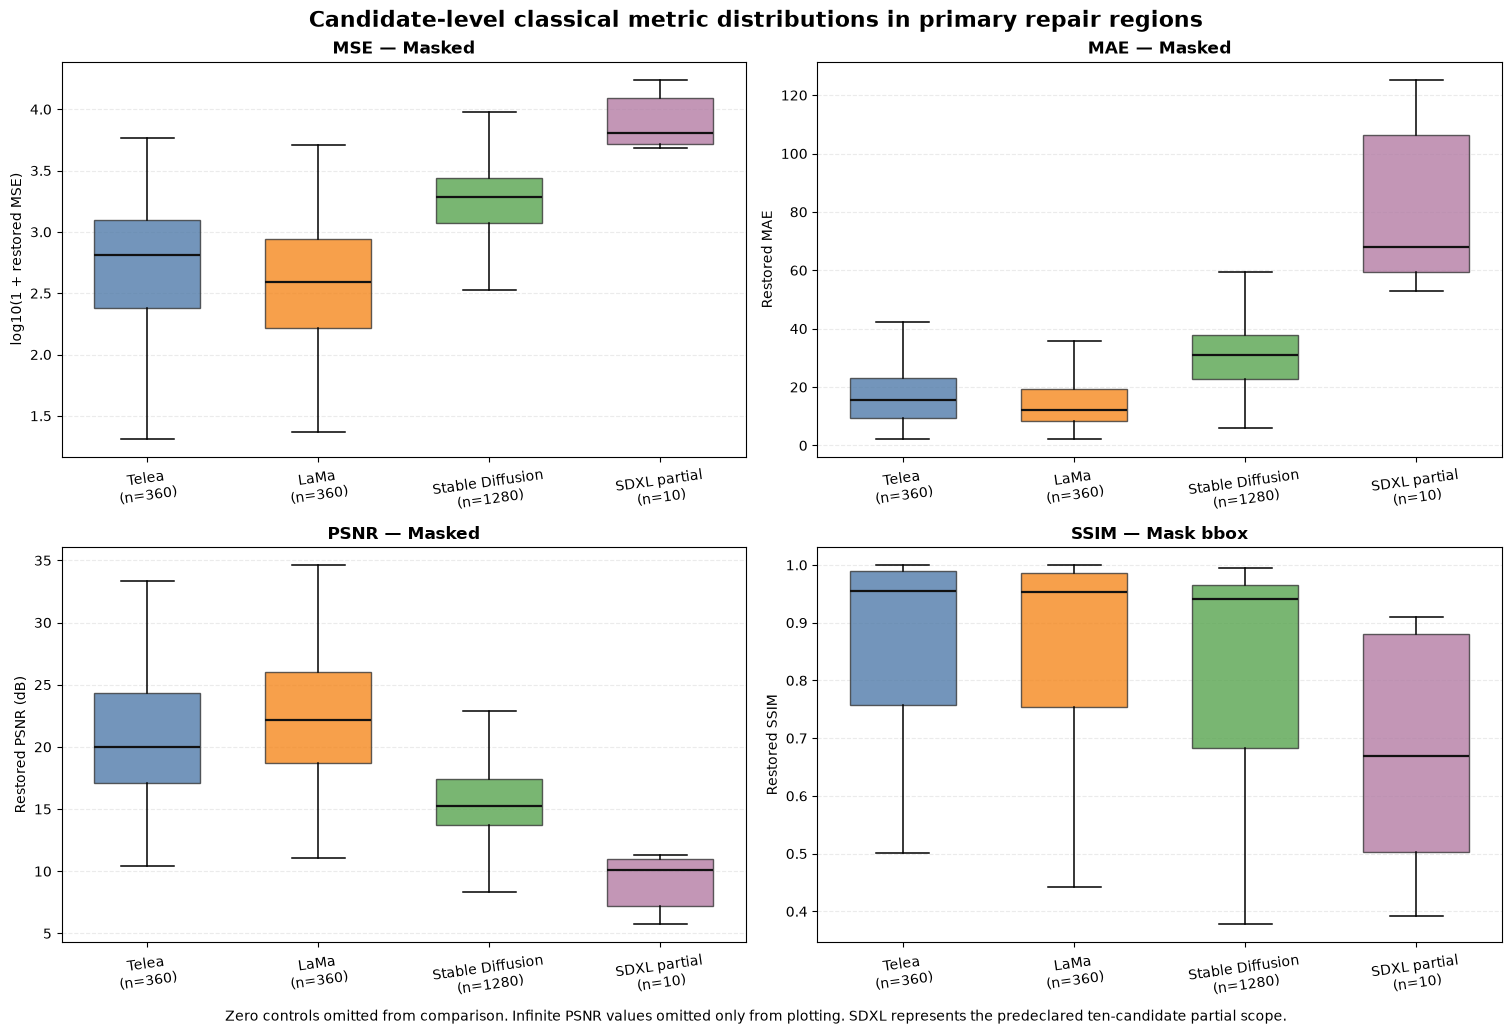

Classical metric distribution figure generated.
Figure path: outputs/13_classical_metrics/figures/classical_metric_distributions.png
Figure bytes: 296035


In [26]:
# ---------------------------------------------------------------------------
# Primary-region restored-value distributions
# ---------------------------------------------------------------------------

figure, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    constrained_layout=True,
)

axes = axes.ravel()

for axis, metric_name in zip(
    axes,
    [
        "mse",
        "mae",
        "psnr",
        "ssim",
    ],
):
    region_id = (
        PRIMARY_REGION_BY_METRIC[
            metric_name
        ]
    )

    metric_plot_df = (
        distribution_source_df.loc[
            distribution_source_df[
                "metric_name"
            ].eq(metric_name)
            & distribution_source_df[
                "region_id"
            ].eq(region_id)
            & distribution_source_df[
                "restored_value_is_finite"
            ]
        ]
    )

    plotted_values = []
    plotted_labels = []
    plotted_colors = []

    for model_id in MODEL_ORDER:
        model_values = (
            metric_plot_df.loc[
                metric_plot_df[
                    "model_id"
                ].eq(model_id),
                "restored_value",
            ]
            .to_numpy(dtype=float)
        )

        if metric_name == "mse":
            display_values = np.log10(
                1.0 + model_values
            )
        else:
            display_values = model_values

        plotted_values.append(
            display_values
        )

        plotted_labels.append(
            MODEL_LABELS[model_id]
            + "\n"
            + f"(n={len(model_values)})"
        )

        plotted_colors.append(
            MODEL_COLORS[model_id]
        )

    boxplot = axis.boxplot(
        plotted_values,
        tick_labels=plotted_labels,
        patch_artist=True,
        showfliers=False,
        widths=0.62,
        medianprops={
            "color": "#111111",
            "linewidth": 1.6,
        },
        whiskerprops={
            "linewidth": 1.1,
        },
        capprops={
            "linewidth": 1.1,
        },
    )

    for patch, color in zip(
        boxplot["boxes"],
        plotted_colors,
    ):
        patch.set_facecolor(color)
        patch.set_alpha(0.78)
        patch.set_edgecolor("#333333")

    axis.set_title(
        (
            METRIC_DISPLAY_NAMES[
                metric_name
            ]
            + " — "
            + REGION_DISPLAY_NAMES[
                region_id
            ]
        ),
        fontsize=12,
        fontweight="bold",
    )

    if metric_name == "mse":
        axis.set_ylabel(
            "log10(1 + restored MSE)"
        )
    elif metric_name == "mae":
        axis.set_ylabel(
            "Restored MAE"
        )
    elif metric_name == "psnr":
        axis.set_ylabel(
            "Restored PSNR (dB)"
        )
    else:
        axis.set_ylabel(
            "Restored SSIM"
        )

    axis.grid(
        axis="y",
        alpha=0.25,
        linestyle="--",
    )

    axis.tick_params(
        axis="x",
        labelrotation=8,
    )

figure.suptitle(
    (
        "Candidate-level classical metric distributions "
        "in primary repair regions"
    ),
    fontsize=16,
    fontweight="bold",
)

figure.text(
    0.5,
    -0.015,
    (
        "Zero controls omitted from comparison. "
        "Infinite PSNR values omitted only from plotting. "
        "SDXL represents the predeclared ten-candidate partial scope."
    ),
    ha="center",
    fontsize=10,
)

figure.savefig(
    OUTPUTS[
        "classical_metric_distributions"
    ],
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(figure)

print("Classical metric distribution figure generated.")
print(
    "Figure path:",
    to_repo_relative(
        OUTPUTS[
            "classical_metric_distributions"
        ],
        PROJECT_ROOT,
    ),
)
print(
    "Figure bytes:",
    OUTPUTS[
        "classical_metric_distributions"
    ].stat().st_size,
)

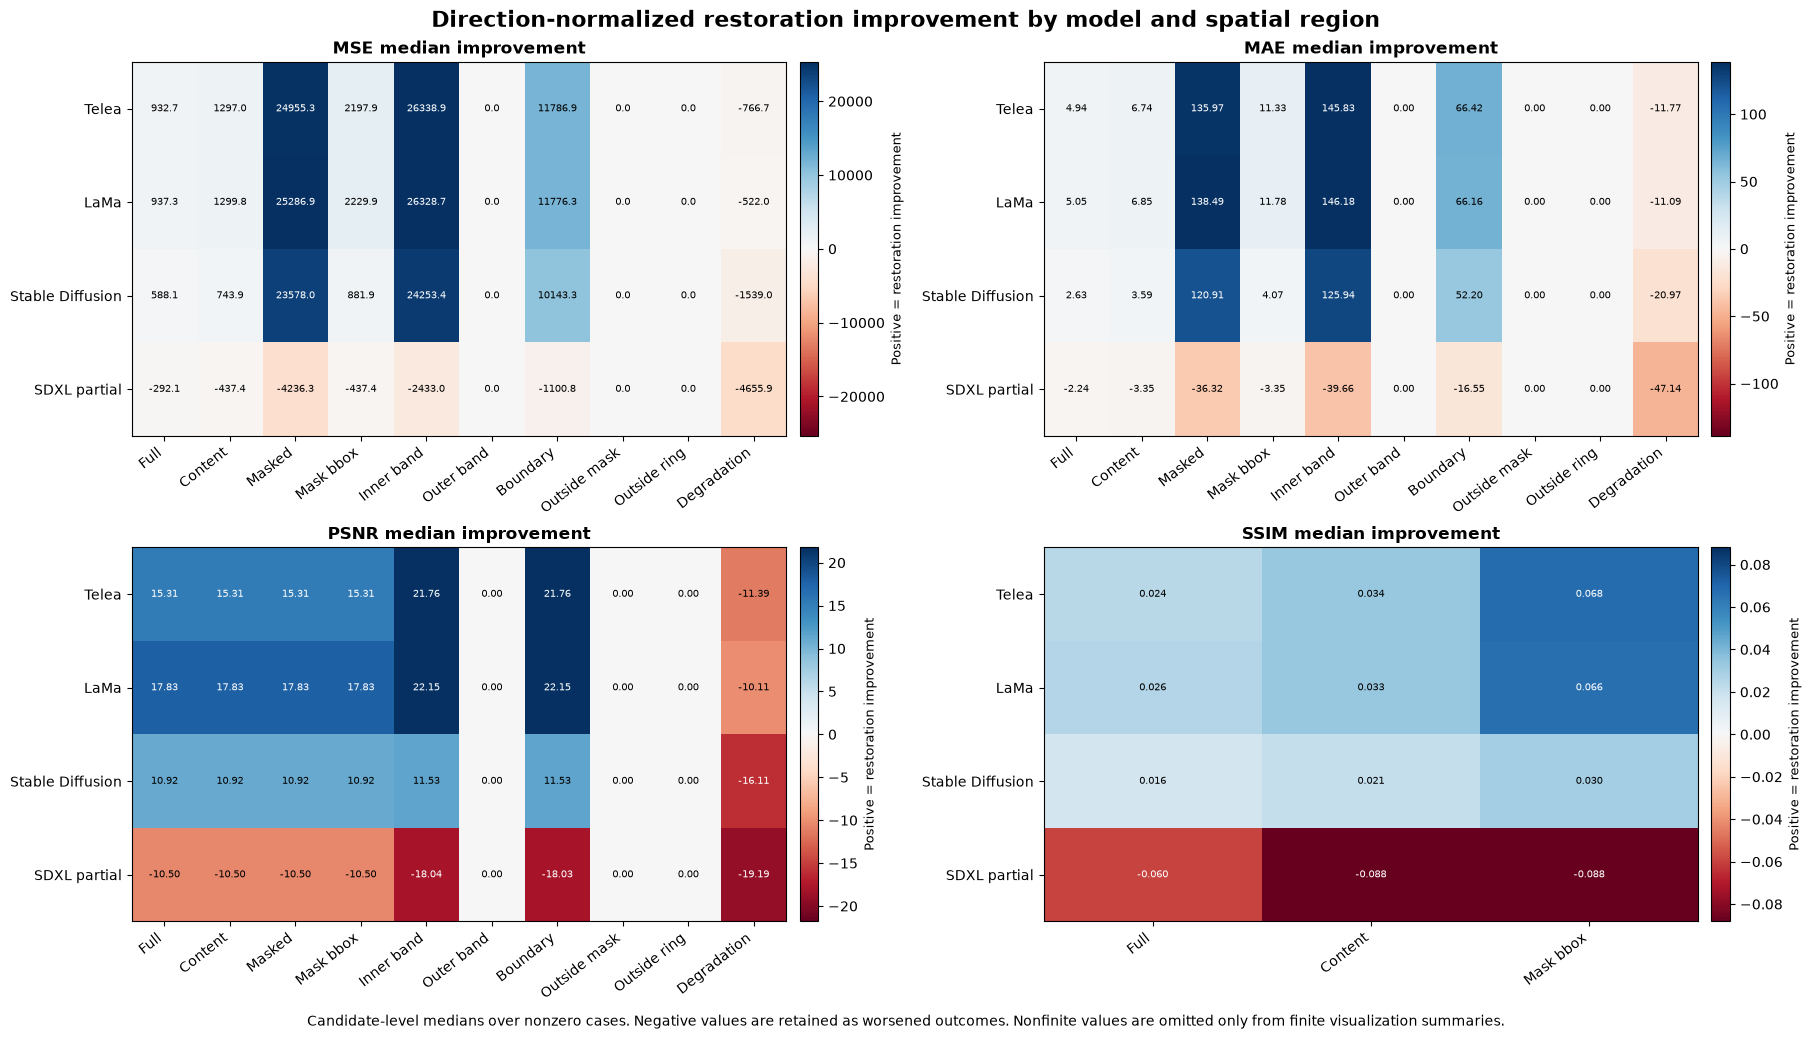

,figure_id,relative_path,format,mode,width,height,size_bytes,pixel_standard_deviation,sha256
0,classical_metric_distributions,outputs/13_classical_metrics/figures/classical...,PNG,RGBA,3023,2068,296035,49.198176,2fc23f22dab5c8d393aa6aa715b12cb44e04ab9c068815...
1,classical_improvement_by_region,outputs/13_classical_metrics/figures/classical...,PNG,RGBA,3622,2078,519844,74.407560,c0476471341b35114f66a247206a1b7be4fc2ad2635f62...


Regional improvement figure generated.
Figure path: outputs/13_classical_metrics/figures/classical_improvement_by_region.png
Saved figure count: 2
All figures are nonblank: True


In [27]:
# ---------------------------------------------------------------------------
# Median improvement heatmaps
# ---------------------------------------------------------------------------

figure, axes = plt.subplots(
    2,
    2,
    figsize=(18, 10),
    constrained_layout=True,
)

axes = axes.ravel()

for axis, metric_name in zip(
    axes,
    [
        "mse",
        "mae",
        "psnr",
        "ssim",
    ],
):
    configured_regions = [
        region_id
        for region_id in (
            CLASSICAL_CONFIG[
                "regions"
            ][
                "compatible_regions"
            ][
                (
                    "ssim"
                    if metric_name == "ssim"
                    else "classical_pixel"
                )
            ]
        )
    ]

    metric_summary_df = (
        improvement_region_summary_df.loc[
            improvement_region_summary_df[
                "metric_name"
            ].eq(metric_name)
        ]
    )

    heatmap_values = (
        metric_summary_df.pivot(
            index="model_id",
            columns="region_id",
            values="median_improvement",
        )
        .reindex(
            index=MODEL_ORDER,
            columns=configured_regions,
        )
    )

    heatmap_array = (
        heatmap_values.to_numpy(
            dtype=float
        )
    )

    finite_heatmap_values = (
        heatmap_array[
            np.isfinite(
                heatmap_array
            )
        ]
    )

    robust_limit = float(
        np.quantile(
            np.abs(
                finite_heatmap_values
            ),
            0.95,
        )
        if finite_heatmap_values.size
        else 1.0
    )

    if robust_limit <= 0:
        robust_limit = 1.0

    normalization = TwoSlopeNorm(
        vmin=-robust_limit,
        vcenter=0.0,
        vmax=robust_limit,
    )

    image = axis.imshow(
        heatmap_array,
        cmap="RdBu",
        norm=normalization,
        aspect="auto",
    )

    axis.set_xticks(
        range(len(configured_regions))
    )

    axis.set_xticklabels(
        [
            REGION_DISPLAY_NAMES[
                region_id
            ]
            for region_id in configured_regions
        ],
        rotation=38,
        ha="right",
    )

    axis.set_yticks(
        range(len(MODEL_ORDER))
    )

    axis.set_yticklabels(
        [
            MODEL_LABELS[model_id]
            for model_id in MODEL_ORDER
        ]
    )

    for row_index in range(
        heatmap_array.shape[0]
    ):
        for column_index in range(
            heatmap_array.shape[1]
        ):
            value = heatmap_array[
                row_index,
                column_index,
            ]

            if not np.isfinite(value):
                label = "n/a"
            elif metric_name == "ssim":
                label = f"{value:.3f}"
            elif metric_name == "mse":
                label = f"{value:.1f}"
            else:
                label = f"{value:.2f}"

            normalized_value = (
                normalization(value)
                if np.isfinite(value)
                else 0.5
            )

            text_color = (
                "white"
                if (
                    normalized_value < 0.22
                    or normalized_value > 0.78
                )
                else "black"
            )

            axis.text(
                column_index,
                row_index,
                label,
                ha="center",
                va="center",
                fontsize=7.5,
                color=text_color,
            )

    axis.set_title(
        (
            METRIC_DISPLAY_NAMES[
                metric_name
            ]
            + " median improvement"
        ),
        fontsize=12,
        fontweight="bold",
    )

    colorbar = figure.colorbar(
        image,
        ax=axis,
        fraction=0.035,
        pad=0.02,
    )

    colorbar.set_label(
        "Positive = restoration improvement",
        fontsize=9,
    )

figure.suptitle(
    (
        "Direction-normalized restoration improvement "
        "by model and spatial region"
    ),
    fontsize=16,
    fontweight="bold",
)

figure.text(
    0.5,
    -0.02,
    (
        "Candidate-level medians over nonzero cases. "
        "Negative values are retained as worsened outcomes. "
        "Nonfinite values are omitted only from finite visualization summaries."
    ),
    ha="center",
    fontsize=10,
)

figure.savefig(
    OUTPUTS[
        "classical_improvement_by_region"
    ],
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(figure)


# ---------------------------------------------------------------------------
# Saved-figure inspection
# ---------------------------------------------------------------------------

def inspect_saved_figure(
    figure_id,
    figure_path,
):
    with Image.open(
        figure_path
    ) as image:
        image.load()

        rgb_array = np.asarray(
            image.convert("RGB"),
            dtype=np.uint8,
        )

        return {
            "figure_id": figure_id,
            "relative_path": (
                to_repo_relative(
                    figure_path,
                    PROJECT_ROOT,
                )
            ),
            "format": image.format,
            "mode": image.mode,
            "width": int(image.width),
            "height": int(image.height),
            "size_bytes": int(
                figure_path.stat().st_size
            ),
            "pixel_standard_deviation": float(
                rgb_array.std()
            ),
            "sha256": sha256_file(
                figure_path
            ),
        }


figure_audit_df = pd.DataFrame(
    [
        inspect_saved_figure(
            "classical_metric_distributions",
            OUTPUTS[
                "classical_metric_distributions"
            ],
        ),
        inspect_saved_figure(
            "classical_improvement_by_region",
            OUTPUTS[
                "classical_improvement_by_region"
            ],
        ),
    ]
)

display(figure_audit_df)

print("Regional improvement figure generated.")
print(
    "Figure path:",
    to_repo_relative(
        OUTPUTS[
            "classical_improvement_by_region"
        ],
        PROJECT_ROOT,
    ),
)
print(
    "Saved figure count:",
    len(figure_audit_df),
)
print(
    "All figures are nonblank:",
    figure_audit_df[
        "pixel_standard_deviation"
    ].gt(0).all(),
)

In [28]:
# ---------------------------------------------------------------------------
# Batch 6 validation
# ---------------------------------------------------------------------------

def add_batch_6_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_6_analysis_visualization",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


expected_nonzero_candidate_counts = {
    str(model_id): int(count)
    for model_id, count in (
        candidate_metadata_df.loc[
            ~candidate_metadata_df[
                "is_zero_control"
            ].fillna(False).astype(bool)
        ]
        .groupby("model_id")[
            "candidate_id"
        ]
        .nunique()
        .items()
    )
}

observed_nonzero_candidate_counts = {
    str(model_id): int(count)
    for model_id, count in (
        comparative_metrics_df
        .groupby("model_id")[
            "candidate_id"
        ]
        .nunique()
        .items()
    )
}

add_batch_6_check(
    "comparative_candidate_scope",
    "Comparative analysis includes every nonzero candidate without selection.",
    expected_nonzero_candidate_counts,
    observed_nonzero_candidate_counts,
    (
        observed_nonzero_candidate_counts
        == expected_nonzero_candidate_counts
    ),
)

add_batch_6_check(
    "distribution_summary_rows",
    "The primary-region distribution summary covers four metrics and four models.",
    16,
    len(distribution_summary_df),
    len(distribution_summary_df) == 16,
)

add_batch_6_check(
    "regional_summary_rows",
    "The regional improvement summary covers every valid model/metric/region combination.",
    132,
    len(
        improvement_region_summary_df
    ),
    (
        len(
            improvement_region_summary_df
        )
        == 132
    ),
)

distribution_models = set(
    distribution_summary_df[
        "model_id"
    ].astype(str)
)

distribution_metrics = set(
    distribution_summary_df[
        "metric_name"
    ].astype(str)
)

add_batch_6_check(
    "distribution_model_coverage",
    "The distribution figure contains all four models.",
    set(MODEL_ORDER),
    distribution_models,
    distribution_models == set(MODEL_ORDER),
)

add_batch_6_check(
    "distribution_metric_coverage",
    "The distribution figure contains all four classical metrics.",
    {
        "mse",
        "mae",
        "psnr",
        "ssim",
    },
    distribution_metrics,
    (
        distribution_metrics
        == {
            "mse",
            "mae",
            "psnr",
            "ssim",
        }
    ),
)

regional_models = set(
    improvement_region_summary_df[
        "model_id"
    ].astype(str)
)

regional_metrics = set(
    improvement_region_summary_df[
        "metric_name"
    ].astype(str)
)

add_batch_6_check(
    "regional_model_coverage",
    "The regional figure contains all four models.",
    set(MODEL_ORDER),
    regional_models,
    regional_models == set(MODEL_ORDER),
)

add_batch_6_check(
    "regional_metric_coverage",
    "The regional figure contains all four metrics.",
    {
        "mse",
        "mae",
        "psnr",
        "ssim",
    },
    regional_metrics,
    (
        regional_metrics
        == {
            "mse",
            "mae",
            "psnr",
            "ssim",
        }
    ),
)

add_batch_6_check(
    "zero_controls_excluded_from_comparative_plots",
    "Comparative plots exclude exact identity controls.",
    0,
    int(
        comparative_metrics_df[
            "is_zero_control"
        ].fillna(False).astype(bool).sum()
    ),
    (
        int(
            comparative_metrics_df[
                "is_zero_control"
            ].fillna(False).astype(bool).sum()
        )
        == 0
    ),
)

for figure_record in figure_audit_df.to_dict(
    "records"
):
    figure_id = figure_record[
        "figure_id"
    ]

    add_batch_6_check(
        f"figure_{figure_id}_format",
        f"{figure_id!r} is a valid PNG image.",
        "PNG",
        figure_record["format"],
        figure_record["format"] == "PNG",
    )

    add_batch_6_check(
        f"figure_{figure_id}_dimensions",
        f"{figure_id!r} has publication-usable dimensions.",
        {
            "minimum_width": 1600,
            "minimum_height": 1000,
        },
        {
            "width": int(
                figure_record["width"]
            ),
            "height": int(
                figure_record["height"]
            ),
        },
        (
            int(
                figure_record["width"]
            )
            >= 1600
            and int(
                figure_record["height"]
            )
            >= 1000
        ),
    )

    add_batch_6_check(
        f"figure_{figure_id}_nonblank",
        f"{figure_id!r} contains nonblank visual content.",
        "greater than zero",
        figure_record[
            "pixel_standard_deviation"
        ],
        (
            float(
                figure_record[
                    "pixel_standard_deviation"
                ]
            )
            > 0
        ),
    )

    add_batch_6_check(
        f"figure_{figure_id}_checksum",
        f"{figure_id!r} has a complete SHA-256 checksum.",
        64,
        len(
            str(
                figure_record["sha256"]
            )
        ),
        (
            len(
                str(
                    figure_record["sha256"]
                )
            )
            == 64
        ),
    )

figure_checksums_unique = (
    figure_audit_df[
        "sha256"
    ].nunique()
    == len(figure_audit_df)
)

add_batch_6_check(
    "figure_checksums_unique",
    "The two canonical figures are distinct artifacts.",
    True,
    figure_checksums_unique,
    figure_checksums_unique,
)

add_batch_6_check(
    "sdxl_present_in_both_figures",
    "SDXL partial evidence appears in both visualization summaries.",
    True,
    {
        "distribution": (
            "sdxl_inpainting"
            in distribution_models
        ),
        "regional": (
            "sdxl_inpainting"
            in regional_models
        ),
    },
    (
        "sdxl_inpainting"
        in distribution_models
        and "sdxl_inpainting"
        in regional_models
    ),
)

canonical_figure_paths = {
    OUTPUTS[
        "classical_metric_distributions"
    ].resolve(),
    OUTPUTS[
        "classical_improvement_by_region"
    ].resolve(),
}

allowed_temporary_paths = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT
        / "work"
    ).glob(
        "classical_metrics_checkpoint*.csv"
    )
}

observed_notebook_files = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

unexpected_notebook_files = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        observed_notebook_files
        - canonical_figure_paths
        - allowed_temporary_paths
    )
)

add_batch_6_check(
    "analysis_output_ownership",
    "Batch 6 creates only the two figures and notebook-owned checkpoints.",
    [],
    unexpected_notebook_files,
    not unexpected_notebook_files,
)

add_batch_6_check(
    "canonical_metric_table_deferred",
    "The canonical metric CSV remains deferred until final persistence.",
    False,
    OUTPUTS[
        "classical_metrics"
    ].exists(),
    not OUTPUTS[
        "classical_metrics"
    ].exists(),
)

add_batch_6_check(
    "nonfinite_plotting_policy",
    "Nonfinite evidence is retained in metrics and only omitted from finite plot coordinates.",
    {
        "metric_rows_retained": len(
            classical_metrics_df
        ),
        "plotting_policy": (
            "finite coordinates only"
        ),
    },
    {
        "metric_rows_retained": len(
            classical_metrics_df
        ),
        "nonfinite_distribution_values": int(
            (
                ~distribution_source_df[
                    "restored_value_is_finite"
                ]
            ).sum()
        ),
        "nonfinite_improvement_values": int(
            (
                ~comparative_metrics_df[
                    "improvement_is_finite"
                ]
            ).sum()
        ),
    },
    (
        len(classical_metrics_df)
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
    severity="info",
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_6_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq(
            "batch_6_analysis_visualization"
        )
    ]
    .reset_index(drop=True)
)

display(batch_6_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 6 analysis and visualization passed.")
print(
    "Batch 6 validation checks:",
    len(batch_6_validation_df),
)
print(
    "Blocking failures across Batches 1–6:",
    len(VALIDATION.blocking_failures),
)
print(
    "Canonical figures:",
    len(figure_audit_df),
)
print(
    "Extra summary CSV files written:",
    0,
)
print(
    "Canonical metric persistence remains deferred."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_analysis_visualization,comparative_candidate_scope,Comparative analysis includes every nonzero ca...,blocking,"{""lama"": 360, ""opencv_telea"": 360, ""sdxl_inpai...","{""lama"": 360, ""opencv_telea"": 360, ""sdxl_inpai...",True,
1,batch_6_analysis_visualization,distribution_summary_rows,The primary-region distribution summary covers...,blocking,16,16,True,
2,batch_6_analysis_visualization,regional_summary_rows,The regional improvement summary covers every ...,blocking,132,132,True,
3,batch_6_analysis_visualization,distribution_model_coverage,The distribution figure contains all four models.,blocking,"""{'stable_diffusion_inpainting', 'sdxl_inpaint...","""{'stable_diffusion_inpainting', 'sdxl_inpaint...",True,
4,batch_6_analysis_visualization,distribution_metric_coverage,The distribution figure contains all four clas...,blocking,"""{'psnr', 'mse', 'ssim', 'mae'}""","""{'psnr', 'mse', 'ssim', 'mae'}""",True,
5,batch_6_analysis_visualization,regional_model_coverage,The regional figure contains all four models.,blocking,"""{'stable_diffusion_inpainting', 'sdxl_inpaint...","""{'stable_diffusion_inpainting', 'sdxl_inpaint...",True,
6,batch_6_analysis_visualization,regional_metric_coverage,The regional figure contains all four metrics.,blocking,"""{'psnr', 'mse', 'ssim', 'mae'}""","""{'psnr', 'mse', 'ssim', 'mae'}""",True,
7,batch_6_analysis_visualization,zero_controls_excluded_from_comparative_plots,Comparative plots exclude exact identity contr...,blocking,0,0,True,
8,batch_6_analysis_visualization,figure_classical_metric_distributions_format,'classical_metric_distributions' is a valid PN...,blocking,PNG,PNG,True,
9,batch_6_analysis_visualization,figure_classical_metric_distributions_dimensions,'classical_metric_distributions' has publicati...,blocking,"{""minimum_height"": 1000, ""minimum_width"": 1600}","{""height"": 2068, ""width"": 3023}",True,


Batch 6 analysis and visualization passed.
Batch 6 validation checks: 21
Blocking failures across Batches 1–6: 0
Canonical figures: 2
Extra summary CSV files written: 0
Canonical metric persistence remains deferred.


## Batch 7 — Canonical metric persistence

This batch atomically persists the scientifically approved 63,018-row classical metric table and reloads it from disk.

The reload must preserve schema, candidate coverage, deterministic identifiers, finite numerical values, explicit positive infinities, improvement values, and categorical provenance.

Manifests, final validation persistence, project-path registry updates, and temporary-work cleanup remain deferred to the final handoff batch.

In [29]:
# ---------------------------------------------------------------------------
# Windows-safe canonical CSV persistence
# ---------------------------------------------------------------------------

CANONICAL_WRITE_ATTEMPTS = 8
CANONICAL_INITIAL_RETRY_SECONDS = 0.125


def write_canonical_dataframe_atomic(
    dataframe,
    destination,
):
    destination = Path(
        destination
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    retry_seconds = (
        CANONICAL_INITIAL_RETRY_SECONDS
    )

    last_error = None

    for attempt_number in range(
        1,
        CANONICAL_WRITE_ATTEMPTS + 1,
    ):
        temporary_path = (
            destination.parent
            / (
                destination.name
                + "."
                + uuid4().hex
                + ".tmp"
            )
        )

        try:
            dataframe.to_csv(
                temporary_path,
                index=False,
                lineterminator="\n",
            )

            os.replace(
                temporary_path,
                destination,
            )

            return {
                "path": destination,
                "attempts": attempt_number,
                "temporary_path": temporary_path,
            }

        except PermissionError as exc:
            last_error = exc

            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            if (
                attempt_number
                < CANONICAL_WRITE_ATTEMPTS
            ):
                time.sleep(
                    retry_seconds
                )

                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

        except Exception:
            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            raise

    raise PermissionError(
        "Could not atomically persist canonical "
        f"metrics after {CANONICAL_WRITE_ATTEMPTS} "
        f"attempts: {last_error}"
    )


canonical_write_result = (
    write_canonical_dataframe_atomic(
        classical_metrics_df.loc[
            :,
            CLASSICAL_METRICS_COLUMNS,
        ],
        OUTPUTS["classical_metrics"],
    )
)

canonical_metrics_reloaded_df = (
    pd.read_csv(
        OUTPUTS["classical_metrics"],
        low_memory=False,
    )
)

print("Canonical classical metric table persisted.")
print(
    "Canonical path:",
    to_repo_relative(
        OUTPUTS["classical_metrics"],
        PROJECT_ROOT,
    ),
)
print(
    "Atomic write attempts:",
    canonical_write_result[
        "attempts"
    ],
)
print(
    "Persisted bytes:",
    OUTPUTS[
        "classical_metrics"
    ].stat().st_size,
)
print(
    "Reloaded rows:",
    len(canonical_metrics_reloaded_df),
)

Canonical classical metric table persisted.
Canonical path: outputs/13_classical_metrics/metrics/classical_metrics.csv
Atomic write attempts: 1
Persisted bytes: 18773255
Reloaded rows: 63018


In [30]:
# ---------------------------------------------------------------------------
# Canonical schema and scientific validation
# ---------------------------------------------------------------------------

canonical_metrics_schema = (
    validate_dataframe(
        canonical_metrics_reloaded_df,
        CLASSICAL_METRICS_SCHEMA,
        allow_extra_columns=False,
    )
)

canonical_metrics_validation = (
    validate_classical_metrics(
        canonical_metrics_reloaded_df,
        evaluation_worklist_df,
        expected_rows=EXPECTED_COUNTS[
            "total_metric_rows"
        ],
    )
)


# ---------------------------------------------------------------------------
# Order-independent table comparison
# ---------------------------------------------------------------------------

source_metrics_sorted_df = (
    classical_metrics_df
    .sort_values(
        "metric_row_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

canonical_metrics_sorted_df = (
    canonical_metrics_reloaded_df
    .sort_values(
        "metric_row_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

canonical_identifier_match = bool(
    source_metrics_sorted_df[
        "metric_row_id"
    ].astype(str).equals(
        canonical_metrics_sorted_df[
            "metric_row_id"
        ].astype(str)
    )
)

NUMERIC_METRIC_COLUMNS = [
    "region_pixel_count",
    "damaged_value",
    "restored_value",
    "improvement_value",
]

canonical_numeric_match = bool(
    np.allclose(
        source_metrics_sorted_df[
            NUMERIC_METRIC_COLUMNS
        ].to_numpy(dtype=float),
        canonical_metrics_sorted_df[
            NUMERIC_METRIC_COLUMNS
        ].to_numpy(dtype=float),
        rtol=1e-12,
        atol=1e-12,
        equal_nan=True,
    )
)

CATEGORICAL_METRIC_COLUMNS = [
    column
    for column in (
        CLASSICAL_METRICS_COLUMNS
    )
    if column
    not in {
        *NUMERIC_METRIC_COLUMNS,
        "issue",
    }
]

canonical_categorical_match = all(
    source_metrics_sorted_df[
        column
    ]
    .fillna("")
    .astype(str)
    .equals(
        canonical_metrics_sorted_df[
            column
        ]
        .fillna("")
        .astype(str)
    )
    for column in (
        CATEGORICAL_METRIC_COLUMNS
    )
)

canonical_issue_match = bool(
    source_metrics_sorted_df[
        "issue"
    ]
    .fillna("")
    .astype(str)
    .equals(
        canonical_metrics_sorted_df[
            "issue"
        ]
        .fillna("")
        .astype(str)
    )
)


# ---------------------------------------------------------------------------
# Infinity and missing-value preservation
# ---------------------------------------------------------------------------

source_positive_infinity_count = int(
    np.isposinf(
        source_metrics_sorted_df[
            [
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ].to_numpy(dtype=float)
    ).sum()
)

canonical_positive_infinity_count = int(
    np.isposinf(
        canonical_metrics_sorted_df[
            [
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ].to_numpy(dtype=float)
    ).sum()
)

source_negative_infinity_count = int(
    np.isneginf(
        source_metrics_sorted_df[
            [
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ].to_numpy(dtype=float)
    ).sum()
)

canonical_negative_infinity_count = int(
    np.isneginf(
        canonical_metrics_sorted_df[
            [
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ].to_numpy(dtype=float)
    ).sum()
)

canonical_unexpected_numeric_missing = int(
    canonical_metrics_reloaded_df.loc[
        canonical_metrics_reloaded_df[
            "status"
        ].eq("ok"),
        [
            "damaged_value",
            "restored_value",
            "improvement_value",
        ],
    ].isna().sum().sum()
)


# ---------------------------------------------------------------------------
# Canonical file evidence
# ---------------------------------------------------------------------------

canonical_metrics_file_audit_df = (
    pd.DataFrame(
        [
            {
                "artifact_key": (
                    "classical_metrics.metrics"
                ),
                "relative_path": (
                    to_repo_relative(
                        OUTPUTS[
                            "classical_metrics"
                        ],
                        PROJECT_ROOT,
                    )
                ),
                "format": "csv",
                "schema_version": (
                    CLASSICAL_METRICS_SCHEMA.version
                ),
                "row_count": len(
                    canonical_metrics_reloaded_df
                ),
                "column_count": len(
                    canonical_metrics_reloaded_df.columns
                ),
                "size_bytes": int(
                    OUTPUTS[
                        "classical_metrics"
                    ].stat().st_size
                ),
                "sha256": sha256_file(
                    OUTPUTS[
                        "classical_metrics"
                    ]
                ),
                "validation_passed": (
                    canonical_metrics_validation[
                        "passed"
                    ]
                ),
            }
        ]
    )
)

display(canonical_metrics_file_audit_df)

print("Canonical metric round-trip validation complete.")
print(
    "Schema passed:",
    canonical_metrics_schema.passed,
)
print(
    "Scientific validation passed:",
    canonical_metrics_validation[
        "passed"
    ],
)
print(
    "Identifiers preserved:",
    canonical_identifier_match,
)
print(
    "Numeric values preserved:",
    canonical_numeric_match,
)
print(
    "Categorical values preserved:",
    canonical_categorical_match,
)
print(
    "Issue field preserved:",
    canonical_issue_match,
)
print(
    "Positive infinities:",
    canonical_positive_infinity_count,
)
print(
    "Negative infinities:",
    canonical_negative_infinity_count,
)
print(
    "Unexpected numerical missing values:",
    canonical_unexpected_numeric_missing,
)

,artifact_key,relative_path,format,schema_version,row_count,column_count,size_bytes,sha256,validation_passed
0,classical_metrics.metrics,outputs/13_classical_metrics/metrics/classical...,csv,classical_metrics.v1,63018,16,18773255,bbb98fc5ea65cb5c2bb93a7b51cca66e6bcbd1a7795285...,True


Canonical metric round-trip validation complete.
Schema passed: True
Scientific validation passed: True
Identifiers preserved: True
Numeric values preserved: True
Categorical values preserved: True
Issue field preserved: True
Positive infinities: 11332
Negative infinities: 0
Unexpected numerical missing values: 0


In [31]:
# ---------------------------------------------------------------------------
# Batch 7 validation
# ---------------------------------------------------------------------------

def add_batch_7_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_7_canonical_persistence",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_7_check(
    "canonical_metrics_exists",
    "The canonical classical metric CSV exists.",
    True,
    OUTPUTS[
        "classical_metrics"
    ].is_file(),
    OUTPUTS[
        "classical_metrics"
    ].is_file(),
)

add_batch_7_check(
    "canonical_metrics_schema",
    "The canonical CSV satisfies classical_metrics.v1.",
    True,
    canonical_metrics_schema.to_dict(),
    canonical_metrics_schema.passed,
)

add_batch_7_check(
    "canonical_metrics_validation",
    "The canonical CSV passes complete scientific structural validation.",
    True,
    canonical_metrics_validation,
    canonical_metrics_validation[
        "passed"
    ],
)

add_batch_7_check(
    "canonical_metric_row_count",
    "The canonical CSV contains exactly 63,018 rows.",
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
    len(canonical_metrics_reloaded_df),
    (
        len(canonical_metrics_reloaded_df)
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
)

add_batch_7_check(
    "canonical_metric_column_order",
    "The canonical CSV uses the exact versioned column order.",
    list(CLASSICAL_METRICS_COLUMNS),
    list(
        canonical_metrics_reloaded_df.columns
    ),
    (
        list(
            canonical_metrics_reloaded_df.columns
        )
        == list(
            CLASSICAL_METRICS_COLUMNS
        )
    ),
)

add_batch_7_check(
    "canonical_identifier_roundtrip",
    "Canonical persistence preserves all deterministic metric-row identifiers.",
    True,
    canonical_identifier_match,
    canonical_identifier_match,
)

add_batch_7_check(
    "canonical_numeric_roundtrip",
    "Canonical persistence preserves numerical values and explicit infinities.",
    True,
    canonical_numeric_match,
    canonical_numeric_match,
)

add_batch_7_check(
    "canonical_categorical_roundtrip",
    "Canonical persistence preserves categorical provenance.",
    True,
    canonical_categorical_match,
    canonical_categorical_match,
)

add_batch_7_check(
    "canonical_issue_roundtrip",
    "Canonical persistence preserves explicit issue values.",
    True,
    canonical_issue_match,
    canonical_issue_match,
)

add_batch_7_check(
    "canonical_positive_infinity_policy",
    "Canonical persistence preserves every positive infinity.",
    source_positive_infinity_count,
    canonical_positive_infinity_count,
    (
        canonical_positive_infinity_count
        == source_positive_infinity_count
    ),
)

add_batch_7_check(
    "canonical_negative_infinity_policy",
    "Canonical persistence introduces no negative infinity.",
    source_negative_infinity_count,
    canonical_negative_infinity_count,
    (
        canonical_negative_infinity_count
        == source_negative_infinity_count
        == 0
    ),
)

add_batch_7_check(
    "canonical_missing_value_policy",
    "Successful canonical rows contain no unexpected numerical missingness.",
    0,
    canonical_unexpected_numeric_missing,
    canonical_unexpected_numeric_missing == 0,
)

canonical_metric_checksum = str(
    canonical_metrics_file_audit_df.iloc[
        0
    ][
        "sha256"
    ]
)

add_batch_7_check(
    "canonical_metric_checksum",
    "The canonical metric CSV has a complete SHA-256 checksum.",
    64,
    len(canonical_metric_checksum),
    len(canonical_metric_checksum) == 64,
)

add_batch_7_check(
    "canonical_metric_file_size",
    "The canonical metric CSV is nonempty.",
    "greater than zero",
    int(
        OUTPUTS[
            "classical_metrics"
        ].stat().st_size
    ),
    (
        OUTPUTS[
            "classical_metrics"
        ].stat().st_size
        > 0
    ),
)

canonical_figure_files_present = all(
    OUTPUTS[figure_key].is_file()
    for figure_key in (
        "classical_metric_distributions",
        "classical_improvement_by_region",
    )
)

add_batch_7_check(
    "canonical_figures_retained",
    "Both validated canonical figures remain available.",
    True,
    canonical_figure_files_present,
    canonical_figure_files_present,
)

allowed_batch_7_files = {
    OUTPUTS[
        "classical_metrics"
    ].resolve(),
    OUTPUTS[
        "classical_metric_distributions"
    ].resolve(),
    OUTPUTS[
        "classical_improvement_by_region"
    ].resolve(),
}

allowed_batch_7_files.update(
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT
        / "work"
    ).glob(
        "classical_metrics_checkpoint*.csv"
    )
)

observed_batch_7_files = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

unexpected_batch_7_files = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        observed_batch_7_files
        - allowed_batch_7_files
    )
)

add_batch_7_check(
    "canonical_persistence_output_scope",
    "Batch 7 retains only approved canonical artifacts and temporary checkpoints.",
    [],
    unexpected_batch_7_files,
    not unexpected_batch_7_files,
)

final_handoff_outputs_exist_early = {
    output_key: OUTPUTS[
        output_key
    ].exists()
    for output_key in (
        "run_manifest",
        "artifacts",
        "validation",
    )
}

add_batch_7_check(
    "handoff_outputs_deferred",
    "Final manifests and validation remain deferred to the handoff batch.",
    {
        "run_manifest": False,
        "artifacts": False,
        "validation": False,
    },
    final_handoff_outputs_exist_early,
    (
        final_handoff_outputs_exist_early
        == {
            "run_manifest": False,
            "artifacts": False,
            "validation": False,
        }
    ),
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_7_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq(
            "batch_7_canonical_persistence"
        )
    ]
    .reset_index(drop=True)
)

display(batch_7_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 7 canonical metric persistence passed.")
print(
    "Batch 7 validation checks:",
    len(batch_7_validation_df),
)
print(
    "Blocking failures across Batches 1–7:",
    len(VALIDATION.blocking_failures),
)
print(
    "Canonical metric rows:",
    len(canonical_metrics_reloaded_df),
)
print(
    "Canonical metric checksum:",
    canonical_metric_checksum,
)
print(
    "Temporary checkpoint retained until final handoff."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_canonical_persistence,canonical_metrics_exists,The canonical classical metric CSV exists.,blocking,True,True,True,
1,batch_7_canonical_persistence,canonical_metrics_schema,The canonical CSV satisfies classical_metrics.v1.,blocking,True,"{""column_count"": 16, ""duplicate_primary_key_ro...",True,
2,batch_7_canonical_persistence,canonical_metrics_validation,The canonical CSV passes complete scientific s...,blocking,True,"{""error_row_count"": 0, ""expected_row_count"": 6...",True,
3,batch_7_canonical_persistence,canonical_metric_row_count,"The canonical CSV contains exactly 63,018 rows.",blocking,63018,63018,True,
4,batch_7_canonical_persistence,canonical_metric_column_order,The canonical CSV uses the exact versioned col...,blocking,"[""metric_row_id"", ""case_id"", ""candidate_id"", ""...","[""metric_row_id"", ""case_id"", ""candidate_id"", ""...",True,
5,batch_7_canonical_persistence,canonical_identifier_roundtrip,Canonical persistence preserves all determinis...,blocking,True,True,True,
6,batch_7_canonical_persistence,canonical_numeric_roundtrip,Canonical persistence preserves numerical valu...,blocking,True,True,True,
7,batch_7_canonical_persistence,canonical_categorical_roundtrip,Canonical persistence preserves categorical pr...,blocking,True,True,True,
8,batch_7_canonical_persistence,canonical_issue_roundtrip,Canonical persistence preserves explicit issue...,blocking,True,True,True,
9,batch_7_canonical_persistence,canonical_positive_infinity_policy,Canonical persistence preserves every positive...,blocking,11332,11332,True,


Batch 7 canonical metric persistence passed.
Batch 7 validation checks: 17
Blocking failures across Batches 1–7: 0
Canonical metric rows: 63018
Canonical metric checksum: bbb98fc5ea65cb5c2bb93a7b51cca66e6bcbd1a77952859e65460899fa7f12c1
Temporary checkpoint retained until final handoff.


## Batch 8 — Final handoff and completion gate

This batch verifies Notebook 13 against every responsibility in the approved notebook roadmap, writes the consolidated validation and universal manifests, removes the validated temporary checkpoint, and updates the authoritative project-path registry.

The completion gate requires exactly six canonical Notebook 13 files, four registered downstream artifacts, zero temporary work files, zero blocking failures, and complete checksum agreement.

The project inventory is refreshed externally only after this notebook has been saved and independently inspected.

In [32]:
# ---------------------------------------------------------------------------
# Final handoff helpers
# ---------------------------------------------------------------------------

import os
import time
from uuid import uuid4

from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
)

from restoration_eval.paths import (
    upsert_project_path_artifacts,
    write_project_paths_registry,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    validate_dataframe,
)


FINAL_DATASET_SCOPE = "controlled_50"
FINAL_EXPERIMENT_SCOPE = (
    "cross_experiment_classical_metrics"
)
FINAL_ARTIFACT_RECORD_COUNT = 4
FINAL_CANONICAL_FILE_COUNT = 6


def write_json_atomic_retry(
    payload,
    destination,
    attempts=8,
    initial_retry_seconds=0.125,
):
    destination = Path(destination)
    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    retry_seconds = float(
        initial_retry_seconds
    )
    last_error = None

    for attempt_number in range(
        1,
        int(attempts) + 1,
    ):
        temporary_path = (
            destination.parent
            / (
                destination.name
                + "."
                + uuid4().hex
                + ".tmp"
            )
        )

        try:
            temporary_path.write_text(
                json.dumps(
                    payload,
                    indent=2,
                    ensure_ascii=False,
                    default=str,
                )
                + "\n",
                encoding="utf-8",
                newline="\n",
            )

            os.replace(
                temporary_path,
                destination,
            )

            return {
                "path": destination,
                "attempts": attempt_number,
            }

        except PermissionError as exc:
            last_error = exc

            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            if attempt_number < attempts:
                time.sleep(retry_seconds)
                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

        except Exception:
            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            raise

    raise PermissionError(
        "Could not atomically persist "
        f"{destination} after {attempts} attempts: "
        f"{last_error}"
    )


def call_with_permission_retry(
    operation,
    *args,
    attempts=8,
    initial_retry_seconds=0.125,
    **kwargs,
):
    retry_seconds = float(
        initial_retry_seconds
    )
    last_error = None

    for attempt_number in range(
        1,
        int(attempts) + 1,
    ):
        try:
            result = operation(
                *args,
                **kwargs,
            )

            return {
                "result": result,
                "attempts": attempt_number,
            }

        except PermissionError as exc:
            last_error = exc

            if attempt_number < attempts:
                time.sleep(retry_seconds)
                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

    raise PermissionError(
        "The handoff operation failed after "
        f"{attempts} attempts: {last_error}"
    )


def validation_stage_summary():
    frame = VALIDATION.to_dataframe()
    summaries = {}

    for stage, stage_df in frame.groupby(
        "validation_stage",
        sort=False,
    ):
        failed_mask = (
            ~stage_df["passed"].astype(bool)
        )

        blocking_mask = (
            failed_mask
            & stage_df["severity"].eq(
                "blocking"
            )
        )

        error_mask = (
            failed_mask
            & stage_df["severity"].isin(
                {"error", "blocking"}
            )
        )

        summaries[str(stage)] = {
            "check_count": int(
                len(stage_df)
            ),
            "passed_count": int(
                stage_df["passed"].astype(
                    bool
                ).sum()
            ),
            "failed_count": int(
                failed_mask.sum()
            ),
            "blocking_failure_count": int(
                blocking_mask.sum()
            ),
            "overall_passed": bool(
                not error_mask.any()
            ),
            "failed_check_ids": (
                stage_df.loc[
                    failed_mask,
                    "check_id",
                ]
                .astype(str)
                .tolist()
            ),
        }

    summaries["overall"] = (
        VALIDATION.summary()
    )

    return summaries


def build_notebook_13_artifact_records():
    validation_rows = len(
        VALIDATION.to_dataframe()
    )

    return [
        build_artifact_record(
            artifact_key=(
                "classical_metrics.metrics"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS[
                "classical_metrics"
            ],
            artifact_type="table",
            artifact_role=(
                "primary_downstream_evidence"
            ),
            schema_version=(
                CLASSICAL_METRICS_SCHEMA.version
            ),
            dataset_scope=(
                FINAL_DATASET_SCOPE
            ),
            experiment_id=(
                FINAL_EXPERIMENT_SCOPE
            ),
            validation_status="passed",
            row_count=len(
                canonical_metrics_reloaded_df
            ),
            project_root=PROJECT_ROOT,
        ),
        build_artifact_record(
            artifact_key=(
                "classical_metrics.distributions"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS[
                "classical_metric_distributions"
            ],
            artifact_type="figure",
            artifact_role=(
                "reporting_visualization"
            ),
            schema_version=(
                "figure.classical_metric_distributions.v1"
            ),
            dataset_scope=(
                FINAL_DATASET_SCOPE
            ),
            experiment_id=(
                FINAL_EXPERIMENT_SCOPE
            ),
            validation_status="passed",
            row_count=1,
            project_root=PROJECT_ROOT,
        ),
        build_artifact_record(
            artifact_key=(
                "classical_metrics.improvement_by_region"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS[
                "classical_improvement_by_region"
            ],
            artifact_type="figure",
            artifact_role=(
                "reporting_visualization"
            ),
            schema_version=(
                "figure.classical_improvement_by_region.v1"
            ),
            dataset_scope=(
                FINAL_DATASET_SCOPE
            ),
            experiment_id=(
                FINAL_EXPERIMENT_SCOPE
            ),
            validation_status="passed",
            row_count=1,
            project_root=PROJECT_ROOT,
        ),
        build_artifact_record(
            artifact_key=(
                "validation.13_classical_metrics"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS["validation"],
            artifact_type="table",
            artifact_role=(
                "validation_evidence"
            ),
            schema_version=(
                "validation_checks.v1"
            ),
            dataset_scope=(
                FINAL_DATASET_SCOPE
            ),
            experiment_id=(
                FINAL_EXPERIMENT_SCOPE
            ),
            validation_status="passed",
            row_count=validation_rows,
            project_root=PROJECT_ROOT,
        ),
    ]


def build_notebook_13_run_outputs(
    validation_rows,
):
    return [
        {
            "artifact_key": (
                "classical_metrics.metrics"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["classical_metrics"],
                PROJECT_ROOT,
            ),
            "artifact_type": "table",
            "artifact_role": (
                "primary_downstream_evidence"
            ),
            "schema_version": (
                CLASSICAL_METRICS_SCHEMA.version
            ),
            "expected_row_count": int(
                EXPECTED_COUNTS[
                    "total_metric_rows"
                ]
            ),
            "canonical": True,
        },
        {
            "artifact_key": (
                "classical_metrics.distributions"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "classical_metric_distributions"
                ],
                PROJECT_ROOT,
            ),
            "artifact_type": "figure",
            "artifact_role": (
                "reporting_visualization"
            ),
            "schema_version": (
                "figure.classical_metric_distributions.v1"
            ),
            "expected_row_count": 1,
            "canonical": True,
        },
        {
            "artifact_key": (
                "classical_metrics.improvement_by_region"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "classical_improvement_by_region"
                ],
                PROJECT_ROOT,
            ),
            "artifact_type": "figure",
            "artifact_role": (
                "reporting_visualization"
            ),
            "schema_version": (
                "figure.classical_improvement_by_region.v1"
            ),
            "expected_row_count": 1,
            "canonical": True,
        },
        {
            "artifact_key": (
                "validation.13_classical_metrics"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["validation"],
                PROJECT_ROOT,
            ),
            "artifact_type": "table",
            "artifact_role": (
                "validation_evidence"
            ),
            "schema_version": (
                "validation_checks.v1"
            ),
            "expected_row_count": int(
                validation_rows
            ),
            "canonical": True,
        },
        {
            "artifact_key": (
                "classical_metrics.artifacts"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["artifacts"],
                PROJECT_ROOT,
            ),
            "artifact_type": "manifest",
            "artifact_role": (
                "artifact_discovery"
            ),
            "schema_version": (
                ARTIFACT_MANIFEST_SCHEMA.version
            ),
            "expected_row_count": (
                FINAL_ARTIFACT_RECORD_COUNT
            ),
            "canonical": True,
        },
        {
            "artifact_key": (
                "classical_metrics.run_manifest"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["run_manifest"],
                PROJECT_ROOT,
            ),
            "artifact_type": "manifest",
            "artifact_role": "run_provenance",
            "schema_version": (
                "run_manifest.v1"
            ),
            "expected_row_count": 1,
            "canonical": True,
        },
    ]


def build_notebook_13_run_manifest(
    run_status,
    completion_gate_passed,
):
    validation_rows = len(
        VALIDATION.to_dataframe()
    )

    model_candidate_counts = {
        str(model_id): int(count)
        for model_id, count in (
            evaluation_worklist_df[
                "model_id"
            ]
            .value_counts()
            .sort_index()
            .items()
        )
    }

    metric_row_counts = {
        str(metric_name): int(count)
        for metric_name, count in (
            canonical_metrics_reloaded_df[
                "metric_name"
            ]
            .value_counts()
            .sort_index()
            .items()
        )
    }

    positive_infinities = int(
        np.isposinf(
            pd.to_numeric(
                canonical_metrics_reloaded_df[
                    "restored_value"
                ],
                errors="coerce",
            )
        ).sum()
        + np.isposinf(
            pd.to_numeric(
                canonical_metrics_reloaded_df[
                    "damaged_value"
                ],
                errors="coerce",
            )
        ).sum()
        + np.isposinf(
            pd.to_numeric(
                canonical_metrics_reloaded_df[
                    "improvement_value"
                ],
                errors="coerce",
            )
        ).sum()
    )

    negative_improvements = int(
        (
            pd.to_numeric(
                canonical_metrics_reloaded_df[
                    "improvement_value"
                ],
                errors="coerce",
            )
            < 0
        ).sum()
    )

    configuration_checksums_by_path = {
        to_repo_relative(
            path,
            PROJECT_ROOT,
        ): sha256_file(path)
        for path in (
            CONFIGURATION_PATHS.values()
        )
    }

    manifest_inputs = json.loads(
        input_contract_df.to_json(
            orient="records"
        )
    )

    expected_counts = {
        **EXPECTED_COUNTS,
        "sdxl_metric_rows": int(
            SDXL_EXPECTED_METRIC_ROWS
        ),
        "validation_row_count": int(
            validation_rows
        ),
        "artifact_record_count": (
            FINAL_ARTIFACT_RECORD_COUNT
        ),
        "canonical_output_file_count": (
            FINAL_CANONICAL_FILE_COUNT
        ),
        "temporary_work_file_count": 0,
        "blocking_validation_failures": 0,
    }

    observed_counts = {
        "evaluated_unique_cases": int(
            evaluation_worklist_df[
                "case_id"
            ].nunique()
        ),
        "evaluated_candidates": int(
            len(evaluation_worklist_df)
        ),
        "metric_rows": int(
            len(
                canonical_metrics_reloaded_df
            )
        ),
        "metric_rows_by_metric": (
            metric_row_counts
        ),
        "candidates_by_model": (
            model_candidate_counts
        ),
        "zero_control_candidates": int(
            evaluation_worklist_df[
                "is_zero_control"
            ].sum()
        ),
        "positive_infinity_values": (
            positive_infinities
        ),
        "negative_improvement_rows": (
            negative_improvements
        ),
        "validation_row_count": int(
            validation_rows
        ),
        "artifact_record_count": (
            FINAL_ARTIFACT_RECORD_COUNT
        ),
        "canonical_output_file_count": (
            FINAL_CANONICAL_FILE_COUNT
        ),
        "temporary_work_file_count": 0,
        "blocking_validation_failures": int(
            len(
                VALIDATION.blocking_failures
            )
        ),
    }

    limitations = list(
        CLASSICAL_CONFIG[
            "known_limitations"
        ]
    ) + [
        (
            "Positive infinity is an intentional "
            "PSNR result for exact equality and "
            "must not be coerced to a finite value."
        ),
        (
            "Candidate-level metric rows are not "
            "statistically independent; later "
            "inference must respect painting, case, "
            "prompt, and seed nesting."
        ),
        (
            "The two figures are compact descriptive "
            "QA views rather than inferential evidence."
        ),
    ]

    manifest = build_run_manifest(
        notebook_id=NOTEBOOK_ID,
        notebook_name="Classical Metrics",
        origin=CLASSICAL_CONFIG[
            "origin"
        ],
        run_status=run_status,
        started_at_utc=RUN_STARTED_AT_UTC,
        completed_at_utc=utc_now_iso(),
        inventory_run_id=inventory_run[
            "inventory_run_id"
        ],
        dataset_versions={
            "dataset_id": (
                "painting_restoration_eval"
            ),
            "dataset_scope": (
                FINAL_DATASET_SCOPE
            ),
            "experiment_id": (
                FINAL_EXPERIMENT_SCOPE
            ),
            "metrics_configuration_schema": (
                metrics_config[
                    "config_schema_version"
                ]
            ),
            "metrics_configuration_version": (
                metrics_config[
                    "config_version"
                ]
            ),
            "metric_schema": (
                CLASSICAL_METRICS_SCHEMA.version
            ),
            "metric_version": METRIC_VERSION,
            "region_policy_version": (
                CLASSICAL_CONFIG[
                    "regions"
                ]["policy_version"]
            ),
            "evaluation_worklist_schema": (
                EVALUATION_WORKLIST_SCHEMA_VERSION
            ),
            "sdxl_availability": (
                "partial_ten_case_scope"
            ),
        },
        configuration_paths=sorted(
            configuration_checksums_by_path
        ),
        configuration_checksums_by_path=(
            configuration_checksums_by_path
        ),
        helper_versions={
            "restoration_eval": (
                PACKAGE_VERSION
            ),
            "evaluation_inputs": (
                EVALUATION_INPUTS_MODULE_VERSION
            ),
            "manifests": (
                MANIFESTS_MODULE_VERSION
            ),
            "metrics_classical": (
                METRIC_MODULE_VERSION
            ),
            "paths": PATHS_MODULE_VERSION,
            "regions": (
                REGIONS_MODULE_VERSION
            ),
            "schemas": (
                SCHEMAS_MODULE_VERSION
            ),
            "validation": (
                VALIDATION_MODULE_VERSION
            ),
        },
        inputs=manifest_inputs,
        outputs=(
            build_notebook_13_run_outputs(
                validation_rows
            )
        ),
        expected_counts=expected_counts,
        observed_counts=observed_counts,
        validation_summary=(
            validation_stage_summary()
        ),
        known_limitations=limitations,
        project_root=PROJECT_ROOT,
        package_names=(
            "numpy",
            "pandas",
            "Pillow",
            "scikit-image",
            "matplotlib",
            "PyYAML",
        ),
        hardware={
            "execution_device": "cpu",
            "gpu_required": False,
            "full_execution_seconds": round(
                float(
                    FULL_EXECUTION_SECONDS
                ),
                3,
            ),
        },
    )

    manifest.update(
        {
            "refactor_status": (
                "refactored"
                if completion_gate_passed
                else "in_progress"
            ),
            "validation_status": (
                "passed"
                if completion_gate_passed
                else "pending"
            ),
            "depends_on": sorted(
                registry_expectations
            ),
            "applicable_dataset_scopes": [
                FINAL_DATASET_SCOPE
            ],
            "applicable_experiment_scopes": (
                sorted(
                    evaluation_worklist_df[
                        "experiment_id"
                    ]
                    .astype(str)
                    .unique()
                    .tolist()
                )
            ),
            "expensive_execution": True,
            "completion_gate_passed": bool(
                completion_gate_passed
            ),
        }
    )

    return manifest


print("Batch 8 handoff helpers initialized.")
print(
    "Final artifact records:",
    FINAL_ARTIFACT_RECORD_COUNT,
)
print(
    "Final canonical files:",
    FINAL_CANONICAL_FILE_COUNT,
)
print(
    "Registry update remains deferred "
    "until the completion gate passes."
)

Batch 8 handoff helpers initialized.
Final artifact records: 4
Final canonical files: 6
Registry update remains deferred until the completion gate passes.


In [33]:
# ---------------------------------------------------------------------------
# Roadmap completion validation
# ---------------------------------------------------------------------------

def add_batch_8_roadmap_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_8_roadmap_completion"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


expected_metric_names = {
    "mse",
    "mae",
    "psnr",
    "ssim",
}

observed_metric_names = set(
    canonical_metrics_reloaded_df[
        "metric_name"
    ].astype(str)
)

expected_directions = {
    str(row["metric_name"]): str(
        row["improvement_direction"]
    )
    for row in CLASSICAL_CONFIG[
        "metrics"
    ]
}

observed_directions = {
    str(metric_name): str(
        directions.iloc[0]
    )
    for metric_name, directions in (
        canonical_metrics_reloaded_df
        .groupby(
            "metric_name",
            sort=True,
        )["improvement_direction"]
    )
    if directions.nunique() == 1
}

expected_regions_by_family = {
    str(metric_family): set(
        str(region_id)
        for region_id in region_ids
    )
    for metric_family, region_ids in (
        CLASSICAL_CONFIG[
            "regions"
        ]["compatible_regions"].items()
    )
}

observed_regions_by_family = {
    str(metric_family): set(
        group_df[
            "region_id"
        ].astype(str)
    )
    for metric_family, group_df in (
        canonical_metrics_reloaded_df
        .groupby(
            "metric_family",
            sort=True,
        )
    )
}

expected_metric_row_counts = {
    "mse": int(
        EXPECTED_COUNTS[
            "classical_metric_rows_each"
        ]
    ),
    "mae": int(
        EXPECTED_COUNTS[
            "classical_metric_rows_each"
        ]
    ),
    "psnr": int(
        EXPECTED_COUNTS[
            "classical_metric_rows_each"
        ]
    ),
    "ssim": int(
        EXPECTED_COUNTS[
            "ssim_rows"
        ]
    ),
}

observed_metric_row_counts = {
    str(metric_name): int(count)
    for metric_name, count in (
        canonical_metrics_reloaded_df[
            "metric_name"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

worklist_candidate_ids = set(
    evaluation_worklist_df[
        "candidate_id"
    ].astype(str)
)

metric_candidate_ids = set(
    canonical_metrics_reloaded_df[
        "candidate_id"
    ].astype(str)
)

zero_control_candidate_ids = set(
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "is_zero_control"
        ].astype(bool),
        "candidate_id",
    ].astype(str)
)

zero_control_metric_row_count = int(
    canonical_metrics_reloaded_df[
        "candidate_id"
    ]
    .astype(str)
    .isin(
        zero_control_candidate_ids
    )
    .sum()
)

successful_numeric_missing_count = int(
    canonical_metrics_reloaded_df.loc[
        canonical_metrics_reloaded_df[
            "status"
        ].eq("completed"),
        [
            "damaged_value",
            "restored_value",
            "improvement_value",
        ],
    ]
    .isna()
    .sum()
    .sum()
)

positive_infinity_count = int(
    np.isposinf(
        canonical_metrics_reloaded_df[
            [
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ].to_numpy(
            dtype=float
        )
    ).sum()
)

metric_policy_complete = bool(
    metric_policy_df[
        [
            "definition",
            "improvement_direction",
            "limitation",
        ]
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda column: column.str.strip().ne(
            ""
        )
    )
    .all()
    .all()
)

figure_contract_passed = bool(
    len(figure_audit_df) == 2
    and figure_audit_df[
        "format"
    ].eq("PNG").all()
    and figure_audit_df[
        "pixel_standard_deviation"
    ].gt(0).all()
    and figure_audit_df[
        "size_bytes"
    ].gt(0).all()
)

persisted_metric_csvs = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        NOTEBOOK_OUTPUT_ROOT
        / "metrics"
    ).glob("*.csv")
)


add_batch_8_roadmap_check(
    "all_classical_metrics",
    (
        "MSE, MAE, PSNR, and SSIM are "
        "all represented."
    ),
    expected_metric_names,
    observed_metric_names,
    observed_metric_names
    == expected_metric_names,
)

add_batch_8_roadmap_check(
    "damaged_and_restored_comparisons",
    (
        "Every completed row retains both "
        "damaged and restored comparison values."
    ),
    0,
    successful_numeric_missing_count,
    successful_numeric_missing_count == 0,
)

add_batch_8_roadmap_check(
    "direction_aware_improvements",
    (
        "Every metric uses its configured "
        "direction-aware improvement definition."
    ),
    expected_directions,
    observed_directions,
    observed_directions
    == expected_directions,
)

add_batch_8_roadmap_check(
    "mathematically_valid_regions",
    (
        "Observed metric-region combinations "
        "exactly match the approved policy."
    ),
    expected_regions_by_family,
    observed_regions_by_family,
    observed_regions_by_family
    == expected_regions_by_family,
)

add_batch_8_roadmap_check(
    "required_region_semantics",
    (
        "Classical metrics include full image, "
        "content, exact mask, crop, boundary, "
        "outside-mask, and degradation-support "
        "regions."
    ),
    expected_regions_by_family[
        "classical_pixel"
    ],
    observed_regions_by_family[
        "classical_pixel"
    ],
    observed_regions_by_family[
        "classical_pixel"
    ]
    == expected_regions_by_family[
        "classical_pixel"
    ],
)

add_batch_8_roadmap_check(
    "normalized_content_geometry",
    (
        "Notebook 02 geometry covers all fifty "
        "paintings and content-region evidence "
        "is present."
    ),
    {
        "geometry_rows": 50,
        "content_region_present": True,
    },
    {
        "geometry_rows": int(
            len(
                preprocessing_geometry_df
            )
        ),
        "content_region_present": bool(
            canonical_metrics_reloaded_df[
                "region_id"
            ].eq(
                "content_region"
            ).any()
        ),
    },
    (
        len(preprocessing_geometry_df) == 50
        and canonical_metrics_reloaded_df[
            "region_id"
        ].eq("content_region").any()
    ),
)

add_batch_8_roadmap_check(
    "patch_window_deferred",
    (
        "Sliding patch-window evidence is absent "
        "from Notebook 13."
    ),
    False,
    bool(
        canonical_metrics_reloaded_df[
            "region_id"
        ].eq("patch_window").any()
    ),
    not canonical_metrics_reloaded_df[
        "region_id"
    ].eq("patch_window").any(),
)

add_batch_8_roadmap_check(
    "sparse_ssim_rejected",
    (
        "SSIM uses only the three approved "
        "contiguous rectangular regions."
    ),
    {
        "full_image",
        "content_region",
        "mask_bbox_crop",
    },
    observed_regions_by_family[
        "ssim"
    ],
    observed_regions_by_family[
        "ssim"
    ]
    == {
        "full_image",
        "content_region",
        "mask_bbox_crop",
    },
)

add_batch_8_roadmap_check(
    "zero_controls_retained",
    (
        "All 150 zero-control candidates and "
        "their 1,650 metric rows are retained."
    ),
    {
        "candidates": 150,
        "metric_rows": 1650,
    },
    {
        "candidates": int(
            len(
                zero_control_candidate_ids
            )
        ),
        "metric_rows": (
            zero_control_metric_row_count
        ),
    },
    (
        len(zero_control_candidate_ids)
        == 150
        and zero_control_metric_row_count
        == 1650
    ),
)

add_batch_8_roadmap_check(
    "metric_provenance_policy",
    (
        "Definitions, directions, limitations, "
        "version, missing-value policy, and "
        "infinity policy are explicit."
    ),
    True,
    metric_policy_complete,
    (
        metric_policy_complete
        and bool(
            CLASSICAL_CONFIG[
                "missing_value_policy"
            ]
        )
        and bool(
            CLASSICAL_CONFIG[
                "infinity_policy"
            ]
        )
        and METRIC_VERSION
        == CLASSICAL_CONFIG[
            "metric_version"
        ]
    ),
)

add_batch_8_roadmap_check(
    "infinity_and_missing_policy",
    (
        "Intentional positive infinity is "
        "preserved and successful rows contain "
        "no unexpected missing numerical values."
    ),
    {
        "positive_infinities": 11332,
        "unexpected_missing": 0,
    },
    {
        "positive_infinities": (
            positive_infinity_count
        ),
        "unexpected_missing": (
            successful_numeric_missing_count
        ),
    },
    (
        positive_infinity_count == 11332
        and successful_numeric_missing_count
        == 0
    ),
)

add_batch_8_roadmap_check(
    "metric_row_cardinalities",
    (
        "Per-metric and total row counts match "
        "the frozen contract."
    ),
    {
        "by_metric": (
            expected_metric_row_counts
        ),
        "total": 63018,
    },
    {
        "by_metric": (
            observed_metric_row_counts
        ),
        "total": int(
            len(
                canonical_metrics_reloaded_df
            )
        ),
    },
    (
        observed_metric_row_counts
        == expected_metric_row_counts
        and len(
            canonical_metrics_reloaded_df
        )
        == 63018
    ),
)

add_batch_8_roadmap_check(
    "candidate_and_scope_coverage",
    (
        "The canonical metric table represents "
        "every normalized available candidate "
        "without placeholders."
    ),
    {
        "candidate_ids": 2160,
        "exact_worklist_match": True,
    },
    {
        "candidate_ids": int(
            len(metric_candidate_ids)
        ),
        "exact_worklist_match": bool(
            metric_candidate_ids
            == worklist_candidate_ids
        ),
    },
    (
        len(metric_candidate_ids) == 2160
        and metric_candidate_ids
        == worklist_candidate_ids
    ),
)

add_batch_8_roadmap_check(
    "sdxl_partial_scope",
    (
        "All ten technically validated SDXL "
        "candidates contribute exactly 318 rows."
    ),
    {
        "candidates": 10,
        "metric_rows": 318,
    },
    {
        "candidates": int(
            canonical_metrics_reloaded_df.loc[
                canonical_metrics_reloaded_df[
                    "model_id"
                ].eq("sdxl_inpainting"),
                "candidate_id",
            ].nunique()
        ),
        "metric_rows": int(
            canonical_metrics_reloaded_df[
                "model_id"
            ].eq(
                "sdxl_inpainting"
            ).sum()
        ),
    },
    (
        canonical_metrics_reloaded_df.loc[
            canonical_metrics_reloaded_df[
                "model_id"
            ].eq("sdxl_inpainting"),
            "candidate_id",
        ].nunique()
        == 10
        and canonical_metrics_reloaded_df[
            "model_id"
        ].eq("sdxl_inpainting").sum()
        == 318
    ),
)

add_batch_8_roadmap_check(
    "compact_qa_figures",
    (
        "Exactly two validated, nonblank compact "
        "QA figures are retained."
    ),
    True,
    figure_contract_passed,
    figure_contract_passed,
)

add_batch_8_roadmap_check(
    "output_minimization",
    (
        "The metrics folder contains only the "
        "single canonical long-form table."
    ),
    [
        to_repo_relative(
            OUTPUTS["classical_metrics"],
            PROJECT_ROOT,
        )
    ],
    persisted_metric_csvs,
    persisted_metric_csvs
    == [
        to_repo_relative(
            OUTPUTS[
                "classical_metrics"
            ],
            PROJECT_ROOT,
        )
    ],
)


batch_8_roadmap_df = (
    VALIDATION.to_dataframe().loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_8_roadmap_completion"
        )
    ]
)

display(batch_8_roadmap_df)

VALIDATION.raise_for_blocking()

print("Notebook 13 roadmap coverage passed.")
print(
    "Roadmap completion checks:",
    len(batch_8_roadmap_df),
)
print(
    "Blocking failures across all batches:",
    len(VALIDATION.blocking_failures),
)
print(
    "Canonical candidates:",
    len(metric_candidate_ids),
)
print(
    "Canonical metric rows:",
    len(
        canonical_metrics_reloaded_df
    ),
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
225,batch_8_roadmap_completion,all_classical_metrics,"MSE, MAE, PSNR, and SSIM are all represented.",blocking,"""{'psnr', 'mse', 'ssim', 'mae'}""","""{'psnr', 'mse', 'ssim', 'mae'}""",True,
226,batch_8_roadmap_completion,damaged_and_restored_comparisons,Every completed row retains both damaged and r...,blocking,0,0,True,
227,batch_8_roadmap_completion,direction_aware_improvements,Every metric uses its configured direction-awa...,blocking,"{""mae"": ""damaged_minus_restored"", ""mse"": ""dama...","{""mae"": ""damaged_minus_restored"", ""mse"": ""dama...",True,
228,batch_8_roadmap_completion,mathematically_valid_regions,Observed metric-region combinations exactly ma...,blocking,"{""classical_pixel"": ""{'degradation_support', '...","{""classical_pixel"": ""{'degradation_support', '...",True,
229,batch_8_roadmap_completion,required_region_semantics,"Classical metrics include full image, content,...",blocking,"""{'degradation_support', 'masked_region', 'out...","""{'degradation_support', 'masked_region', 'out...",True,
230,batch_8_roadmap_completion,normalized_content_geometry,Notebook 02 geometry covers all fifty painting...,blocking,"{""content_region_present"": true, ""geometry_row...","{""content_region_present"": true, ""geometry_row...",True,
231,batch_8_roadmap_completion,patch_window_deferred,Sliding patch-window evidence is absent from N...,blocking,False,False,True,
232,batch_8_roadmap_completion,sparse_ssim_rejected,SSIM uses only the three approved contiguous r...,blocking,"""{'content_region', 'full_image', 'mask_bbox_c...","""{'content_region', 'full_image', 'mask_bbox_c...",True,
233,batch_8_roadmap_completion,zero_controls_retained,"All 150 zero-control candidates and their 1,65...",blocking,"{""candidates"": 150, ""metric_rows"": 1650}","{""candidates"": 150, ""metric_rows"": 1650}",True,
234,batch_8_roadmap_completion,metric_provenance_policy,"Definitions, directions, limitations, version,...",blocking,True,True,True,


Notebook 13 roadmap coverage passed.
Roadmap completion checks: 16
Blocking failures across all batches: 0
Canonical candidates: 2160
Canonical metric rows: 63018


In [34]:
# ---------------------------------------------------------------------------
# Stage validation and manifests
# ---------------------------------------------------------------------------

staged_validation_df = (
    VALIDATION.to_dataframe()
)

staged_validation_write = (
    write_canonical_dataframe_atomic(
        staged_validation_df,
        OUTPUTS["validation"],
    )
)

staged_artifact_records = (
    build_notebook_13_artifact_records()
)

staged_artifacts_df = (
    artifact_records_dataframe(
        staged_artifact_records
    )
)

staged_artifacts_write = (
    write_canonical_dataframe_atomic(
        staged_artifacts_df,
        OUTPUTS["artifacts"],
    )
)

staged_run_manifest = (
    build_notebook_13_run_manifest(
        run_status="partial",
        completion_gate_passed=False,
    )
)

staged_run_manifest_write = (
    write_json_atomic_retry(
        staged_run_manifest,
        OUTPUTS["run_manifest"],
    )
)


# ---------------------------------------------------------------------------
# Remove only the validated Notebook 13 checkpoint
# ---------------------------------------------------------------------------

work_root = (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
).resolve()

checkpoint_path = (
    WORK_PATHS["checkpoint"]
    .resolve()
)

checkpoint_path.relative_to(
    work_root
)

work_files_before_cleanup = sorted(
    path.resolve()
    for path in work_root.rglob("*")
    if path.is_file()
) if work_root.exists() else []

unexpected_work_files = [
    path
    for path in work_files_before_cleanup
    if path != checkpoint_path
]

if unexpected_work_files:
    raise RuntimeError(
        "Unexpected Notebook 13 work files "
        "prevent cleanup: "
        + ", ".join(
            str(path)
            for path in unexpected_work_files
        )
    )

checkpoint_removed = False

if checkpoint_path.exists():
    checkpoint_path.unlink()
    checkpoint_removed = True

remaining_work_files = sorted(
    path
    for path in work_root.rglob("*")
    if path.is_file()
) if work_root.exists() else []

if remaining_work_files:
    raise RuntimeError(
        "Temporary files remain after "
        "checkpoint cleanup."
    )

if (
    work_root.exists()
    and not any(work_root.iterdir())
):
    work_root.rmdir()

staged_owned_files = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
)

print("Notebook 13 handoff staged.")
print(
    "Validation rows:",
    len(staged_validation_df),
)
print(
    "Artifact records:",
    len(staged_artifacts_df),
)
print(
    "Validation write attempts:",
    staged_validation_write[
        "attempts"
    ],
)
print(
    "Artifact write attempts:",
    staged_artifacts_write[
        "attempts"
    ],
)
print(
    "Run-manifest write attempts:",
    staged_run_manifest_write[
        "attempts"
    ],
)
print(
    "Checkpoint removed:",
    checkpoint_removed,
)
print(
    "Temporary work files remaining:",
    len(remaining_work_files),
)
print(
    "Staged canonical files:",
    len(staged_owned_files),
)

Notebook 13 handoff staged.
Validation rows: 241
Artifact records: 4
Validation write attempts: 1
Artifact write attempts: 1
Run-manifest write attempts: 1
Checkpoint removed: True
Temporary work files remaining: 0
Staged canonical files: 6


In [35]:
# ---------------------------------------------------------------------------
# Inspect staged handoff
# ---------------------------------------------------------------------------

staged_artifacts_reloaded_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

staged_artifact_schema = (
    validate_dataframe(
        staged_artifacts_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    staged_run_manifest_reloaded = (
        json.load(handle)
    )

staged_artifact_checksum_failures = []

for record in (
    staged_artifacts_reloaded_df
    .to_dict("records")
):
    artifact_path = resolve_repo_path(
        record["relative_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_checksum = sha256_file(
        artifact_path
    )

    if (
        observed_checksum
        != record["checksum"]
    ):
        staged_artifact_checksum_failures.append(
            record["artifact_key"]
        )

expected_owned_files = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUTS.values()
}

observed_owned_files = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

remaining_work_files = sorted(
    path
    for path in (
        NOTEBOOK_OUTPUT_ROOT
        / "work"
    ).rglob("*")
    if path.is_file()
) if (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
).exists() else []

proposed_registry = (
    upsert_project_path_artifacts(
        project_paths_registry,
        staged_artifact_records,
    )
)

proposed_registry_errors = (
    validate_project_paths_registry(
        proposed_registry
    )
)

proposed_registry_records = {
    record["artifact_key"]: record
    for record in proposed_registry[
        "artifacts"
    ]
}

required_registry_keys = {
    record["artifact_key"]
    for record in (
        staged_artifact_records
    )
}

registry_proposal_matches = all(
    (
        artifact_key
        in proposed_registry_records
        and proposed_registry_records[
            artifact_key
        ]["validation_status"]
        == "passed"
        and proposed_registry_records[
            artifact_key
        ]["relative_path"]
        == next(
            record["relative_path"]
            for record in (
                staged_artifact_records
            )
            if record["artifact_key"]
            == artifact_key
        )
    )
    for artifact_key in required_registry_keys
)

completed_manifest_preview = (
    build_notebook_13_run_manifest(
        run_status="completed",
        completion_gate_passed=True,
    )
)


# ---------------------------------------------------------------------------
# Fail before mutating final validation if staging is invalid
# ---------------------------------------------------------------------------

staging_failures = []

if not staged_artifact_schema.passed:
    staging_failures.append(
        "artifact manifest schema"
    )

if (
    len(staged_artifacts_reloaded_df)
    != FINAL_ARTIFACT_RECORD_COUNT
):
    staging_failures.append(
        "artifact record count"
    )

if staged_artifact_checksum_failures:
    staging_failures.append(
        "artifact checksums"
    )

if (
    observed_owned_files
    != expected_owned_files
):
    staging_failures.append(
        "canonical output scope"
    )

if remaining_work_files:
    staging_failures.append(
        "temporary work cleanup"
    )

if proposed_registry_errors:
    staging_failures.append(
        "project-path registry structure"
    )

if not registry_proposal_matches:
    staging_failures.append(
        "project-path registry records"
    )

if staging_failures:
    raise RuntimeError(
        "Notebook 13 completion staging "
        "failed: "
        + ", ".join(staging_failures)
    )


# ---------------------------------------------------------------------------
# Completion-gate validation
# ---------------------------------------------------------------------------

def add_batch_8_completion_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    existing_keys = {
        (
            check.validation_stage,
            check.check_id,
        )
        for check in VALIDATION.checks
    }

    key = (
        "batch_8_completion_gate",
        check_id,
    )

    if key in existing_keys:
        return

    VALIDATION.add(
        validation_stage=(
            "batch_8_completion_gate"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_8_completion_check(
    "artifact_manifest_schema",
    (
        "The four-record artifact manifest "
        "satisfies artifact_manifest.v1."
    ),
    True,
    staged_artifact_schema.passed,
    staged_artifact_schema.passed,
)

add_batch_8_completion_check(
    "artifact_record_count",
    (
        "Exactly four downstream artifacts "
        "are registered without self-listing "
        "the manifest files."
    ),
    FINAL_ARTIFACT_RECORD_COUNT,
    len(staged_artifacts_reloaded_df),
    (
        len(
            staged_artifacts_reloaded_df
        )
        == FINAL_ARTIFACT_RECORD_COUNT
    ),
)

add_batch_8_completion_check(
    "artifact_checksums",
    (
        "Every staged artifact checksum "
        "matches its persisted file."
    ),
    [],
    staged_artifact_checksum_failures,
    not staged_artifact_checksum_failures,
)

add_batch_8_completion_check(
    "canonical_output_contract",
    (
        "The output root contains exactly the "
        "six approved canonical files."
    ),
    sorted(expected_owned_files),
    sorted(observed_owned_files),
    observed_owned_files
    == expected_owned_files,
)

add_batch_8_completion_check(
    "temporary_work_cleanup",
    (
        "The validated execution checkpoint "
        "and all temporary work files are absent."
    ),
    [],
    [
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in remaining_work_files
    ],
    not remaining_work_files,
)

add_batch_8_completion_check(
    "consolidated_validation_only",
    (
        "Exactly one consolidated validation "
        "CSV is retained."
    ),
    [
        to_repo_relative(
            OUTPUTS["validation"],
            PROJECT_ROOT,
        )
    ],
    sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in (
            NOTEBOOK_OUTPUT_ROOT
            / "validation"
        ).glob("*.csv")
    ),
    sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in (
            NOTEBOOK_OUTPUT_ROOT
            / "validation"
        ).glob("*.csv")
    )
    == [
        to_repo_relative(
            OUTPUTS["validation"],
            PROJECT_ROOT,
        )
    ],
)

add_batch_8_completion_check(
    "run_manifest_contract",
    (
        "The final run-manifest preview records "
        "completed, passed, and refactored status."
    ),
    {
        "run_status": "completed",
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
    },
    {
        "run_status": (
            completed_manifest_preview[
                "run_status"
            ]
        ),
        "validation_status": (
            completed_manifest_preview[
                "validation_status"
            ]
        ),
        "refactor_status": (
            completed_manifest_preview[
                "refactor_status"
            ]
        ),
        "completion_gate_passed": (
            completed_manifest_preview[
                "completion_gate_passed"
            ]
        ),
    },
    (
        completed_manifest_preview[
            "run_status"
        ]
        == "completed"
        and completed_manifest_preview[
            "validation_status"
        ]
        == "passed"
        and completed_manifest_preview[
            "refactor_status"
        ]
        == "refactored"
        and completed_manifest_preview[
            "completion_gate_passed"
        ]
        is True
    ),
)

add_batch_8_completion_check(
    "registry_proposal_valid",
    (
        "The proposed authoritative registry "
        "update is structurally valid."
    ),
    [],
    proposed_registry_errors,
    not proposed_registry_errors,
)

add_batch_8_completion_check(
    "registry_artifact_handoff",
    (
        "All four passed downstream artifacts "
        "are ready for authoritative registration."
    ),
    sorted(required_registry_keys),
    sorted(
        required_registry_keys.intersection(
            proposed_registry_records
        )
    ),
    registry_proposal_matches,
)

add_batch_8_completion_check(
    "all_prior_batches_passed",
    (
        "No blocking validation failure exists "
        "across the complete notebook."
    ),
    0,
    len(VALIDATION.blocking_failures),
    len(VALIDATION.blocking_failures)
    == 0,
)


VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Persist final checksum-consistent handoff
# ---------------------------------------------------------------------------

final_validation_df = (
    VALIDATION.to_dataframe()
)

final_validation_write = (
    write_canonical_dataframe_atomic(
        final_validation_df,
        OUTPUTS["validation"],
    )
)

final_artifact_records = (
    build_notebook_13_artifact_records()
)

final_artifacts_df = (
    artifact_records_dataframe(
        final_artifact_records
    )
)

final_artifacts_write = (
    write_canonical_dataframe_atomic(
        final_artifacts_df,
        OUTPUTS["artifacts"],
    )
)

final_run_manifest = (
    build_notebook_13_run_manifest(
        run_status="completed",
        completion_gate_passed=True,
    )
)

final_run_manifest_write = (
    write_json_atomic_retry(
        final_run_manifest,
        OUTPUTS["run_manifest"],
    )
)

final_project_paths_registry = (
    upsert_project_path_artifacts(
        project_paths_registry,
        final_artifact_records,
    )
)

registry_write_result = (
    call_with_permission_retry(
        write_project_paths_registry,
        final_project_paths_registry,
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Independent final reload and completion assertions
# ---------------------------------------------------------------------------

persisted_validation_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

persisted_artifacts_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    persisted_run_manifest = json.load(
        handle
    )

persisted_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

persisted_registry_errors = (
    validate_project_paths_registry(
        persisted_registry
    )
)

persisted_registry_records = {
    record["artifact_key"]: record
    for record in persisted_registry[
        "artifacts"
    ]
}

final_checksum_failures = []

for record in (
    persisted_artifacts_df
    .to_dict("records")
):
    artifact_path = resolve_repo_path(
        record["relative_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    if (
        sha256_file(artifact_path)
        != record["checksum"]
    ):
        final_checksum_failures.append(
            record["artifact_key"]
        )

final_registry_failures = []

for record in final_artifact_records:
    registry_record = (
        persisted_registry_records.get(
            record["artifact_key"]
        )
    )

    if (
        registry_record is None
        or registry_record[
            "relative_path"
        ]
        != record["relative_path"]
        or registry_record[
            "validation_status"
        ]
        != "passed"
        or registry_record[
            "checksum"
        ]
        != record["checksum"]
    ):
        final_registry_failures.append(
            record["artifact_key"]
        )

final_owned_files = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

persisted_passed_mask = (
    persisted_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

persisted_blocking_failures = (
    persisted_validation_df.loc[
        persisted_validation_df[
            "severity"
        ].eq("blocking")
        & ~persisted_passed_mask
    ]
)

final_assertion_failures = []

if (
    final_owned_files
    != expected_owned_files
):
    final_assertion_failures.append(
        "canonical file set"
    )

if (
    len(persisted_artifacts_df)
    != FINAL_ARTIFACT_RECORD_COUNT
):
    final_assertion_failures.append(
        "artifact row count"
    )

if final_checksum_failures:
    final_assertion_failures.append(
        "artifact checksums"
    )

if final_registry_failures:
    final_assertion_failures.append(
        "registry records"
    )

if persisted_registry_errors:
    final_assertion_failures.append(
        "registry schema"
    )

if (
    len(persisted_validation_df)
    != len(final_validation_df)
):
    final_assertion_failures.append(
        "validation row count"
    )

if not persisted_blocking_failures.empty:
    final_assertion_failures.append(
        "persisted blocking failures"
    )

if (
    persisted_run_manifest[
        "run_status"
    ]
    != "completed"
    or persisted_run_manifest[
        "validation_status"
    ]
    != "passed"
    or persisted_run_manifest[
        "refactor_status"
    ]
    != "refactored"
    or persisted_run_manifest[
        "completion_gate_passed"
    ]
    is not True
):
    final_assertion_failures.append(
        "run-manifest completion status"
    )

if (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
).exists():
    final_assertion_failures.append(
        "temporary work directory"
    )

if final_assertion_failures:
    raise RuntimeError(
        "Notebook 13 final reload failed: "
        + ", ".join(
            final_assertion_failures
        )
    )


final_stage_summary_df = (
    persisted_validation_df
    .groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=("check_id", "size"),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

registered_notebook_13_df = pd.DataFrame(
    [
        persisted_registry_records[
            artifact_key
        ]
        for artifact_key in sorted(
            required_registry_keys
        )
    ]
)

display(final_stage_summary_df)
display(persisted_artifacts_df)
display(registered_notebook_13_df)

print("Notebook 13 completion gate passed.")
print(
    "Final validation rows:",
    len(persisted_validation_df),
)
print(
    "Blocking failures:",
    len(persisted_blocking_failures),
)
print(
    "Canonical output files:",
    len(final_owned_files),
)
print(
    "Registered downstream artifacts:",
    len(required_registry_keys),
)
print(
    "Temporary work files:",
    0,
)
print(
    "Run status:",
    persisted_run_manifest[
        "run_status"
    ],
)
print(
    "Validation status:",
    persisted_run_manifest[
        "validation_status"
    ],
)
print(
    "Refactor status:",
    persisted_run_manifest[
        "refactor_status"
    ],
)
print(
    "Completion gate:",
    persisted_run_manifest[
        "completion_gate_passed"
    ],
)
print(
    "Project-path registry write attempts:",
    registry_write_result[
        "attempts"
    ],
)

,validation_stage,checks,passed
0,batch_1_preflight,76,76
1,batch_2_input_loading,38,38
2,batch_3_smoke_test,25,25
3,batch_4_full_execution,19,19
4,batch_5_scientific_validation,29,29
5,batch_6_analysis_visualization,21,21
6,batch_7_canonical_persistence,17,17
7,batch_8_completion_gate,10,10
8,batch_8_roadmap_completion,16,16


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_6632e6af7c19c83d7083,classical_metrics.metrics,13_classical_metrics,table,primary_downstream_evidence,outputs/13_classical_metrics/metrics/classical...,csv,controlled_50,cross_experiment_classical_metrics,classical_metrics.v1,63018,1,18773255,bbb98fc5ea65cb5c2bb93a7b51cca66e6bcbd1a7795285...,passed
1,artifact_ff972fbd919c151e2b64,classical_metrics.distributions,13_classical_metrics,figure,reporting_visualization,outputs/13_classical_metrics/figures/classical...,png,controlled_50,cross_experiment_classical_metrics,figure.classical_metric_distributions.v1,1,1,296035,2fc23f22dab5c8d393aa6aa715b12cb44e04ab9c068815...,passed
2,artifact_fcee4584432e9571a2d6,classical_metrics.improvement_by_region,13_classical_metrics,figure,reporting_visualization,outputs/13_classical_metrics/figures/classical...,png,controlled_50,cross_experiment_classical_metrics,figure.classical_improvement_by_region.v1,1,1,519844,c0476471341b35114f66a247206a1b7be4fc2ad2635f62...,passed
3,artifact_faff7bfa83d3c1859859,validation.13_classical_metrics,13_classical_metrics,table,validation_evidence,outputs/13_classical_metrics/validation/checks...,csv,controlled_50,cross_experiment_classical_metrics,validation_checks.v1,251,1,57782,62a4af1caf47b7f13de61ab484a2fe52a2e02dbb87fb72...,passed


,artifact_key,producer_notebook,relative_path,artifact_type,artifact_role,schema_version,dataset_scope,experiment_scope,validation_status,row_count,file_count,checksum
0,classical_metrics.distributions,13_classical_metrics,outputs/13_classical_metrics/figures/classical...,figure,reporting_visualization,figure.classical_metric_distributions.v1,controlled_50,cross_experiment_classical_metrics,passed,1,1,2fc23f22dab5c8d393aa6aa715b12cb44e04ab9c068815...
1,classical_metrics.improvement_by_region,13_classical_metrics,outputs/13_classical_metrics/figures/classical...,figure,reporting_visualization,figure.classical_improvement_by_region.v1,controlled_50,cross_experiment_classical_metrics,passed,1,1,c0476471341b35114f66a247206a1b7be4fc2ad2635f62...
2,classical_metrics.metrics,13_classical_metrics,outputs/13_classical_metrics/metrics/classical...,table,primary_downstream_evidence,classical_metrics.v1,controlled_50,cross_experiment_classical_metrics,passed,63018,1,bbb98fc5ea65cb5c2bb93a7b51cca66e6bcbd1a7795285...
3,validation.13_classical_metrics,13_classical_metrics,outputs/13_classical_metrics/validation/checks...,table,validation_evidence,validation_checks.v1,controlled_50,cross_experiment_classical_metrics,passed,251,1,62a4af1caf47b7f13de61ab484a2fe52a2e02dbb87fb72...


Notebook 13 completion gate passed.
Final validation rows: 251
Blocking failures: 0
Canonical output files: 6
Registered downstream artifacts: 4
Temporary work files: 0
Run status: completed
Validation status: passed
Refactor status: refactored
Completion gate: True
Project-path registry write attempts: 1
